# 제1장 인공지능 암 진단 프로그램


## 목차

**Step 1. 소개**
1. 연구 배경
2. 연구 목적
3. 연구의 의의

**Step 2. 관련 연구**
1. 유방암 진단에 사용된 기존 머신러닝 알고리즘
2. 기존 연구에서의 앙상블 학습 활용
3. 데이터 불균형 문제
4. 기존 연구의 성과와 한계
5. 본 방법의 차별점

**Step 3. 데이터와 방법론**
1. 데이터셋
2. 탐색적 데이터 분석
3. 데이터 전처리
4. 모델링 기법
5. 성능 평가 방법
6. 제안된 방법론
7. 실험 환경

**Step 4. 전체 코드 개요**
1. 필요한 패키지 불러오기
2. 라이브러리 버전 확인
3. 데이터 로드 및 전처리
4. 데이터 요약 및 시각화
5. 데이터 분할
6. 모델 정의 및 학습
7. 모델 예측 및 평가
8. SVM 모델 추가 평가 및 샘플 테스트

**Step 5. 코드 자세히 살펴보기**
1. 패키지 불러오기
2. 데이터 읽고 전처리하기
3. 데이터 시각화
4. 데이터 학습과 분류
5. 앙상블을 이용한 방법
6. AutoML을 이용한 방법
7. 연합학습
8. 연합학습 구현 방법
9. 연합학습 구현 예시
10. 연합학습 프레임워크
11. 연합학습의 주요 고려 사항

**참조사항** — 이 노트북에서 개선·보완한 내용 정리

## Step 1. 소개

### 1-1. 연구 배경

유방암은 전 세계적으로 여성들에게 가장 흔히 발생하는 암 중 하나로, 건강에 심각한 영향을  
미칠 수 있는 중요한 문제입니다. 이 암은 크게 두 가지로 나뉩니다. 첫 번째는 비침습성  
유방암으로, 암세포가 가슴 내부에만 머물러 있어 상대적으로 덜 위험합니다. 두 번째는 침습성  
유방암으로, 이 경우 암세포가 주변 조직이나 림프절로 퍼질 수 있어 더 위험합니다. 침습성  
유방암은 조기에 발견하지 않으면 다른 장기로 퍼질 가능성이 높아 치료가 더 어려워질 수  
있습니다.

유방암은 조기에 발견하는 것이 매우 중요합니다. 조기 발견을 통해 암을 빠르게 치료하면  
생존률이 크게 높아질 수 있습니다. 예를 들어 초기 단계에서 암이 발견되면 작은 수술이나  
간단한 치료로도 효과를 볼 수 있지만, 늦게 발견되면 더 많은 치료가 필요하고 생존 가능성도  
낮아질 수 있습니다. 따라서 유방암을 정확하고 신속하게 진단할 수 있는 기술이 필수적입니다.

미국 암 학회에 따르면, 2022년 한 해 동안 미국에서 약 287,850명의 여성과 2,710명의 남성이  
유방암 진단을 받았습니다. 이 중 여성 43,250명과 남성 530명이 유방암으로 사망했습니다.  
이러한 통계는 유방암이 얼마나 많은 사람들에게 영향을 미치는지를 보여줍니다. 하지만 조기  
진단과 적절한 치료를 통해 더 많은 생명을 구할 수 있습니다. 이는 유방암 진단 기술의 발전이  
얼마나 중요한지를 잘 설명해줍니다.

### 1-2. 연구 목적

유방암을 진단하는 데 있어 머신러닝은 매우 중요한 역할을 합니다. 머신러닝은 컴퓨터가  
데이터를 학습하고 이를 기반으로 새로운 데이터를 분석할 수 있도록 도와주는 기술입니다. 이  
기술을 이용하면 유방암을 양성(암이 아닌 상태)과 악성(암인 상태)으로 더 정확하게 분류할 수  
있습니다. 기존의 진단 방법은 데이터가 부족하거나 불균형할 때 정확도가 떨어지는 한계가  
있었지만, 머신러닝을 활용하면 이러한 문제를 해결할 수 있습니다. 특히 데이터를 정리하고  
학습하는 과정에서 불균형 문제를 효과적으로 처리할 수 있는 새로운 모델을 제안할 수  
있습니다.

이 연구에서는 Wisconsin Breast Cancer Diagnostic(WBCD)라는 데이터셋을 사용했습니다. 이  
데이터셋은 유방암 진단과 관련된 다양한 정보를 담고 있으며, 이를 활용해 여러 모델의 성능을  
비교하고 분석했습니다. 이 과정에서 Extra Trees Classifier, Light Gradient Boosting  
Machine, Ridge Classifier, Linear Discriminant Analysis 와 같은 다양한 알고리즘을 결합한  
앙상블 학습 방법을 도입했습니다. 앙상블 학습은 여러 모델을 결합해 단일 모델보다 더 나은  
결과를 도출하는 기술로, 진단의 정확도를 높이는 데 매우 효과적입니다.

이 연구에서 제안된 모델은 의료 분야에서 중요한 도구로 사용될 가능성이 있습니다. 이 모델은  
유방암 진단의 정확도를 높이는 것 뿐만 아니라, 환자의 상태를 더 빠르고 정확하게 파악해 치료  
방침을 세우는 데 도움을 줄 수 있습니다. 이를 통해 환자의 예후를 개선하고 더 나은 의료  
서비스를 제공할 수 있을 것으로 기대됩니다.

### 1-3. 연구의 의의

이 연구는 유방암 조기 진단에 머신러닝 기술을 적용하여 암 관리와 치료에 새로운 가능성을  
열었습니다. 특히, 기존의 진단 방법이 가지는 한계를 극복하고 진단의 정확도를 크게 향상시킬  
수 있다는 점에서 중요한 의의를 가집니다. 머신러닝은 유방암을 더 빠르고 정확하게 분류할 수  
있는 도구를 제공하며, 이를 통해 환자의 조기 발견과 치료 가능성을 높이는 데 기여할 수  
있습니다.

또한, 이 연구는 의료 데이터 분석의 정확성을 한층 더 높이는 방법을 제안합니다. 데이터  
불균형 문제를 효과적으로 해결하고 앙상블 학습을 통해 최적의 결과를 도출함으로써, 보다  
신뢰할 수 있는 진단 도구를 개발했습니다. 이러한 결과는 유방암뿐만 아니라 다른 질병의 조기  
진단에도 적용할 수 있어, 머신러닝이 의료 분야 전반에서 중요한 역할을 할 수 있음을  
보여줍니다.

결론적으로, 이 연구는 단순히 유방암 진단의 정확도를 높이는 데 그치지 않고, 의료 시스템  
전반의 효율성과 신뢰성을 높이는 데 기여할 것으로 기대됩니다. 이를 통해 환자들이 더 나은  
치료를 받을 수 있도록 돕고, 궁극적으로 의료 서비스의 질을 개선하는 데 중요한 발판이 될  
것입니다.

## Step 2. 관련 연구

본 절에서는 유방암 분류와 관련된 기존 연구와 머신러닝 알고리즘의 활용에 대해  
살펴보겠습니다.

### 2-1. 유방암 진단에 사용된 기존 머신러닝 알고리즘

유방암 진단에서는 다양한 머신러닝 알고리즘이 활용되어 왔습니다. 대표적으로 결정 트리  
(Decision Tree), 인공 신경망(Artificial Neural Network, ANN), 서포트 벡터 머신(Support  
Vector Machine, SVM), k-최근접 이웃(K-Nearest Neighbors, KNN) 알고리즘이 사용되었습니다.

이들 알고리즘은 각각 특정 데이터셋이나 연구 목적에 따라 다른 성능을 보이며 유방암 분류에서  
중요한 역할을 해왔습니다. 예를 들어, 서포트 벡터 머신(SVM)은 고차원 데이터의 분류에서  
우수한 성능을 보여주었고, 랜덤 포레스트(Random Forest)는 다수의 결정 트리를 결합하여 높은  
정확도를 기록했습니다. 또한, 인공 신경망(ANN)은 복잡한 데이터 패턴을 학습하고 유방암  
분류에서 활용 가능한 강력한 도구로 자리 잡았습니다.

그러나 이러한 알고리즘은 몇 가지 한계를 가지고 있습니다. 데이터 불균형 문제는 모델이 악성  
샘플보다 양성 샘플을 더 많이 예측하는 경향을 만들어 진단 정확도를 저하시킬 수 있습니다.  
또한, 일부 알고리즘은 데이터를 분석하고 모델에 적합한 특성을 선택하는 과정에서 복잡성을  
증가시키며  이는 학습 시간의 증가와 성능 저하로 이어질 수 있습니다.

결론적으로, 이들 기존 알고리즘은 유방암 진단에서 중요한 기초를 제공했지만, 데이터 불균형과  
특성 선택의 어려움을 해결하기 위해 개선된 접근법이 필요합니다. 이러한 한계를 극복하기 위해  
새로운 앙상블 학습 방법론이 점차 주목받고 있습니다.

### 2-2. 기존 연구에서의 앙상블 학습 활용

기존 연구에서는 유방암 진단에서 분류 성능을 향상시키기 위해 앙상블 학습 방법이 자주  
활용되었습니다. 앙상블 학습은 여러 개의 모델을 결합하여 단일 모델보다 더 높은 정확도와  
안정성을 얻는 방법으로, 다양한 연구에서 효과적인 결과를 보여주었습니다.

대표적인 앙상블 학습 방법으로 스태킹(Stacking) 모델이 있습니다. 스태킹은 여러 개의 개별  
학습기를 결합하여 최종적으로 더 높은 분류 정확도를 달성하는 접근법입니다. 예를 들어,  
서포트 벡터 머신 (SVM),로지스틱 회귀(Logistic Regression), 랜덤 포레스트(Random Forest)와  
같은 서로 다른 모델을 결합하면 각 모델의 강점을 살릴 수 있습니다. 그러나 스태킹 모델은  
결합되는 모델의 수가 많아질수록 복잡성이 증가하고 학습 및 계산 시간이 길어지는 단점이  
있습니다.

또한 에이다부스트(AdaBoost)는 데이터 불균형 문제를 해결하려는 시도로 사용된 방법 중  
하나입니다. 에이다부스트는 반복적으로 잘못 예측된 샘플에 가중치를 부여하여 성능을  
개선합니다. 이 방법은 Synthetic Minority Oversampling Technique (SMOTE)와 결합되어 클래스  
불균형 문제를 완화하는 데 효과적이었습니다. 특히, 에이다부스트와 SMOTE를 함께 사용할 경우,  
데이터의 불균형으로 인해 발생하는 모델의 편향 문제를 줄이고 진단을 크게 향상시킬 수  
있었습니다.

그러나 기존의 앙상블 모델은 몇 가지 한계를 가지고 있습니다. 높은 정확도를 기록한 사례가  
많지만, 특성 최적화를 효과적으로 수행하지 못하거나 데이터 복잡성 문제로 인해 모델의  
실용성이 떨어지는 경우가 있었습니다. 따라서 이러한 단점을 극복하고, 더 나은 특성 선택 및  
데이터 처리 방식을 도입한 새로운 앙상블 학습 방법론이 필요합니다.

### 2-3. 데이터 불균형 문제

유방암 데이터를 분석할 때 가장 큰 문제 중 하나는 데이터 불균형입니다. 유방암 데이터는 양성  
사례 (암이 아닌 경우) 가 악성 사례 (암인 경우) 보다 훨씬 많습니다. 이러한 불균형은  
머신러닝 모델이 양성 사례를 더 잘 예측하고, 악성 사례를 정확히 예측하지 못하면 환자의  
생명과 직결될 수 있기 때문입니다.

데이터 불균형 문제는 머신러닝 모델의 학습 과정에 부정적인 영향을 미칩니다. 모델이 학습  
데이터의 분포를 그대로 반영하려다 보면, 양성 데이터가 많기 때문에 이를 우선적으로 예측하게  
됩니다. 결과적으로 악성 사례를 예측하는 데 필요한 정보를 충분히 학습하지 못해 예측  
정확도가 낮아질 수 있습니다.

이를 해결하기 위해 다양한 방법이 사용됩니다. 그중 Synthetic Minority Oversampling  
Technique(SMOTE)는 대표적인 해결 방법입니다. SMOTE는 소수 클래스 (악성 사례)의 데이터를  
인위적으로 생성해 데이터 불균형을 완화합니다. 기존 데이터에서 가까운 이웃 샘플 간의 특징을  
기반으로 새로운 샘플을 생성하여 학습 데이터를 균형 잡힌 상태로 만듭니다. 이렇게 하면  
모델이 양성과 악성 데이터를 균등하게 학습할 수 있어 분류 성능이 향상됩니다.

데이터 불균형 문제를 효과적으로 해결하는 것은 유방암 진단의 정확도를 높이는 데 매우  
중요합니다. 이를 통해 머신러닝 모델이 모든 사례를 공정하게 학습하고, 악성 사례를 더 정확히  
예측할 수 있는 기반을 마련할 수 있습니다.

### 2-4. 기존 연구의 성과와 한계

기존 연구들은 유방암 진단에서 높은 성과를 달성하며 머신러닝의 가능성을 입증했습니다. 예를  
들어, 서포트 벡터 머신(SVM)은 몇몇 데이터셋에서 97% 이상의 정확도를 기록하며, 단일  
모델로도 유의미한 결과를 보였습니다. 이와 같은 성과는 머신러닝이 유방암 진단의 중요한  
도구가 될 수 있음을 보여줍니다.

그러나 이러한 연구들은 몇 가지 한계를 가지고 있습니다. 첫 번째로, 단일 모델은 데이터  
불균형 문제와 데이터 잡음(Noise)에 민감하다는 약점이 있습니다.  데이터 불균형 문제는  
모델이 양성 사례에 치우친 예측을 하도록 만들고, 잡음이 포함된 데이터는 모델의 학습에  
방해가 되어 예측 정확도를 떨어뜨릴 수 있습니다. 이러한 문제는 특히 악성 사례를 정확히  
진단해야 하는 유방암 진단에서 큰 단점으로 작용합니다.

두 번째로, 일부 연구에서는 모델의 복잡성이 증가하거나 학습 시간이 길어지는 문제를  
겪었습니다. 복잡한 모델은 더 높은 정확도를 추구할 수 있지만, 학습 시간이 길어지거나  
과적합(Overfitting) 위험이 커질 수 있습니다. 이는 모델이 훈련 데이터에 지나치게 맞춰져  
새로운 데이터에서 제대로 작동하지 않을 가능성을 높입니다.

이러한 한계는 유방암 진단에서 단일 모델의 사용이 가진 한계를 분명히 보여줍니다. 따라서  
데이터 불균형 문제를 해결하고, 학습 효율성과 예측 성능을 동시에 높일 수 있는 앙상블 학습과  
같은 새로운 접근 방식이 필요합니다. 이러한 발전은 유방암 진단의 정확도를 더욱 향상시키는  
중요한 역할을 할 것입니다.

### 2-5. 본 방법의 차별점

이번 코드에서는 기존 연구들과는 차별화된 접근 방식을 통해 유방암 진단의 정확도를 크게  
향상시키고자 했습니다. 기존 연구들이 주로 단일 모델이나 단순 앙상블 방법을 사용한 반면, 이  
논문에서는 Wisconsin Breast Cancer Diagnostic(WBCD) 데이터셋을 기반으로 더욱 발전된 앙상블  
학습 기반 투표 모델을 제안했습니다.

제안된 모델은 Extra Trees Classifier(ETC), Light Gradient Boosting Machine(Light GBM),  
Ridge Classifier(RC), Linear Discriminant Analysis(LDA)와 같은 여러 알고리즘을 결합하여  
데이터 불균형 문제를 효과적으로 처리했습니다. 이를 통해 단일 모델로는 달성하기 어려운 높은  
정확도를 기록했으며, 모델의 안정성도 크게 향상시켰습니다.

특히, 이 연구는 클래스 불균형 문제를 완화하는 데 초점을 맞췄습니다. 데이터 불균형 문제는  
악성 사례와 양성 사례의 수가 크게 차이 날 때 모델의 예측 성능을 저하시킬 수 있지만, 본  
연구에서 제안된 앙상블 모델은 이러한 문제를 효과적으로 해결했습니다. 각각의 알고리즘이  
가진 강점을 결합해 다양한 데이터 특성을 반영할 수 있도록 설계되었으며, 그 결과로 기존 연구  
대비 뛰어난 성능을 보여주었습니다.

결론적으로, 본 연구는 단일 모델과 기존 앙상블 모델의 한계를 극복하며, 데이터 불균형 문제를  
해결하고 유방암 진단의 정확성과 안정성을 동시에 향상시키는 데 중요한 기여를 했습니다. 이는  
유방암뿐만 아니라 다양한 의료 데이터 분석 및 진단 문제에서도 활용될 수 있는 가능성을  
보여줍니다.

## Step 3. 데이터와 방법론
다음은 사용된 데이터 , 모델링 기법, 그리고 제안된 방법론의 세부적인 과정을 설명합니다. 


### 3-1. 데이터셋

Wisconsin Breast Cancer Diagnostic(WBCD) 데이터셋은 유방암 진단 문제를 해결하기 위해 자주  
사용되는 표준 데이터셋입니다. 이 데이터셋은 유방암의 양성과 악성을 분류하기 위해 암세포의  
다양한 특성과 구조적 특징을 분석하는데 사용됩니다. 데이터는 UCI 머신러닝 저장소에서  
제공되며 , 머신러닝 및 데이터 분석 연구에서 자주 활용됩니다.

(1) 데이터셋 구성

WBCD 데이터셋은 총 569개의 샘플로 구성되어 있습니다. 각 샘플은 암세포의 조직학적 정보를  
포함하며 , 총 32개의 특성을 가지고 있습니다. 첫 번째 특성은 고유 식별자(ID)로, 각 환자의  
데이터를 구분하는 데 사용됩니다. 나머지 31개의 특성은 암세포의 크기 , 모양 , 질감 등을  
나타내며 모두 숫자형 데이터로 이루어져 있습니다.

주요 특성으로는 반지름 평균(radius mean), 질감 평균(texture mean), 둘레 평균(perimeter  
mean), 면적 평균(area mean),  그리고 오목한 점 평균(concave points mean) 이 있습니다. 이  
특성들은 암세포의 물리적 특성과 구조적 특징을 수치화하여 양성과 악성을 구분하는데 중요한  
정보를 제공 합니다.

레이블은(Label) 두 가지로 나뉩니다. 양성(Benign)은 암이 아닌 경우를 의미하며 총 357개의  
샘플로 구성되어 있습니다. 반면, 악성(Malignant)은 암이 있는 경우를 의미하며 총 212개의  
샘플로 구성되어 있습니다. 이로 인해 데이터셋은 양성과 악성 샘플 간의 불균형을 가지고  
있으며, 이는 모델 학습 시 중요한 고려 사항이 됩니다.

(2) 데이터 전처리 및 분할

데이터셋을 분석하고 머신러닝 모델을 학습시키기 위해 다음과 같은 전처리와 데이터 분할  
과정을 거칩니다.

먼저 데이터셋에서 누락된 값(NaN)이 있는 경우 이를 적절히 처리하여 학습 가능한 형태로  
준비합니다. 또한, 레이블 데이터를 숫자로 변환하는 과정이 필요합니다. 악성(Malignant)은  
0으로 , 양성(Benign)은 1로 변환하여 모델 학습에 적합한 형식으로 만듭니다.

그 다음 데이터셋을 훈련 데이터와 테스트 데이터로 분리합니다. 전체 데이터의 70%는 모델  
학습에 사용하고 , 나머지 30%는 모델 성능 평가를 위해 사용합니다. 이와 같은 데이터 분할은  
모델이 새로운 데이터에 얼마나 잘 작동하는지를 평가하는데 중요합니다.



3) 코드 예제 

아래는 Python을 사용하여 WBCD 데이터셋을 불러오고 전처리하는 과정의 예제입니다. 

In [285]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [286]:
# 데이터 불러오기 (열 이름을 실제 특성 이름으로 지정)


# ===== Column names =====
# 10가지 측정 항목 (원본 WBCD 파일 순서)
measures = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
            'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

# 3가지 그룹: mean(평균), se(표준오차, 값의 흩어짐), worst(최악값, 가장 큰 값 3개의 평균)
# 그룹마다 10개 항목을 붙여 'radius_mean' ~ 'fractal_dimension_worst' 30개 이름 생성
feature_names = [f'{m}_{g}' for g in ['mean', 'se', 'worst'] for m in measures]

# ===== Load data =====
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
# 맨 앞 두 열은 ID, Diagnosis / 나머지 30열은 위에서 만든 실제 이름
columns = ['ID', 'Diagnosis'] + feature_names
# header=None: 원본 파일에 열 이름 줄이 없음 / names=columns: 우리가 만든 이름을 붙임
data = pd.read_csv(url, header=None, names=columns)


# → 10개 측정 항목 × 3개 그룹으로 실제 열 이름 30개를 만들겠다
# → UCI 원본 데이터를 불러오면서 Feature_1 대신 radius_mean 같은 실제 이름을 붙이겠다

In [287]:
#  데이터 구조 확인 

print(data.head())

         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [288]:
# 레이블 변환 (B -> 0, M -> 1 : LabelEncoder는 알파벳 순서로 번호를 붙임)
label_encoder = LabelEncoder()
data['Diagnosis'] = label_encoder.fit_transform(data['Diagnosis'])

In [289]:
# 특성과 레이블 분리

X = data.iloc[:, 2:]  # Feature columns
y = data['Diagnosis']   # Diagnosis column (위 셀에서 이미 0/1로 변환됨)

In [290]:
# 데이터 분할 (70% 훈련 데이터, 30% 테스트 데이터)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42 )

In [291]:
print("훈련 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

훈련 데이터 크기: (398, 30)
테스트 데이터 크기: (171, 30)


이처럼 WBCD 데이터셋은 유방암 진단 문제를 해결하기 위해 설계된 데이터셋으로 , 암세포의  
다양한 특성을 기반으로 양성과 악성을 분류하는 데 사용됩니다. 이 데이터셋은 머신러닝 모델  
학습 및 성능 평가에 적합하며 , 전처리와 데이터 분할 과정을 통해 분석의 정확도를 높일 수  
있습니다. 위 코드 예제를 데이터셋을 불러오고 , 전처리하며 , 훈련 및 테스트 데이터로 분리할  
수 있습니다.

### 2. 탐색적 데이터 분석

탐색적 데이터 분석은 데이터셋을 이해하고 ,데이터의 분포와 패턴을 파악하며, 잠재적인  
이상값(outlier)이나 결측치(missing value)을 식별하기 위해 수행합니다. WBCD 데이터셋의 경우  
, EDA를 통해 유방암의 양성과 악성분포 , 주요 특성의 통계적 특성, 특성 간의 상관관계를  
분석합니다. 아래는 EDA 과정에 대한 서술과 Python 코드 예제 입니다.



(1) 데이터 구조와 분포 확인

데이터셋의 기본 정보를 확인하며 , 샘플 수 , 특성 수 , 결측값 여부 , 각 특성의 데이터 타입  
등을 파악합니다. 이를 통해 데이터셋의 구조를 이해하고 분석의 첫 단계를 시작합니다.

In [292]:
# 데이터 기본 정보 확인 (행·열 개수, 결측값, 자료형)


# info(): 표의 전체 행 수, 열 이름, 비어 있지 않은 값의 개수(Non-Null Count), 자료형(Dtype)을 한 번에 출력
# print()로 감싸지 않는 이유: info()는 스스로 화면에 출력하고 None을 돌려주므로, print(data.info())라고 쓰면 끝에 "None"이 한 줄 더 찍힘
data.info()


# → 데이터가 몇 행·몇 열인지, 빈칸(결측값)이 있는지, 각 열이 숫자인지 글자인지 확인하겠다

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

**`data.info()` 결과 읽기**

| 항목 | 출력값 | 의미 |
|---|---|---|
| `RangeIndex: 569 entries, 0 to 568` | 569행 | 환자(종양 샘플) 569명의 기록이 있다. 행 번호는 0부터 568까지 |
| `Data columns (total 32 columns)` | 32열 | ID 1개 + 진단(Diagnosis) 1개 + 세포 측정 특성 30개 |
| `Non-Null Count` | 모두 `569 non-null` | 모든 열에 빈칸이 하나도 없다 → **결측값(missing value, 측정이 빠져 비어 있는 값)이 0개** |
| `Dtype` | `int64` 2개, `float64` 30개 | `int64`는 정수, `float64`는 소수점이 있는 실수. ID와 Diagnosis만 정수 |
| `memory usage: 142.4 KB` | 약 142KB | 표 전체가 메모리에서 차지하는 크기. 작은 데이터라 일반 PC로 충분 |

- `Diagnosis`는 원래 `M`/`B` 글자였는데 `int64`(정수)로 나오는 이유는, 위 셀에서 `LabelEncoder`로 이미 0/1 숫자로 바꿨기 때문입니다.
- 결측값이 없으므로 이 데이터는 빈칸을 채우거나 지우는 작업 없이 바로 분석할 수 있습니다. 뒤의 전처리 단계에 나오는 결측값 처리 코드는 "혹시 모를 빈칸"에 대비한 안전장치 역할입니다.

> **개선 사항**: 기존 코드는 `print(data.info())`로 작성되어 결과 맨 끝에 의미 없는 `None`이 함께 출력됐습니다. `info()`는 결과를 직접 화면에 출력하는 함수이므로, 이 노트북에서는 `print()` 없이 호출해 출력을 깔끔하게 정리했고, 기초 통계(`describe()`)는 별도 셀로 나눠 결과를 하나씩 읽을 수 있게 했습니다.

In [293]:
# 기초 통계량 확인


# describe(): 숫자 열마다 개수(count)·평균(mean)·표준편차(std)·최솟값(min)·사분위수(25%, 50%, 75%)·최댓값(max)을 표로 계산
# print(): 긴 표를 텍스트로 출력
print(data.describe())


# → 30개 특성 각각의 값 범위, 중심, 흩어진 정도를 숫자로 확인하겠다

                 ID   Diagnosis  radius_mean  texture_mean  perimeter_mean  \
count  5.690000e+02  569.000000   569.000000    569.000000      569.000000   
mean   3.037183e+07    0.372583    14.127292     19.289649       91.969033   
std    1.250206e+08    0.483918     3.524049      4.301036       24.298981   
min    8.670000e+03    0.000000     6.981000      9.710000       43.790000   
25%    8.692180e+05    0.000000    11.700000     16.170000       75.170000   
50%    9.060240e+05    0.000000    13.370000     18.840000       86.240000   
75%    8.813129e+06    1.000000    15.780000     21.800000      104.100000   
max    9.113205e+08    1.000000    28.110000     39.280000      188.500000   

         area_mean  smoothness_mean  compactness_mean  concavity_mean  \
count   569.000000       569.000000        569.000000      569.000000   
mean    654.889104         0.096360          0.104341        0.088799   
std     351.914129         0.014064          0.052813        0.079720   
min  

**`data.describe()` 결과 읽기**

먼저 각 행(통계량)이 무엇을 뜻하는지 정리하면 다음과 같습니다.

| 통계량 | 뜻 | 쉽게 말하면 |
|---|---|---|
| `count` | 값의 개수 | 빈칸이 아닌 값이 몇 개인지 (모두 569 → 결측값 없음) |
| `mean` | 평균 | 모든 값을 더해 개수로 나눈 값 |
| `std` | 표준편차(standard deviation) | 값들이 평균에서 평균적으로 얼마나 떨어져 있는지. 클수록 값이 넓게 퍼져 있음 |
| `min` / `max` | 최솟값 / 최댓값 | 가장 작은 값 / 가장 큰 값 |
| `25%` | 1사분위수(Q1) | 값을 작은 순으로 줄 세웠을 때 하위 25% 지점 |
| `50%` | 중앙값(median) | 정확히 가운데에 있는 값 |
| `75%` | 3사분위수(Q3) | 하위 75% 지점 (= 상위 25% 지점) |

출력 중간의 `...`은 열이 너무 많아 pandas가 가운데 열을 생략해 보여준 표시이고, 맨 아래 `[8 rows x 32 columns]`는 표 전체가 8행(통계량 8개) × 32열이라는 뜻입니다.

**수치에서 읽을 수 있는 점**

1. **`ID` 열은 통계적 의미가 없습니다.** 평균 3.0×10⁷, 표준편차 1.25×10⁸처럼 큰 숫자가 나오지만, 환자를 구분하는 일련번호일 뿐 크기에 의미가 없습니다. 그래서 뒤에서 특성을 고를 때 `data.iloc[:, 2:]`로 ID와 Diagnosis를 빼고 사용합니다.

2. **`Diagnosis` 평균 0.3726 = 악성 비율 약 37%**: 0(양성)과 1(악성)로만 이루어진 열의 평균은 "1의 비율"과 같습니다. 즉 569명 중 약 37.3%(212명)가 악성, 약 62.7%(357명)가 양성입니다. 25%·50% 값이 0이고 75% 값이 1인 것도 양성이 절반 이상이라는 뜻입니다.

3. **평균 > 중앙값 → 오른쪽(큰 값 쪽)으로 꼬리가 긴 분포**: `radius_mean`은 평균 14.13, 중앙값 13.37이고, `area_mean`은 평균 654.9, 중앙값 551.1입니다. 평균이 중앙값보다 크다는 것은 소수의 아주 큰 값(큰 종양)이 평균을 끌어올리고 있다는 신호입니다. 실제로 `area_mean`의 최댓값(2501)은 3사분위수(782.7)의 3배가 넘습니다. 이 특징은 아래 박스플롯과 히스토그램에서 눈으로 다시 확인됩니다.

4. **특성마다 숫자의 크기(스케일)가 크게 다릅니다**: `area_worst`는 최대 4254까지 가는 반면 `smoothness_mean`은 0.05~0.16 사이입니다. 수만 배 차이입니다. 많은 머신러닝 모델은 숫자가 큰 특성을 더 중요하다고 착각하기 때문에, 전처리 단계에서 **표준화(StandardScaler, 모든 특성을 평균 0·표준편차 1로 맞추는 작업)**가 필요합니다.

5. **`worst` 값은 같은 항목의 `mean`보다 큽니다**: `radius_worst` 평균 16.27 > `radius_mean` 평균 14.13. `worst`는 한 샘플 안에서 가장 큰 값 3개의 평균이므로 당연히 더 크게 나옵니다.

6. **최솟값이 0인 특성**: `concavity_mean`, `concave_points_mean`의 최솟값이 0입니다. 세포핵 윤곽이 전혀 오목하지 않은(매끈하게 볼록한) 샘플이 있다는 뜻으로, 오류가 아니라 실제 측정값입니다.

In [294]:
# 양성(B)과 악성(M) 분포 확인

print(data['Diagnosis'].value_counts())


Diagnosis
0    357
1    212
Name: count, dtype: int64


**양성·악성 분포 해석**

- `0`(양성, Benign) **357명(62.7%)**, `1`(악성, Malignant) **212명(37.3%)**입니다.
- 양성이 악성보다 약 1.7배 많은, 가벼운 **클래스 불균형(class imbalance, 정답 종류별 데이터 수가 고르지 않은 상태)**이 있습니다.
- 이 불균형 때문에 **정확도(accuracy)만으로 모델을 평가하면 위험**합니다. 예를 들어 모든 환자를 무조건 "양성"이라고 답하는 엉터리 모델도 정확도가 62.7%나 나옵니다. 그래서 5번(성능 평가 방법)에서 정밀도·재현율·F1 점수·AUC를 함께 봅니다.
- `0`/`1` 번호는 `LabelEncoder`가 글자의 알파벳 순서(B → M)대로 붙인 것입니다. 따라서 이 노트북의 Step 3에서는 **0 = 양성, 1 = 악성**입니다.

(2) 주요 특성의 시각화

양성과 악성 데이터의 분포를 시각적으로 비교하여 데이터의 특징을 파악합니다.  
박스플롯(boxplot)과 히스토그램(histogram)을 사용해 주요 특성의 분포와 중앙값을 분석합니다.

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns

In [296]:
# 한글 폰트 설정 (그래프 한글 깨짐 + 경고 메시지 해결)


# ===== Korean font =====
# plt.rcParams: matplotlib의 기본 설정값을 모아둔 사전(dict)
# 'font.family': 그래프에 쓸 글꼴 이름 / 'Malgun Gothic': 윈도우 기본 한글 글꼴 '맑은 고딕'
plt.rcParams['font.family'] = 'Malgun Gothic'

# 'axes.unicode_minus': 축의 마이너스(-) 기호를 특수 유니코드 문자로 쓸지 여부
# False: 일반 하이픈(-)으로 표시 → 한글 폰트에서 마이너스가 □로 깨지는 문제 방지
plt.rcParams['axes.unicode_minus'] = False


# → 그래프 기본 글꼴을 '맑은 고딕'으로 바꿔서 한글이 깨지지 않게 하겠다
# → 음수 축 눈금의 마이너스 기호가 깨지지 않도록 일반 하이픈을 쓰겠다

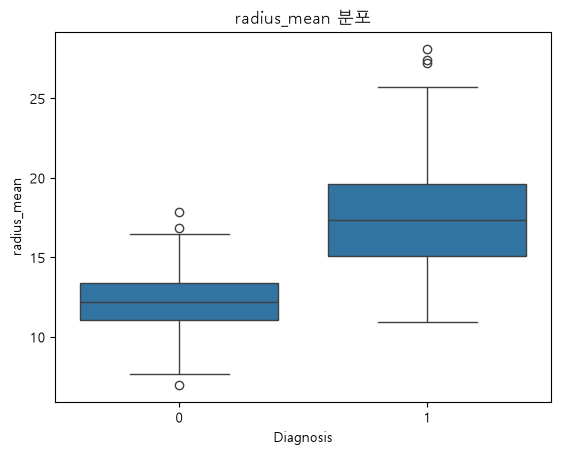

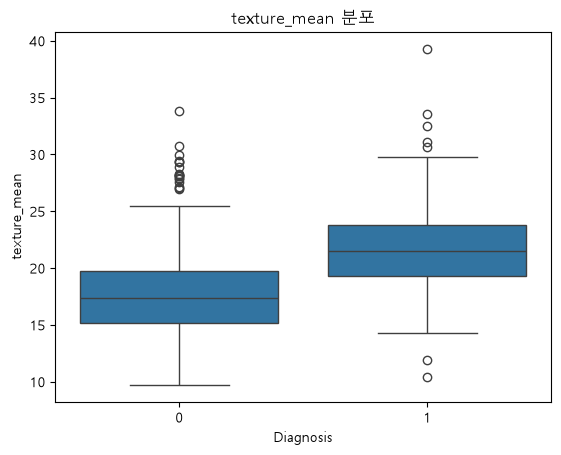

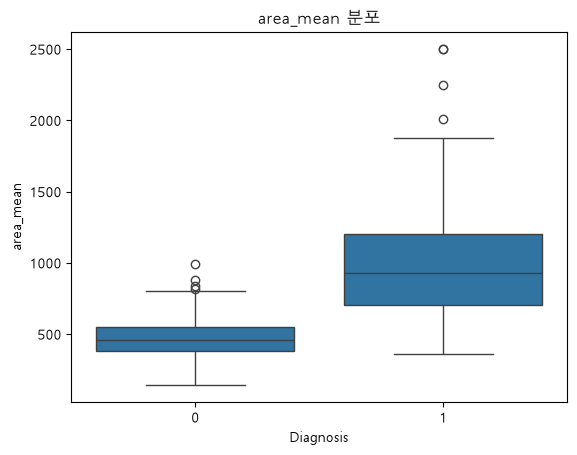

In [297]:
# 주요 특성의 분포 시각화

features = ['radius_mean', 'texture_mean', 'area_mean']  # 반지름, 질감, 면적
for feature in features:
    sns.boxplot(x='Diagnosis', y=feature, data=data)
    plt.title(f'{feature} 분포')
    plt.show()

**박스플롯 해석 — 양성(0) vs 악성(1)**

박스플롯(boxplot, 상자 수염 그림)은 데이터의 분포를 다섯 개의 숫자로 요약한 그래프입니다. 읽는 방법부터 정리하면 다음과 같습니다.

- **상자의 아래쪽 선** = 1사분위수(Q1, 하위 25%), **위쪽 선** = 3사분위수(Q3, 하위 75%)
- **상자 안의 가로선** = 중앙값(median)
- **상자의 높이** = IQR(Interquartile Range, 사분위 범위 = Q3 − Q1). 가운데 50%의 데이터가 이 안에 들어 있음
- **수염(whisker)** = 상자에서 위아래로 IQR의 1.5배 범위까지 뻗은 선. 그 범위 안에서 가장 끝에 있는 값까지 그려짐
- **동그라미(○)** = 수염 바깥에 있는 값 = **이상값(outlier) 후보**

가로축의 `0`은 양성, `1`은 악성입니다.

**① radius_mean (평균 반지름)**

| 구분 | Q1 | 중앙값 | Q3 | 범위 |
|---|---|---|---|---|
| 양성(0) | 11.1 | 12.2 | 13.4 | 약 7.0 ~ 17.9 |
| 악성(1) | 15.1 | 17.3 | 19.6 | 약 11.0 ~ 28.1 |

- 악성의 중앙값(17.3)이 양성(12.2)보다 약 5만큼 큽니다. **악성 종양 세포가 더 크다**는 뜻입니다.
- 두 상자가 세로로 전혀 겹치지 않습니다(양성 Q3 13.4 < 악성 Q1 15.1). 가운데 50%끼리는 완전히 구분되므로, **radius_mean 하나만으로도 양성·악성을 상당히 잘 나눌 수 있습니다.**
- 다만 수염끼리는 약 11~17 구간에서 겹칩니다. 이 구간의 환자는 반지름만으로는 판단하기 어렵고, 다른 특성의 도움이 필요합니다.
- 양성 쪽에 큰 값 이상값 2개(약 16.8, 17.8)와 작은 값 1개(약 7.0), 악성 쪽에 큰 값 3개(약 27~28)가 보입니다.

**② texture_mean (평균 질감)**

| 구분 | Q1 | 중앙값 | Q3 |
|---|---|---|---|
| 양성(0) | 15.2 | 17.4 | 19.8 |
| 악성(1) | 19.3 | 21.5 | 23.8 |

- 악성의 중앙값이 약 4 높아, 악성 세포의 질감(세포 이미지 회색조 값의 표준편차, 즉 얼마나 얼룩덜룩한지)이 더 거칩니다.
- 하지만 **두 상자가 약간 겹칩니다**(양성 Q3 19.8 > 악성 Q1 19.3). radius_mean보다 구분력이 약한 특성입니다.
- 양성 쪽 위로 이상값이 많이(18개) 몰려 있습니다. 질감이 거친 양성 종양도 꽤 있다는 뜻이라, 질감만 보고 악성이라 판단하면 오진이 생길 수 있습니다.

**③ area_mean (평균 면적)**

| 구분 | Q1 | 중앙값 | Q3 | 최댓값 |
|---|---|---|---|---|
| 양성(0) | 378 | 458 | 551 | 992 |
| 악성(1) | 705 | 932 | 1204 | 2501 |

- 악성의 중앙값(932)이 양성(458)의 약 2배입니다. 면적은 반지름의 제곱에 비례하므로(원의 넓이 = π × 반지름²), 반지름 차이보다 훨씬 크게 벌어집니다.
- **악성 상자가 훨씬 깁니다.** 양성의 IQR은 약 173인데 악성은 약 498로, 악성 종양은 크기가 제각각이라는 것을 보여줍니다.
- radius_mean처럼 두 상자가 겹치지 않아 구분력이 좋습니다.

**종합**

- 세 특성 모두 **악성이 양성보다 값이 큽니다.** 즉 "크고, 거칠수록 악성일 가능성이 높다"는 경향이 있습니다.
- 구분력은 **크기 계열(radius, area) > 질감(texture)** 순입니다. 각 특성과 진단(Diagnosis)의 상관계수를 계산해 보면 radius_mean 0.73, area_mean 0.71, texture_mean 0.42로 같은 순서가 나옵니다.
- 이 결과는 3번(데이터 전처리)에서 `SelectKBest`가 고르는 상위 9개 특성 대부분이 반지름·둘레·면적·오목도 계열인 이유와도 연결됩니다.

(3) 특성 간 상관관계 분석 

특성 간의 상관관계를 분석하여 서로 높은 상관성을 가진 특성을 식별합니다. 상관관계는 모델  
학습 시 불필요한 중복 특성을 제거하거나, 중요한 특성을 선택하는 데 유용합니다.


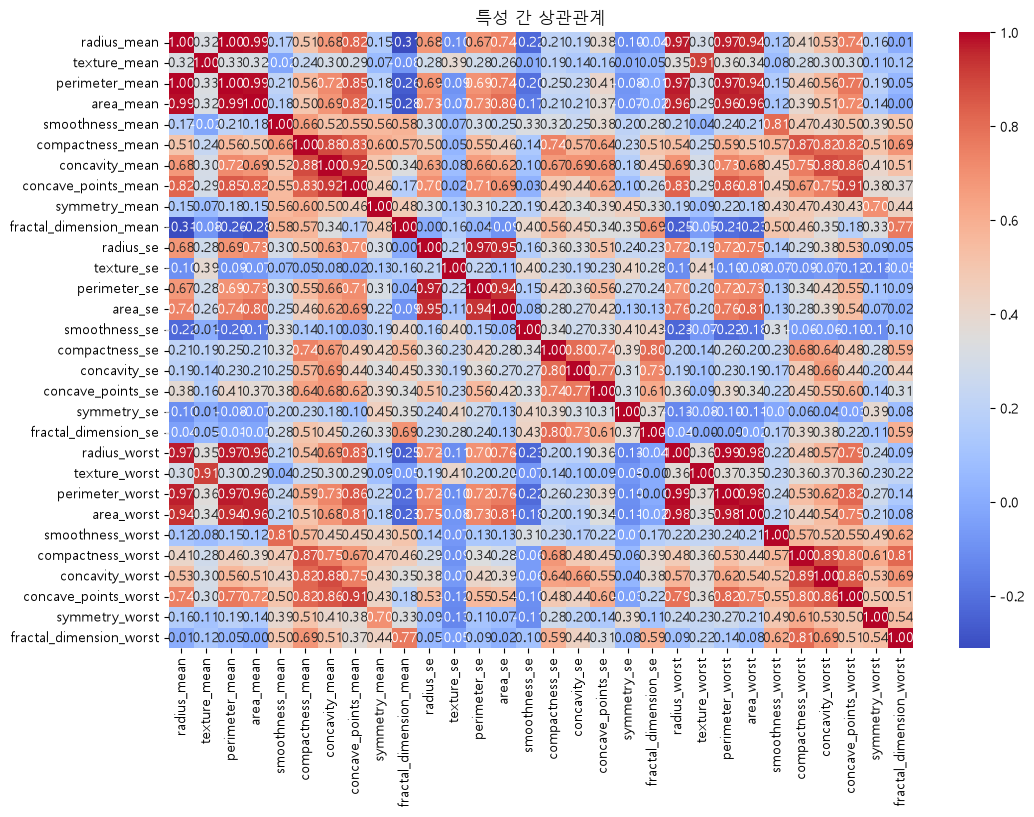

In [298]:
# 상관행렬 생성 및 시각화

corr_matrix = data.iloc[:, 2:].corr()  # 첫 두 열 (ID, Diagnosis 제외)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('특성 간 상관관계')
plt.show()

**상관관계 히트맵 해석**

**상관계수란?** 두 변수가 함께 움직이는 정도를 −1 ~ +1 사이 숫자로 나타낸 것입니다(여기서는 피어슨 상관계수, Pearson correlation).

| 값 | 의미 | 히트맵 색 |
|---|---|---|
| +1에 가까움 | 한쪽이 커지면 다른 쪽도 거의 똑같이 커짐 (강한 양의 상관) | 진한 빨강 |
| 0 근처 | 둘 사이에 직선적인 관계가 거의 없음 | 흰색·회색 |
| −1에 가까움 | 한쪽이 커지면 다른 쪽은 작아짐 (강한 음의 상관) | 진한 파랑 |

**① 대각선 줄(왼쪽 위 → 오른쪽 아래)이 모두 1.00인 이유**

대각선 칸은 `radius_mean`과 `radius_mean`, `texture_mean`과 `texture_mean`처럼 **자기 자신과의 상관관계**입니다. 어떤 값이든 자기 자신과는 완벽하게 똑같이 움직이므로 항상 1.00이 나옵니다. 그래서 대각선은 정보가 없는 기준선일 뿐, 해석할 때는 무시하면 됩니다.

또한 히트맵은 **대각선을 기준으로 위아래가 대칭(거울상)**입니다. A와 B의 상관계수는 B와 A의 상관계수와 같기 때문입니다. 따라서 대각선 한쪽(위 삼각형 또는 아래 삼각형)만 읽어도 충분합니다.

**② 변수들 사이의 주요 상관관계**

| 묶음 | 대표 쌍 | 상관계수 | 해석 |
|---|---|---|---|
| 크기 3형제 | radius_mean – perimeter_mean | 1.00 (0.998) | 반지름·둘레·면적은 수학적으로 연결된 값 (둘레 = 2πr, 면적 = πr²) |
| | radius_mean – area_mean | 0.99 | 같은 정보를 거의 중복으로 담고 있음 |
| mean ↔ worst | radius_mean – radius_worst | 0.97 | 평균이 큰 종양은 최악값도 큼 |
| | perimeter_worst – area_worst | 0.98 | |
| 모양(오목함) 계열 | concavity_mean – concave_points_mean | 0.92 | 윤곽이 많이 오목할수록 오목한 지점 수도 많음 |
| | compactness_mean – concavity_mean | 0.88 | |
| 크기 ↔ 모양 | area_mean – concave_points_mean | 0.82 | 큰 세포일수록 윤곽이 울퉁불퉁한 경향 |
| se(표준오차) 크기 계열 | radius_se – perimeter_se | 0.97 | se끼리도 크기 계열은 강하게 묶임 |
| 약한 음의 상관 | radius_mean – fractal_dimension_mean | −0.31 | 큰 세포일수록 프랙탈 차원(윤곽 복잡도 지표)이 약간 낮음 |
| 거의 무관 | texture_se, smoothness_se ↔ 대부분 | 0 근처 | 다른 특성과 독립적인 정보 |

**③ 이 결과가 의미하는 것**

- 30개 특성 중 상당수가 **사실상 같은 정보를 반복**하고 있습니다. 이렇게 입력 변수끼리 강하게 상관된 상태를 **다중공선성(multicollinearity)**이라고 합니다.
- 다중공선성은 Ridge Classifier, LDA 같은 **선형 모델**의 계수를 불안정하게 만들 수 있습니다. 반면 Extra Trees, LightGBM 같은 **트리 모델**은 비교적 영향을 덜 받습니다. 이것이 뒤에서 두 계열의 모델을 섞어 앙상블하는 이유 중 하나입니다.
- 대처 방법으로는 중복 특성 제거, 특성 선택, 주성분 분석(PCA, 상관된 변수들을 서로 독립적인 새 축으로 압축하는 방법) 등이 있습니다.
- 참고로 3번 전처리에서 쓰는 `SelectKBest`(F-검정)는 **각 특성을 하나씩 따로** 평가해 진단과 관련이 큰 순서로 고릅니다. 그래서 반지름·둘레·면적처럼 서로 중복되는 특성들이 함께 뽑히는데, F-검정이 특성끼리의 중복까지는 따지지 않기 때문입니다.

(4) 이상값 식별 

박스플롯을 활용해 이상값을 식별하고 , 필요에 따라 이를 제거하거나 적절히 처리합니다.  
이상값은 학습 데이터의 왜곡을 초래할 수 있으므로 신중히 다룹니다.

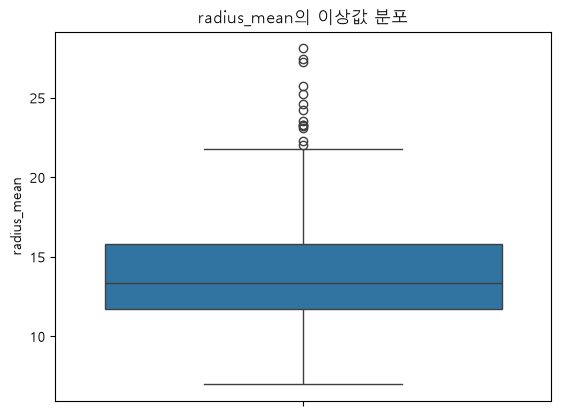

In [299]:
# 특정 특성의 이상값 확인

sns.boxplot(data['radius_mean'])
plt.title('radius_mean의 이상값 분포')
plt.show()

**이상값 박스플롯 해석 — radius_mean 전체(양성 + 악성)**

이번 그래프는 진단을 나누지 않고 569명 전체의 radius_mean을 하나의 상자로 그린 것입니다.

| 항목 | 값 | 의미 |
|---|---|---|
| Q1 (상자 아래) | 11.70 | 하위 25% 환자의 반지름이 11.7 이하 |
| 중앙값 (상자 안 선) | 13.37 | 전체 환자의 가운데 값 |
| Q3 (상자 위) | 15.78 | 상위 25% 환자의 반지름이 15.78 이상 |
| IQR (= Q3 − Q1) | 4.08 | 가운데 50% 환자가 모인 폭 |
| 위쪽 경계 (Q3 + 1.5 × IQR) | 약 21.9 | 이보다 크면 이상값으로 표시 |
| 아래쪽 경계 (Q1 − 1.5 × IQR) | 약 5.6 | 최솟값(6.98)이 이보다 커서 아래쪽 이상값은 없음 |

- 위쪽 수염 끝(약 21.9) 위로 **동그라미 14개**가 찍혀 있습니다. 최댓값은 28.11입니다.
- 이상값이 위쪽에만 있다는 것은 분포가 **오른쪽(큰 값 쪽)으로 꼬리가 긴 형태**라는 뜻이며, 앞의 `describe()`에서 평균(14.13)이 중앙값(13.37)보다 컸던 것과 일치합니다.

**이상값의 정체 — 지우면 안 되는 값**

이 14개 이상값을 진단별로 확인해 보면 **14개 모두 악성(1)**입니다. 즉 이 점들은 측정 오류가 아니라 **실제로 크기가 매우 큰 악성 종양**입니다.

- 이상값을 "튀는 값이니 지운다"는 식으로 기계적으로 제거하면, 가장 뚜렷한 악성 사례들을 학습 데이터에서 없애는 셈이 되어 오히려 모델이 악성을 덜 배우게 됩니다.
- 그래서 의료 데이터에서는 이상값을 발견하면 먼저 **"오류인가, 실제 극단 사례인가"**를 확인해야 합니다. 이 데이터에서는 지우지 않고 그대로 두는 것이 맞습니다.

**앞의 진단별 박스플롯과 비교**

앞의 진단별 그래프에서 악성 그룹의 이상값은 3개뿐이었습니다. 같은 값이라도 **어느 집단을 기준으로 보느냐에 따라 이상값 여부가 달라집니다.** 전체 기준으로는 "튀는 값"이던 반지름 22~26의 종양도, 악성 집단 안에서는 평범한 범위(악성 그룹의 위쪽 경계 약 26.4)에 속하기 때문입니다.

탐색적 데이터 분석(EDA)은 WBCD 데이터셋을 이해하고 , 데이터의 품질을 확인하며 , 모델  
학습에 적합한 데이터를 준비하는 과정입니다. 데이터 구조를 확인하면서 샘플과 특성을  
분석하고 , 양성과 악성 분포를 비교하며 , 특성간 상관관계를 파악합니다. 또한, 박스플롯과  
히스토그램을 활용해 주요 특성의 분포를 시각화하고 , 이상값을 식별합니다. EDA는 데이터의  
특성을 명확히 이해하고 모델 학습 과정에서 발생할 수 있는 문제를 사전에 해결할 수 있도록  
도와줍니다.

다음은 유방암 진단에 사용되는 9개의 핵심 특성들의 분포를 히스토그램으로 나타낸 것입니다.  
각 특성의 분포 패턴을 통해 데이터의 특성과 경향을 파악할 수 있습니다.


In [300]:
# 현재 data의 열 이름 확인


# columns: 표의 열 이름들 / tolist(): 보기 쉽게 리스트로 변환
print(data.columns.tolist())


# → data 안에 어떤 열 이름이 들어 있는지 확인하겠다


['ID', 'Diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


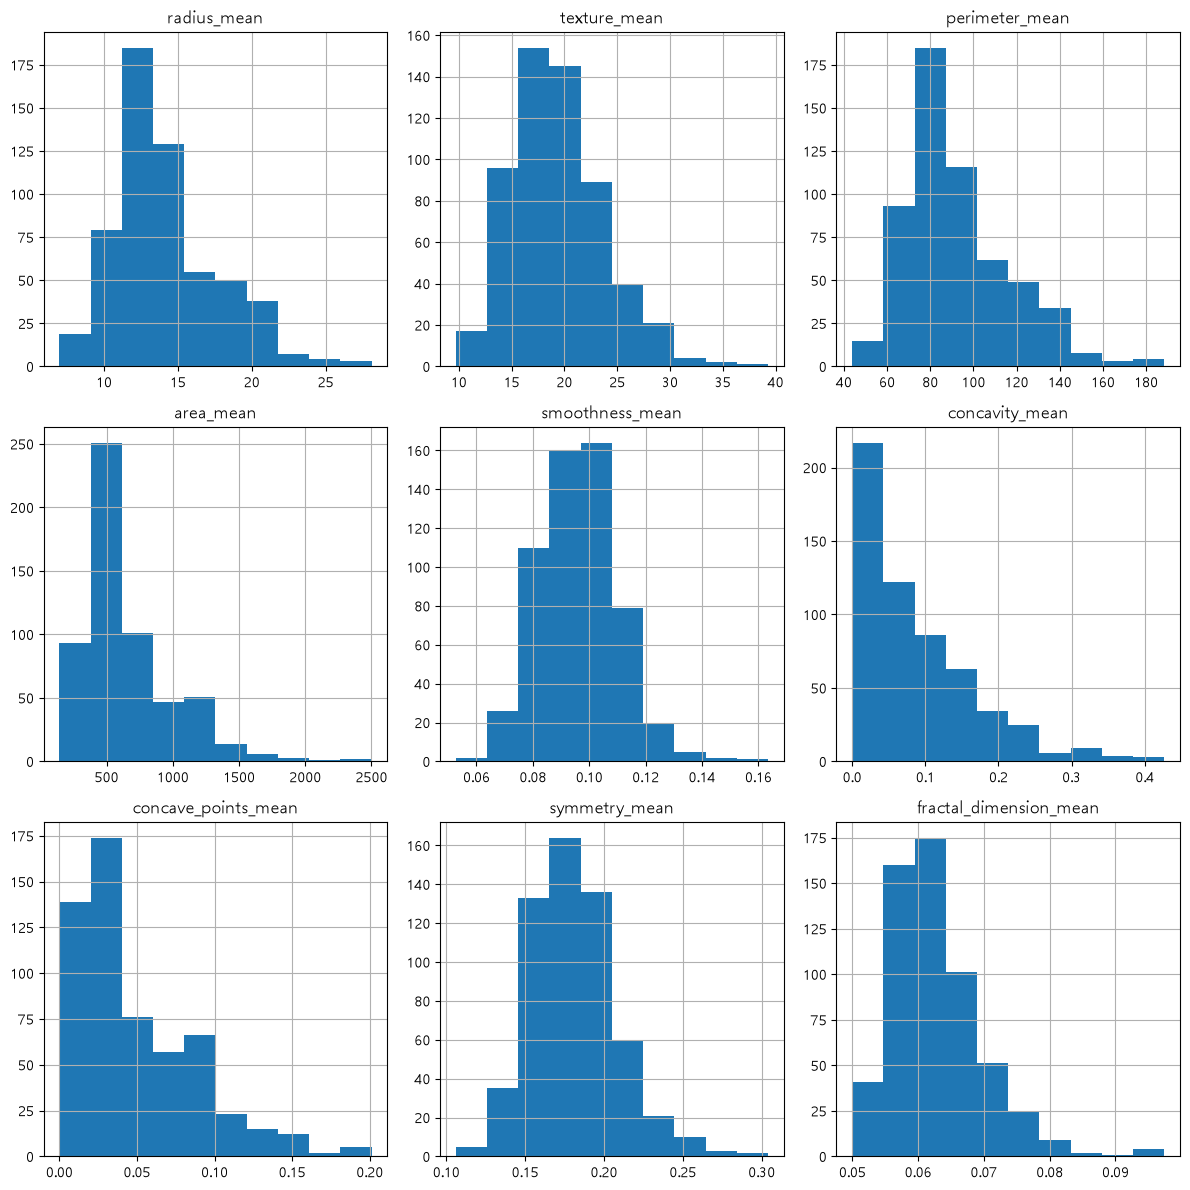

In [301]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean',
            'area_mean', 'smoothness_mean', 'concavity_mean',
            'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']

data[features].hist(figsize=(12, 12), layout=(3, 3))

plt.tight_layout()
plt.show()

**히스토그램 해석 (실제 WBCD 데이터 기준)**

첫째로, radius_mean(평균 반경) 분포를 보면 약 7에서 28 사이에 값이 분포하며, 다수의  
데이터가 10~15 구간에 집중되어 있고, 값이 커질수록 빈도가 감소하는 오른쪽 꼬리 분포를  
보입니다. 20을 넘는 값은 상대적으로 적지만 25 이상까지 이어지고 있어, 일부 크기가 매우 큰  
종양 세포가 존재함을 알 수 있습니다. texture_mean(평균 텍스처)은 약 10에서 39 사이의  
비교적 넓은 범위에 걸쳐 분포하며, 15~20 구간에서 가장 높은 빈도를 보이고 양쪽으로 점차  
줄어드는 종 모양에 가까운 패턴을 보입니다. 다만 30 이상의 값도 소수 존재하여 오른쪽으로  
완만한 꼬리가 나타납니다.

perimeter_mean(평균 둘레)과 area_mean(평균 면적)은 radius_mean과 함께 매우 유사한 분포  
패턴을 보이는데, 이는 둘레와 면적이 모두 반경으로부터 계산되는 값이기 때문에 세 특성이  
서로 밀접한 관계에 있음을 시사합니다. perimeter_mean은 약 43에서 188 사이에 분포하며 80  
부근에 데이터가 가장 많이 몰려 있고, area_mean은 약 140에서 2500 사이에 분포하며 500  
부근에서 가장 높은 빈도를 보입니다. 두 특성 모두 낮은 값에서 높은 빈도를 보이고 값이  
증가할수록 빈도가 감소하는 경향을 보이며, 특히 area_mean은 면적이 반경의 제곱에 비례하기  
때문에 오른쪽 꼬리가 다른 특성보다 훨씬 길게 늘어져 있습니다.

smoothness_mean(평균 평활도)은 약 0.05에서 0.16 사이의 좁은 범위에 집중된 분포를 보이며,  
0.09~0.10 부근을 중심으로 좌우가 거의 대칭인 종 모양을 이루고 있어 정규 분포에 가장 가까운  
특성 중 하나입니다. 반면 concavity_mean(평균 오목도)은 약 0에서 0.43 사이에 분포하며, 0에  
가까운 구간에서 빈도가 가장 높고 값이 커질수록 빈도가 꾸준히 감소하는 뚜렷한 오른쪽 꼬리  
분포를 보입니다. 이는 대부분의 세포핵 윤곽이 거의 오목하지 않지만, 일부 세포는 윤곽이 크게  
움푹 들어가 있음을 의미합니다. concave_points_mean(평균 오목점) 역시 약 0에서 0.20 사이에  
분포하며, 대부분의 값이 0.05 이하의 낮은 구간에 집중되어 있고 오른쪽으로 길게 꼬리가  
이어지는 분포를 보입니다.

symmetry_mean(평균 대칭성)은 약 0.11에서 0.30 사이에 분포하며, 0.17~0.18 부근을 중심으로  
비교적 고른 종 모양을 보여 다른 특성들에 비해 극단적인 치우침이 적습니다. 마지막으로  
fractal_dimension_mean(평균 프랙탈 차원)은 약 0.05에서 0.10 사이의 매우 좁은 범위에  
분포하며, 0.06 부근에 대부분의 값이 집중되어 있고 오른쪽으로 약간의 꼬리가 나타나는 것이  
특징입니다. 참고로 기존 설명에서는 이 특성이 2.0에서 4.0 사이에 분포한다고 되어 있었는데,  
이는 열 이름이 어긋나 WBC Original 데이터의 진단 열(2=양성, 4=악성)이 fractal_dimension_mean이라는  
이름으로 그려졌기 때문입니다(Step 5 2번의 개선 사항 참고). 실제 WBCD 데이터에서는 위와 같이 0.05~0.10 범위에 분포합니다.

전반적으로 이러한 분포 분석을 통해 각 특성의 값 범위와 분포 패턴을 파악할 수 있으며, 이는  
후속 데이터 처리와 모델링 단계에서 중요한 기초 정보로 활용됩니다. 특히 radius_mean,  
perimeter_mean, area_mean, concavity_mean, concave_points_mean 등 다수의 특성이 정규  
분포와는 다른 오른쪽으로 치우친 비대칭 분포를 보인다는 점은, 이상값을 점검하고 필요에 따라  
로그 변환 등을 고려해야 하는 근거가 됩니다. 또한 area_mean은 수백에서 2500까지,  
smoothness_mean은 0.05에서 0.16까지 분포하는 것처럼 특성마다 값의 크기 단위가 크게 다르기  
때문에, 모델 학습 전에 모든 특성의 범위를 비슷하게 맞춰 주는 스케일링(표준화) 과정이  
반드시 필요합니다.

### 3. 데이터 전처리 

WBCD 데이터셋을 머신러닝 모델에 적합하게 만들기 위해 데이터 전처리를 수행합니다. 전처리는  
데이터를 더 깨끗하고 일관성 있게 정리하며, 모델 성능을 최적화하는 데 중요한 과정입니다. 이  
전처리 과정은 결측값 처리, 레이블 변환, 특성 선택, 데이터 스케일링의 네  
단계로 구성됩니다.

먼저, 데이터셋에 누락된 값(NaN)이 있는 경우 이를 적절히 처리합니다. 누락된 데이터를  
제거하면 데이터의 크기가 줄어들기 때문에 대체로 평균값이나 중앙값으로 채우는 방법을  
사용합니다. 이는 데이터의 구조를 유지하면서 학습 가능한 형태로 만들기 위한 작업입니다.

다음으로, WBCD 데이터셋의 진단 결과는 문자열로 표현되어 있어 모델 학습에 바로 사용할 수  
없습니다. 이를 숫자로 변환하는 레이블 변환 작업을 수행합니다. LabelEncoder는 알파벳 순서대로 번호를 붙이므로 양성(B)은 0, 악성(M)은  
1로 변환하여 범주형 데이터를 수치형 데이터로 변경합니다.

특성 선택 단계에서는 전체 30개의 특성 중 가장 유의미한 9개의 특성을 선택합니다. 상관  
분석이나 SelectKBest와 같은 기법을 사용하여 목표 변수(양성 또는 악성)와 가장 관련이 높은  
특성을 선택합니다. 이렇게 하면 모델 학습에 불필요한 특성이 제외되어 학습 효율성이  
높아집니다.

마지막으로, 데이터 스케일링을 통해 모든 특성 값의 범위를 조정합니다. 특성 값의 크기가  
다르면 학습에 영향을 줄 수 있기 때문에, 정규화나 표준화를 사용하여 데이터 값을 동일한  
범위로 맞춥니다. 이렇게 하면 모델이 각 특성을 동일한 중요도로 반영하게 됩니다.

아래는 이러한 전처리를 Python으로 구현한 코드입니다.

데이터셋을 정리하고, 학습 및 테스트 데이터로 분리하며, 특성과 스케일을 조정하는 과정을  
보여줍니다. 이를 통해 모델이 데이터를 효율적으로 학습할 수 있도록 준비할 수 있습니다.

In [302]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# scikit-learn 모델 표시 방식 설정
# set_config: scikit-learn 전체 설정을 바꾸는 함수
from sklearn import set_config

# display='text': 모델을 HTML 상자 대신 일반 글자로 표시 → 한국어 윈도우 인코딩 에러 방지
set_config(display='text')


# → 전처리에 필요한 도구들을 불러오겠다
# → 모델 출력 시 HTML 대신 글자로 보여줘서 인코딩 에러를 피하겠다

In [303]:
# 데이터 불러오기
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
columns = ["ID", "Diagnosis"] + [f"Feature_{i}" for i in range(1, 31)]
data = pd.read_csv(url, header=None, names=columns)

In [304]:
# 결측값 처리 (숫자 열만 평균으로 채움)
data = data.fillna(data.mean(numeric_only=True))

In [305]:
# 레이블 변환 (B -> 0, M -> 1 : LabelEncoder는 알파벳 순서로 번호를 붙임)
label_encoder = LabelEncoder()
data["Diagnosis"] = label_encoder.fit_transform(data["Diagnosis"])

In [306]:
# 특성과 레이블 분리
X = data.iloc[:, 2:]
y = data["Diagnosis"]

In [307]:
# 특성 선택 (F-검정 점수 기반 상위 9개 특성 선택)
selector = SelectKBest(score_func=f_classif, k=9)
X_selected = selector.fit_transform(X, y)

In [308]:
# 데이터 스케일링 (표준화: 평균 0, 표준편차 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [309]:
# 데이터 분할 (70% 훈련 데이터, 30% 테스트 데이터)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("훈련 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

훈련 데이터 크기: (398, 9)
테스트 데이터 크기: (171, 9)


### 4. 모델링 기법


WBCD 데이터셋의 분류 문제를 해결하기 위해 앙상블 학습 기반의 투표 모델을 사용합니다.  
앙상블 학습은 여러 개의 기초 모델을 결합하여 단일 모델보다 더 높은 성능과 안정성을  
달성하는 기법입니다. 이 연구에서는 Extra Trees Classifier(ETC), Light Gradient Boosting  
Machine(LightGBM), Ridge Classifier(RC), Linear Discriminant Analysis(LDA)와 같은 다양한  
알고리즘을 결합하여 최적의 결과를 도출합니다.

이 방법에서는 하드 보팅 방식을 사용합니다. 하드 보팅은 개별 모델의 예측 결과를 결합하여  
다수결 방식으로 최종 결과를 결정합니다. 예를 들어, 네 개의 모델 중 세 개가 양성을 예측하면  
최종 예측도 양성으로 분류합니다. 이렇게 하면 각 모델의 강점을 반영하여 예측의 신뢰도를  
높일 수 있습니다.

앙상블 학습의 구현은 Python의 VotingClassifier를 사용하여 이루어집니다. 아래는 구현 과정을  
설명하는 코드와 함께 상세한 설명입니다.

In [310]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

위 코드는 다양한 분류 알고리즘을 결합한 앙상블 모델을 구축하기 위해 필요한 분류기들을  
임포트하는 과정을 보여줍니다. 여기서는 투표 도구 1개와 서로 다른 분류기 4개, 총 다섯 가지 도구를 불러오는데, 먼저  
여러 분류기의 예측 결과를 투표 방식으로 결합하는 VotingClassifier를 가져옵니다. 다음으로  
랜덤 포레스트의 변형 버전으로 더 많은 무작위성을 도입한 ExtraTreesClassifier와 그래디언트  
부스팅 계열의 LGBMClassifier를 임포트합니다. 또한 L2 정규화를 활용하는 선형 분류기인  
RidgeClassifier와 클래스 간 분산은 최대화하고 클래스 내 분산은 최소화하는 방식으로  
작동하는 LinearDiscriminantAnalysis도 함께 가져옵니다. 마지막으로 이러한 분류기들의 성능을  
평가하기 위해 정확도를 계산하는 accuracy_score 함수도 임포트합니다.

Extra Trees Classifier, LightGBM, Ridge Classifier, Linear Discriminant Analysis와 같은 네  
가지 개별 모델을 정의합니다. 이 모델들은 각각의 알고리즘적 특성과 강점을 가지고 있습니다.  
예를 들어, Extra Trees Classifier는 다수의 결정 트리를 결합하여 다양성을 높이고,  
LightGBM은 부스팅 기법을 사용하여 높은 성능을 제공합니다. Ridge Classifier는 선형 회귀를  
기반으로 간단하고 빠르게 동작하며, LDA는 데이터 분포를 활용하여 분류 경계를 설정합니다.

이러한 개별 모델들은 VotingClassifier를 통해 앙상블로 결합됩니다. 하드 보팅을 사용하여 각  
모델의 예측 결과를 기반으로 다수결로 최종 예측을 결정합니다. 2 : 2처럼 표가 같게  
나올 경우, scikit-learn은 번호가 더 작은 클래스(여기서는 0 = 양성)를 고릅니다(5번 결과 해석 참고).

결합된 앙상블 모델은 훈련 데이터를 사용해 학습을 진행합니다. 학습이 완료된 모델은 테스트  
데이터를 통해 성능을 평가하며, accuracy_score를 통해 예측 결과의 정확도를 계산합니다. 이  
방법은 개별 모델의 강점을 조합하여 WBCD 데이터셋과 같은 의료 진단 문제에서 높은 예측  
성능과 안정성을 제공합니다. 위 코드는 WBCD 데이터셋과 함께 사용 가능하며, 추가적인  
조정이나 모델 변경을 통해 다양한 문제에 적용할 수 있습니다.

In [311]:
# 개별 모델 정의
etc = ExtraTreesClassifier(random_state=42)  # Extra Trees Classifier
lgbm = LGBMClassifier(random_state=42)  # Light Gradient Boosting Machine
ridge = RidgeClassifier()  # Ridge Classifier
lda = LinearDiscriminantAnalysis()  # Linear Discriminant Analysis

이 코드는 앙상블 모델에서 사용될 개별 분류기들을 초기화하는 과정을 보여줍니다. 총 네  
가지의 서로 다른 분류기가 정의되었는데, 먼저 ExtraTreesClassifier를 'etc'라는 이름으로  
초기화하며 재현성을 위해 random_state를 42로 설정합니다. 두 번째로 LightGBM의 분류기인  
LGBMClassifier를 'lgbm'이라는 이름으로 정의하고 마찬가지로 random_state를 42로 설정합니다.  
세 번째로 선형 분류기인 RidgeClassifier를 'ridge'라는 이름으로 정의하며, 마지막으로  
LinearDiscriminantAnalysis를 'lda'라는 이름으로 초기화합니다. 이렇게 정의된 네 개의  
분류기는 이후 앙상블 모델을 구성하는 기본 요소로 사용될 것입니다.

In [312]:
# 앙상블 모델 정의 (하드 보팅 사용)
voting_clf = VotingClassifier(
    estimators=[
        ('ExtraTrees', etc),
        ('LightGBM', lgbm),
        ('Ridge', ridge),
        ('LDA', lda)
    ],
    voting='hard'  # 하드 보팅
)

이 코드는 앙상블 모델을 구성하기 위해 VotingClassifier를 설정하는 과정을 보여줍니다.  
VotingClassifier는 여러 분류기의 예측 결과를 투표 방식으로 결합하는데, 여기서는 앞서  
정의한 네 개의 분류기(ExtraTreesClassifier, LGBMClassifier, RidgeClassifier,  
LinearDiscriminantAnalysis)를 모두 포함시킵니다. 각 분류기는 ('이름', 분류기객체) 형태의  
튜플로 지정되며, voting 파라미터를 'hard'로 설정하여 하드 보팅 방식을 사용합니다. 하드  
보팅은 각 분류기가 예측한 클래스 중에서 가장 많이 예측된 클래스를 최종 예측값으로 선택하는  
방식입니다.

In [313]:
# 모델 학습
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('ExtraTrees',
                              ExtraTreesClassifier(random_state=42)),
                             ('LightGBM', LGBMClassifier(random_state=42)),
                             ('Ridge', RidgeClassifier()),
                             ('LDA', LinearDiscriminantAnalysis())])

In [314]:
# 테스트 데이터 예측
y_pred = voting_clf.predict(X_test)

이 코드는 앞서 정의한 투표 기반 앙상블 모델의 학습과 예측을 수행하는 과정을 보여줍니다.  
먼저 voting_clf.fit(X_train, y_train) 명령을 통해 학습 데이터로 앙상블 모델을  
학습시킵니다. 이 과정에서 앙상블을 구성하는 네 개의 개별 분류기들이 같은 데이터로  
차례로 학습됩니다(`n_jobs=-1`을 지정하면 동시에 병렬로 학습). 학습이 완료된 후에는 voting_clf.predict(X_test) 명령을 사용하여 테스트  
데이터에 대한 예측을 수행합니다. 이때 각 분류기의 예측 결과가 하드 보팅 방식으로 결합되어  
최종 예측값이 y_pred에 저장됩니다.

In [315]:
# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("앙상블 모델의 정확도:", accuracy)

앙상블 모델의 정확도: 0.9649122807017544


이 코드는 앙상블 모델의 성능을 정확도 지표로 평가하는 과정을 보여줍니다. accuracy_score  
함수를 사용하여 테스트 데이터의 실제 값(y_test)과 모델이 예측한 값(y_pred)을 비교합니다.  
이를 통해 계산된 정확도는 전체 테스트 데이터 중에서 모델이 올바르게 예측한 비율을  
의미하며, print 문을 통해 이 정확도 값을 출력합니다.

### 5. 성능 평가 방법 

> 이 절에서 정리하는 평가지표(혼동행렬, 정확도, 정밀도, 재현율, F1 점수, ROC·AUC)는 노트북 뒤쪽(6번 제안된 방법론, Step 4·5의 모델 평가, AutoML)에서도 계속 쓰입니다. **각 지표의 자세한 뜻과 공식은 여기서 한 번에 정리**하고, 뒤에서는 이 절을 참고하도록 했습니다.

모델의 성능을 정확히 평가하기 위해 다양한 평가지표와 분석 방법을 사용합니다. 이러한 지표들은 모델이 예측한 결과의 정확도뿐만 아니라, 특정 클래스(예: 양성 또는 악성)를 얼마나 잘 식별하는지를 측정합니다. WBCD 데이터셋과 같은 의료 진단 문제에서는 모델의 정확도뿐만 아니라 정밀도, 재현율, F1 점수와 같은 세부 지표가 매우 중요합니다.

#### (0) 먼저 알아야 할 것: 혼동행렬과 TP·TN·FP·FN

모든 평가지표는 **혼동행렬(Confusion Matrix)**의 네 칸에서 출발합니다. 혼동행렬은 "실제 정답"과 "모델의 예측"을 짝지어 네 가지 경우로 세어 놓은 표입니다.

**⚠️ 용어 주의 — '양성'이라는 단어가 두 가지 뜻으로 쓰입니다**

| 쓰이는 곳 | '양성'의 뜻 |
|---|---|
| 의학 | 양성 종양(Benign) = 암이 아닌 순한 종양 |
| 머신러닝 평가지표 | Positive(양성 클래스) = **우리가 찾아내려는 대상**, 보통 레이블 1 |

이 노트북의 Step 3 데이터는 `LabelEncoder`로 **B(양성 종양) = 0, M(악성 종양) = 1**이므로, 평가지표에서 말하는 **Positive(1) = 악성 종양(암)**, **Negative(0) = 양성 종양**입니다. 헷갈리지 않도록 아래에서는 "Positive = 암(악성)"으로 읽으면 됩니다.

| | 모델 예측: 0 (양성 종양) | 모델 예측: 1 (악성 종양) |
|---|---|---|
| **실제: 0 (양성 종양)** | **TN** (True Negative, 참 음성) | **FP** (False Positive, 거짓 양성) |
| **실제: 1 (악성 종양)** | **FN** (False Negative, 거짓 음성) | **TP** (True Positive, 참 양성) |

이름 읽는 법: 뒤의 글자(**P/N**)는 **모델이 무엇이라고 예측했는지**, 앞의 글자(**T/F**)는 **그 예측이 맞았는지(True)·틀렸는지(False)**입니다.

| 칸 | 상황 | 의료 현장에서의 결과 |
|---|---|---|
| **TP** | 실제 암 → 모델도 암이라고 예측 | 정확히 찾아냄 → 치료로 연결 |
| **TN** | 실제 양성 종양 → 모델도 양성이라고 예측 | 불필요한 검사 없이 안심 |
| **FP** | 실제 양성 종양 → 모델은 암이라고 예측 (**오경보**) | 불필요한 조직검사·불안·비용 |
| **FN** | 실제 암 → 모델은 양성이라고 예측 (**놓침**) | 치료 시기를 놓칠 수 있음 → **가장 위험한 오류** |

혼동행렬의 **대각선(TN, TP)은 맞힌 경우**, **대각선 밖(FP, FN)은 틀린 경우**입니다. 아래 지표들은 모두 이 네 숫자를 어떻게 조합하느냐의 차이입니다.

#### (1) 정확도 (Accuracy)

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- **분자** `TP + TN`: 맞힌 개수 (혼동행렬 대각선의 합)
- **분모** `TP + TN + FP + FN`: 전체 샘플 수
- **한 줄 의미**: "전체 환자 중 몇 %를 맞혔나?"
- **예시**: 100명 중 90명을 맞히면 정확도 0.90
- **한계**: 클래스가 불균형하면 속을 수 있습니다. 이 데이터처럼 양성이 62.7%라면, 모든 환자를 "양성"이라고 찍는 모델도 정확도 0.627이 나오지만 암 환자는 단 한 명도 찾지 못합니다. 그래서 정확도는 반드시 다른 지표와 함께 봐야 합니다.

#### (2) 정밀도 (Precision)

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- **분모** `TP + FP`: 모델이 **"암이다(1)"라고 예측한 전체 횟수**
- **분자** `TP`: 그중 **실제로 암이었던 횟수**
- **한 줄 의미**: "모델이 암이라고 말했을 때, 그 말을 얼마나 믿을 수 있나?"
- **예시**: 모델이 20명을 암이라고 판정했는데 그중 18명만 진짜 암이면 정밀도 = 18/20 = 0.90
- **높으면 좋은 점**: 오경보(FP)가 적다 → 불필요한 조직검사·환자 불안이 줄어듦
- 분모에 FP가 들어 있으므로, **FP가 늘어날수록 정밀도가 떨어집니다.**

#### (3) 재현율 (Recall, 민감도 Sensitivity)

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- **분모** `TP + FN`: **실제 암 환자 전체 수** (모델이 찾았든 못 찾았든)
- **분자** `TP`: 그중 **모델이 찾아낸 수**
- **한 줄 의미**: "실제 암 환자 중 몇 %를 놓치지 않고 찾아냈나?"
- **예시**: 실제 암 환자 20명 중 모델이 16명을 찾고 4명을 놓치면 재현율 = 16/20 = 0.80
- 의료 분야에서는 **민감도(sensitivity)**라고도 부르며, 암 진단처럼 **놓치면(FN) 치명적인 문제에서 가장 중요한 지표**입니다.

**정밀도 vs 재현율 — 서로 줄다리기 관계**

| 모델 성향 | 정밀도 | 재현율 | 예 |
|---|---|---|---|
| 조금만 의심돼도 "암"이라고 판정 (공격적) | ↓ (오경보 증가) | ↑ (놓치는 환자 감소) | 1차 선별 검사 |
| 아주 확실할 때만 "암"이라고 판정 (보수적) | ↑ | ↓ (놓치는 환자 증가) | 확진 검사 |

모델이 "몇 % 이상 확실하면 1로 판정할지" 정하는 기준값을 **임계값(threshold)**이라고 합니다. 임계값을 낮추면 재현율이 오르고 정밀도가 내려가며, 높이면 그 반대가 됩니다. 두 지표를 동시에 1로 만들기는 어렵기 때문에 균형을 보는 지표가 필요합니다.

#### (4) F1 점수 (F1-Score)

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

- **정밀도와 재현율의 조화평균(harmonic mean)**입니다. 조화평균은 두 값 중 **작은 쪽에 더 끌려가는 평균**입니다.
- **왜 그냥 평균(산술평균)이 아닌가?** 정밀도 1.0, 재현율 0.1인 모델을 생각해 보면,
  - 산술평균 = (1.0 + 0.1) ÷ 2 = **0.55** → 그럭저럭 괜찮아 보임
  - 조화평균(F1) = 2 × (1.0 × 0.1) ÷ (1.0 + 0.1) = **0.18** → 한쪽이 형편없다는 사실을 그대로 드러냄
- **한 줄 의미**: "정밀도와 재현율이 둘 다 높을 때만 높게 나오는 종합 점수"
- 클래스가 불균형한 데이터에서 정확도보다 믿을 만한 요약 지표로 자주 씁니다.

#### (5) ROC 곡선과 AUC (Area Under the Curve)

AUC를 이해하려면 먼저 "점수"와 "임계값"을 알아야 합니다.

- 많은 모델은 바로 0/1을 내놓지 않고, **"이 환자가 악성일 가능성"을 0~1 사이 점수(확률)**로 먼저 계산합니다.
- 그 점수가 **임계값(기본 0.5) 이상이면 1(악성)**, 아니면 0(양성)으로 판정합니다.
- 임계값을 바꾸면 TP·FP·FN·TN 개수가 모두 달라집니다.

ROC(Receiver Operating Characteristic) 곡선은 임계값을 1에서 0까지 바꿔 가며 아래 두 값을 점으로 찍어 이은 선입니다.

$$
\text{TPR (참 양성 비율)} = \frac{TP}{TP + FN} = \text{재현율}
\qquad
\text{FPR (거짓 양성 비율)} = \frac{FP}{FP + TN}
$$

- **세로축 TPR**: 실제 암 환자 중 찾아낸 비율 (높을수록 좋음)
- **가로축 FPR**: 실제 양성 종양 환자 중 잘못 "암"이라고 한 비율 (낮을수록 좋음)
- 좋은 모델일수록 곡선이 **왼쪽 위 모서리(FPR 0, TPR 1)** 쪽으로 붙습니다.

**AUC = ROC 곡선 아래의 넓이** (0 ~ 1)

| AUC | 의미 |
|---|---|
| 1.0 | 완벽한 구분 — 모든 악성 환자의 점수가 모든 양성 환자보다 높음 |
| 0.9 이상 | 매우 우수 |
| 0.7 ~ 0.9 | 양호 |
| 0.5 | 동전 던지기 수준 — 구분 능력 없음 |

- **직관적 해석**: 악성 환자 1명과 양성 환자 1명을 무작위로 뽑았을 때, **모델이 악성 환자에게 더 높은 점수를 줄 확률**이 AUC입니다.
- 정확도·정밀도·재현율이 **임계값 하나**에서의 성적이라면, AUC는 **모든 임계값에서의 구분 능력을 한 숫자로 요약**한 것이라 임계값 선택에 덜 흔들립니다.
- 그래서 AUC를 계산하려면 0/1 예측값이 아니라 **점수(확률)**가 필요합니다. 보통 `predict_proba()`의 악성 확률 열을 쓰고, 이 노트북의 하드 보팅 모델처럼 확률이 없는 경우에는 **"악성에 투표한 모델의 비율"**을 점수로 대신 씁니다(아래 코드 참고).

#### (6) 특이도 (Specificity) — 함께 알아두면 좋은 지표

$$
\text{Specificity} = \frac{TN}{TN + FP} = 1 - \text{FPR}
$$

- "실제 양성 종양 환자 중 몇 %를 정확히 양성이라고 했나?" 의료 논문에서는 민감도(재현율)와 특이도를 짝으로 자주 보고합니다.

#### 한눈에 정리

| 지표 | 공식 | 한 줄 의미 | 이 노트북에서 낮으면 생기는 일 |
|---|---|---|---|
| 정확도 | (TP+TN) / 전체 | 전체 중 맞힌 비율 | 전반적으로 많이 틀림 |
| 정밀도 | TP / (TP+FP) | "암"이라고 한 것 중 진짜 암 | 오경보 → 불필요한 조직검사 |
| 재현율(민감도) | TP / (TP+FN) | 실제 암 중 찾아낸 비율 | **암 환자를 놓침 (가장 위험)** |
| 특이도 | TN / (TN+FP) | 실제 양성 중 양성으로 맞힘 | 건강한 사람을 환자로 오인 |
| F1 점수 | 2PR / (P+R) | 정밀도·재현율의 균형 | 둘 중 하나가 무너짐 |
| AUC | ROC 곡선 아래 넓이 | 모든 임계값에서의 구분 능력 | 악성·양성을 점수로 구분하지 못함 |

아래 코드는 WBCD 데이터셋에서 위 지표들을 실제로 계산하고 혼동행렬을 시각화하는 예제입니다.

In [316]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

이 코드는 모델의 성능을 다양한 지표로 평가하기 위한 도구들을 임포트하는 과정을 보여줍니다.  
scikit-learn의 metrics 모듈에서 여러 평가 지표들을 가져오는데, 정확도를 평가하는  
accuracy_score, 정밀도를 측정하는 precision_score, 재현율을 계산하는 recall_score,  
정밀도와 재현율의 조화평균인 f1_score, 그리고 모델의 성능을 곡선으로 표현하는  
roc_auc_score를 임포트합니다. 또한 오분류된 케이스들을 행렬 형태로 표현하는  
confusion_matrix도 함께 가져옵니다. 시각화를 위해 seaborn과 matplotlib.pyplot도  
임포트하는데, 이는 혼동 행렬을 히트맵 형태로 표현하거나 다른 성능 지표들을 그래프로  
나타내는 데 사용됩니다.

In [317]:
# 테스트 데이터 예측
y_pred = voting_clf.predict(X_test)

이 코드는 학습된 앙상블 모델(voting_clf)을 사용하여 테스트 데이터에 대한 예측을 수행하는  
과정을 보여줍니다. voting_clf.predict(X_test) 명령을 통해 테스트 데이터에 대한 예측을  
실행하고, 그 결과를 y_pred 변수에 저장합니다. 이때 각 분류기의 예측이 하드 보팅 방식으로  
결합되어 최종 예측값이 결정됩니다.

In [318]:
# 평가지표 계산


# transform(X_test): 4개 모델 각각의 예측(0/1)을 열로 모아 반환 → (샘플 수, 4) 모양
votes = voting_clf.transform(X_test)
# mean(axis=1): 샘플마다 4개 투표의 평균 = 악성(1)에 투표한 비율 (0, 0.25, 0.5, 0.75, 1)
vote_score = votes.mean(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# predict_proba 대신 투표 비율을 점수로 사용해 AUC 계산
auc = roc_auc_score(y_test, vote_score)

print(f"정확도(Accuracy): {accuracy:.2f}")
print(f"정밀도(Precision): {precision:.2f}")
print(f"재현율(Recall): {recall:.2f}")
print(f"F1 점수(F1-Score): {f1:.2f}")
print(f"AUC(ROC): {auc:.2f}")


# → 4개 모델의 개별 투표를 꺼내 악성 투표 비율을 점수로 만들고, 다섯 가지 평가지표를 계산하겠다

정확도(Accuracy): 0.96
정밀도(Precision): 0.98
재현율(Recall): 0.92
F1 점수(F1-Score): 0.95
AUC(ROC): 0.98


**코드 설명**

위 코드는 앙상블 모델의 예측 결과(`y_pred`)를 실제 정답(`y_test`)과 비교해 다섯 가지 평가지표를 계산합니다. 각 지표의 공식과 뜻은 바로 위 (0)~(6)에 정리했습니다.

| 코드 | 하는 일 |
|---|---|
| `voting_clf.transform(X_test)` | 앙상블 안의 4개 모델(ExtraTrees, LightGBM, Ridge, LDA)이 **각자 예측한 0/1**을 열로 모아 돌려줌 → 크기 (171, 4) |
| `votes.mean(axis=1)` | 환자(행)마다 4개 투표의 평균 = **악성(1)에 투표한 모델의 비율**. 0, 0.25, 0.5, 0.75, 1 중 하나 |
| `accuracy_score(y_test, y_pred)` | 정확도 |
| `precision_score(y_test, y_pred)` | 정밀도. 기본값 `pos_label=1`이므로 **악성(1)을 기준**으로 계산 |
| `recall_score(y_test, y_pred)` | 재현율(악성 기준) |
| `f1_score(y_test, y_pred)` | F1 점수(악성 기준) |
| `roc_auc_score(y_test, vote_score)` | AUC. 0/1 예측이 아니라 **투표 비율(점수)**을 넣음 |
| `f"{accuracy:.2f}"` | 소수점 둘째 자리까지 반올림해 출력 (`.2f` = 소수점 2자리 실수) |

> **개선 사항 — AUC 계산 방식**: 기존 코드는 `voting_clf.predict_proba(X_test)[:, 1]`로 확률을 구해 AUC를 계산하도록 되어 있었습니다. 그러나 이 앙상블은 **하드 보팅**(다수결)이라 확률을 내놓지 않으며, 실행하면 `AttributeError`가 발생합니다. 구성원 중 `RidgeClassifier`가 확률을 계산하지 못하기 때문에 소프트 보팅으로 바꿀 수도 없습니다. 이 노트북에서는 대신 **"4개 모델 중 악성에 투표한 비율"**을 점수로 사용해, 하드 보팅 구조를 유지하면서도 AUC를 계산할 수 있게 했습니다.

**결과 해석 — 수치가 의미하는 것**

테스트 데이터는 171명이며, 그중 실제 양성(0) 108명, 실제 악성(1) 63명입니다. 바로 아래 혼동행렬(TN 107, FP 1, FN 5, TP 58)과 연결해 보면 각 수치가 어떻게 나왔는지 정확히 알 수 있습니다.

| 지표 | 출력값 | 실제 계산 | 의미 |
|---|---|---|---|
| 정확도 | 0.96 | (107 + 58) / 171 = 165/171 = 0.965 | 171명 중 165명을 맞히고 6명을 틀림 |
| 정밀도 | 0.98 | 58 / (58 + 1) = 0.983 | 모델이 "악성"이라고 한 59명 중 58명이 진짜 악성. 오경보는 1명 |
| 재현율 | 0.92 | 58 / (58 + 5) = 0.921 | 실제 악성 63명 중 58명을 찾고 **5명을 놓침** |
| F1 점수 | 0.95 | 2 × 0.983 × 0.921 / (0.983 + 0.921) = 0.951 | 정밀도와 재현율의 균형 |
| AUC | 0.98 | 투표 비율 점수 기준 | 악성·양성을 점수로 거의 완벽하게 구분 |

**수치 사이의 관계**

1. **정밀도(0.98) > 재현율(0.92)** → 이 모델은 **보수적**입니다. "악성"이라고 말할 때는 거의 틀리지 않지만, 애매한 악성 환자는 "양성"이라고 넘겨 버리는 경향이 있습니다.
2. 의료 진단에서는 놓치는 것(FN)이 오경보(FP)보다 훨씬 위험하므로, **개선해야 할 지점은 재현율**입니다.
3. **F1(0.95)이 정확도(0.96)보다 약간 낮은 이유**: F1은 악성 클래스만 기준으로 계산하는데, 악성 쪽 재현율(0.92)이 상대적으로 낮아 그만큼 끌려 내려간 것입니다.
4. **AUC(0.98)가 정확도보다 높은 이유**: AUC는 임계값과 무관한 "점수 순서"의 정확도입니다. 아래에서 보듯 놓친 5명 중 일부는 점수가 0.5(동점)로 완전히 0점은 아니었습니다. 즉 **점수로는 어느 정도 구분하고 있었지만, 판정 규칙 때문에 놓쳤다**는 뜻입니다.

**놓친 5명은 왜 생겼을까? — 동점 투표의 함정**

4개 모델이 투표하는 하드 보팅에서는 **2 : 2 동점**이 생길 수 있습니다. scikit-learn은 동점일 때 **번호가 작은 클래스(0 = 양성)**를 고릅니다. 아래 셀로 확인해 보면 다음과 같은 결과가 나옵니다(random_state=42 기준).

- 악성인데 양성으로 판정된 5명 중 **3명은 2 : 2 동점**이었고, 모두 **트리 모델(ExtraTrees, LightGBM)은 악성, 선형 모델(Ridge, LDA)은 양성**이라고 투표한 경우였습니다.
- 나머지 2명은 4개 모델 모두 양성이라고 판단한 진짜 어려운 사례였습니다.

즉 동점을 "악성 쪽"으로 처리하도록 규칙만 바꿔도 재현율을 끌어올릴 여지가 있습니다. 이런 관찰은 소프트 보팅(Step 5의 5번 참고)이나 가중 투표를 검토하는 근거가 됩니다.

In [319]:
# 개별 모델 성능과 동점 투표 확인


import numpy as np

# ===== Individual models =====
# named_estimators_: 앙상블 안에서 학습된 4개 모델을 이름으로 꺼낼 수 있는 사전(dict)
for name, model in voting_clf.named_estimators_.items():
    # 각 모델을 따로 써서 테스트 데이터 예측
    pred = model.predict(X_test)
    # confusion_matrix(...).ravel(): 2×2 혼동행렬을 [TN, FP, FN, TP] 한 줄로 펼침
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    # :<10 → 이름을 10칸 왼쪽 정렬, :.3f → 소수점 셋째 자리까지
    print(f"{name:<10} 정확도 {accuracy_score(y_test, pred):.3f} | TN {tn} FP {fp} FN {fn} TP {tp}")

# ===== Ensemble =====
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"{'앙상블':<10} 정확도 {accuracy_score(y_test, y_pred):.3f} | TN {tn} FP {fp} FN {fn} TP {tp}")

# ===== Missed malignant cases =====
# np.asarray(y_test): y_test(pandas Series)를 순서대로 비교하기 쉬운 배열로 변환
y_true = np.asarray(y_test)
# (y_true == 1) & (y_pred == 0): 실제 악성인데 양성으로 예측한 환자 = FN
missed = (y_true == 1) & (y_pred == 0)
print("\n놓친 악성 환자들의 투표 [ExtraTrees, LightGBM, Ridge, LDA]:")
print(votes[missed])
print("놓친 환자들의 악성 투표 비율:", vote_score[missed])


# → 앙상블을 이루는 4개 모델을 하나씩 따로 평가해 앙상블과 비교하겠다
# → 놓친 악성 환자(FN)들이 각 모델에게 어떻게 투표받았는지 확인하겠다

ExtraTrees 정확도 0.977 | TN 106 FP 2 FN 2 TP 61


LightGBM   정확도 0.971 | TN 106 FP 2 FN 3 TP 60
Ridge      정확도 0.959 | TN 106 FP 2 FN 5 TP 58
LDA        정확도 0.959 | TN 106 FP 2 FN 5 TP 58
앙상블        정확도 0.965 | TN 107 FP 1 FN 5 TP 58

놓친 악성 환자들의 투표 [ExtraTrees, LightGBM, Ridge, LDA]:
[[1 1 0 0]
 [1 1 0 0]
 [0 0 0 0]
 [1 1 0 0]
 [0 0 0 0]]
놓친 환자들의 악성 투표 비율: [0.5 0.5 0.  0.5 0. ]


**개별 모델 vs 앙상블 비교 결과** (random_state=42, 위 셀 실행 기준)

| 모델 | 정확도 | FP (오경보) | FN (놓침) |
|---|---|---|---|
| ExtraTrees | 0.977 | 2 | 2 |
| LightGBM | 0.971 | 2 | 3 |
| Ridge | 0.959 | 2 | 5 |
| LDA | 0.959 | 2 | 5 |
| **앙상블(하드 보팅)** | **0.965** | **1** | **5** |

놓친 환자 5명의 투표는 `[1 1 0 0]` 3명, `[0 0 0 0]` 2명으로 나옵니다(투표 비율 0.5, 0.5, 0.5, 0, 0).

- 앙상블은 오경보(FP)를 1명으로 가장 적게 만들었지만, 놓친 환자(FN)는 선형 모델과 같은 5명입니다.
- **ExtraTrees 하나가 앙상블보다 정확도가 높습니다.** "앙상블이면 항상 개별 모델보다 낫다"는 보장은 없으며, 특히 구성원이 짝수(4개)라 동점이 생기고 그 처리 규칙이 결과에 영향을 줄 수 있다는 점을 보여줍니다.
- 앙상블의 장점은 "최고 점수"보다 **안정성**에 있습니다. 데이터 분할(random_state)을 바꿔 여러 번 실험하면 개별 모델의 순위는 자주 바뀌는 반면, 앙상블은 극단적으로 나쁜 결과를 피하는 경향이 있습니다. 이런 비교는 한 번의 분할보다 교차 검증(cross-validation)으로 확인하는 것이 정확합니다.

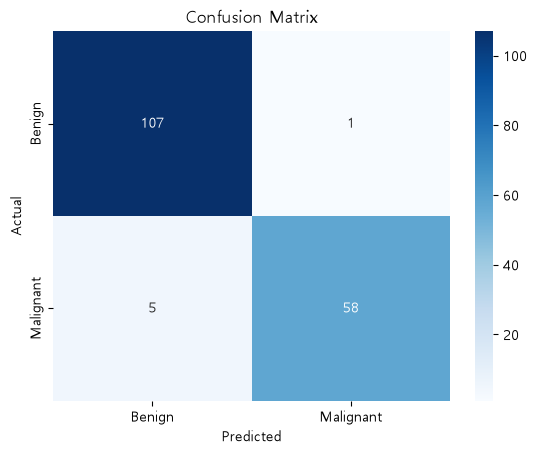

In [320]:
# 혼동행렬 시각화
conf_matrix = confusion_matrix(y_test, y_pred)
# [개선] 축 이름을 레이블 번호 순서에 맞춤 → LabelEncoder는 B=0, M=1이므로 0(양성), 1(악성) 순서로 지정
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**혼동행렬 그래프 해석**

| | 예측: Benign (양성) | 예측: Malignant (악성) | 합계 |
|---|---|---|---|
| **실제: Benign** | **107** (TN) | **1** (FP) | 108 |
| **실제: Malignant** | **5** (FN) | **58** (TP) | 63 |

- **읽는 방향**: 세로축(Actual)이 실제 정답, 가로축(Predicted)이 모델 예측입니다. 같은 행의 숫자를 더하면 실제 환자 수(양성 108명, 악성 63명)가 됩니다.
- **색의 의미**: 숫자가 클수록 진한 파란색입니다(`cmap='Blues'`, 오른쪽 색 막대 참고). 대각선(왼쪽 위 107, 오른쪽 아래 58)이 진하고 나머지가 옅을수록 잘 맞힌 모델입니다.
- **왼쪽 위 107 (TN)**: 양성 환자 108명 중 107명을 정확히 양성으로 판정 → 특이도 107/108 = **0.991**
- **오른쪽 위 1 (FP)**: 양성인데 악성으로 잘못 판정한 1명 → 불필요한 추가 검사 대상
- **왼쪽 아래 5 (FN)**: 악성인데 양성으로 판정한 5명 → **가장 주의해야 할 칸**. 실제라면 암 진단이 늦어질 수 있는 환자들
- **오른쪽 아래 58 (TP)**: 악성 63명 중 58명을 정확히 찾아냄 → 재현율 58/63 = **0.921**

**정리**: 이 모델은 양성 환자는 거의 완벽하게 가려내지만(오류 1명), 악성 환자는 약 13명 중 1명꼴(5/63)로 놓칩니다. 위에서 본 "정밀도 > 재현율" 관계가 그래프에서는 **FN(5)이 FP(1)보다 크다**는 형태로 나타납니다.

**코드 설명**

위 코드는 앙상블 모델의 예측 결과를 혼동행렬로 시각화합니다. `confusion_matrix(y_test, y_pred)`가 실제 값과 예측 값을 비교해 2×2 표를 만들고, seaborn의 `heatmap` 함수로 그림을 그립니다.

| 옵션 | 역할 |
|---|---|
| `annot=True` | 각 칸에 숫자를 표시 |
| `fmt='d'` | 숫자를 정수(decimal)로 표시 (지정하지 않으면 소수점 표기) |
| `cmap='Blues'` | 값이 클수록 진한 파란색으로 칠함 |
| `xticklabels`, `yticklabels` | 축 눈금 이름. `confusion_matrix`는 레이블 번호 순서(0, 1)대로 칸을 만드므로 `["Benign", "Malignant"]` 순서로 지정 |
| `plt.xlabel("Predicted")`, `plt.ylabel("Actual")` | 가로축 = 예측값, 세로축 = 실제값 |
| `plt.title("Confusion Matrix")` | 그래프 제목 |

> **개선 사항 — 혼동행렬 축 이름 순서**: 기존 코드는 축 이름을 `["Malignant", "Benign"]` 순서로 붙였는데, 이는 악성을 0으로 가정한 것이었습니다. 실제로 `LabelEncoder`는 알파벳 순서에 따라 B(양성) = 0, M(악성) = 1을 부여하므로, 그대로 두면 **양성 환자 칸에 Malignant라는 이름표가 붙어 해석이 정반대**가 됩니다(예: 놓친 암 환자 5명이 오경보 5명처럼 보임). 이 노트북에서는 `["Benign", "Malignant"]`로 바로잡아 그래프와 실제 데이터가 일치하도록 했습니다.

### 6. 제안된 방법론 

제안된 ELRL-E 모델은 앙상블 학습을 기반으로 설계되어 유방암 진단의 정확도를 향상시키는  
것을 목표로 합니다. 이 모델은 데이터 전처리, 개별 모델 학습, 투표 기반 예측, 모델 검증의  
네 가지 주요 단계로 구성됩니다. 각 단계를 서술식으로 설명하며 Python 코드 예제를 함께  
제공합니다.

(1) 데이터 전처리

ELRL-E 모델 설계의 첫 번째 단계는 데이터를 학습 가능한 상태로 준비하는 것입니다. 이  
과정에서는 결측값 처리, 데이터 정규화, 그리고 중요한 특성을 선택합니다. 데이터의 일관성을  
유지하고 분석의 정확도를 높이기 위해 필수적인 과정입니다.

In [321]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [322]:
# 결측값 처리
# [개선] 기존: data.fillna(data.mean(), inplace=True) → 문자 열이 있으면 최신 pandas(2.x 이상)에서 TypeError
data = data.fillna(data.mean(numeric_only=True))

> **개선 사항 — 결측값 평균 대체**: 기존 코드 `data.fillna(data.mean(), inplace=True)`는 예전 pandas(1.x)에서는 글자 열을 자동으로 건너뛰었지만, 최신 pandas(2.x 이상)에서는 글자 열의 평균까지 계산하려다 `TypeError`로 멈춥니다. 이 노트북에서는 `data.mean(numeric_only=True)`로 **숫자 열만** 평균을 계산하도록 바꿨습니다. WBCD에는 결측값이 없어 결과는 동일하며, 결측값이 있는 다른 데이터에 이 코드를 재사용해도 안전하게 동작합니다.

위 코드는 데이터 전처리를 위한 도구들을 임포트하고 결측값을 처리하는 과정입니다.  
scikit-learn의 preprocessing 모듈에서 StandardScaler를 가져오는데, 이는 데이터를  
표준화하는데 사용됩니다. feature_selection 모듈에서는 SelectKBest와 f_classif를  
임포트하는데, 이는 특성 선택을 위한 도구들입니다. SelectKBest는 지정된 수의 최상위 특성을  
선택하고, f_classif는 분류 문제에서 특성의 중요도를 평가하는 F-검정 통계량을 계산합니다.

그리고 `data = data.fillna(data.mean(numeric_only=True))` 명령으로 데이터셋의 결측값을 처리합니다.  
`data.mean(numeric_only=True)`로 숫자 열마다 평균을 구하고, `fillna()`로 빈칸을 그 평균값으로 채운 뒤  
결과를 다시 `data`에 저장합니다.

In [323]:
# 특성 선택 (상위 9개 특성 선택)
selector = SelectKBest(score_func=f_classif, k=9)
X_selected = selector.fit_transform(X, y)

In [324]:
# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

위 코드는 특성 선택과 데이터 정규화를 수행하는 과정입니다. 먼저 SelectKBest를 사용하여  
특성을 선택하는데, score_func=f_classif로 F-검정을 기반으로 특성의 중요도를 평가하고,  
k=9로 설정하여 상위 9개의 특성만을 선택합니다. 이 선택된 특성들은  
selector.fit_transform(X, y)를 통해 X_selected에 저장됩니다.

그 다음으로는 StandardScaler를 사용하여 선택된 특성들을 정규화합니다.  
scaler.fit_transform(X_selected) 명령을 통해 데이터를 평균이 0, 표준편차가 1이 되도록  
변환하며, 이 정규화된 데이터는 X_scaled에 저장됩니다.

(2) 모델 학습

각 기초 학습기를 훈련 데이터로 개별 학습시킵니다. 제안된 모델에서는 Extra Trees  
Classifier(ETC), LightGBM, Ridge Classifier(RC), Linear Discriminant Analysis(LDA)와 같은  
네 가지 알고리즘이 사용됩니다. 각 알고리즘은 데이터를 다르게 학습하며, 결합 시 높은 성능을  
발휘할 수 있습니다.

In [325]:
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

위 코드는 다양한 분류기를 scikit-learn과 LightGBM 라이브러리에서 임포트하는 과정입니다.  
ExtraTreesClassifier는 앙상블 학습 방법 중 하나로, 랜덤 포레스트와 유사하지만 더 많은  
무작위성을 도입한 모델입니다. LGBMClassifier는 그래디언트 부스팅 계열의 모델로 빠른 속도와  
높은 성능이 특징입니다. RidgeClassifier는 L2 정규화를 사용하는 선형 분류기이며,  
LinearDiscriminantAnalysis는 클래스 간 분산은 최대화하고 클래스 내 분산은 최소화하는  
방식으로 작동하는 분류 알고리즘입니다.

In [326]:
# 개별 모델 정의
etc = ExtraTreesClassifier(random_state=42)
lgbm = LGBMClassifier(random_state=42, verbose=-1)
ridge = RidgeClassifier()
lda = LinearDiscriminantAnalysis()

위 코드는 앙상블 모델에서 사용될 네 가지 개별 분류기들을 초기화하는 과정입니다.  
ExtraTreesClassifier는 'etc'라는 이름으로 초기화되며 재현성을 위해 random_state를 42로  
설정합니다. LightGBM의 분류기인 LGBMClassifier도 'lgbm'이라는 이름으로 정의되고 마찬가지로  
random_state가 42로 설정됩니다. RidgeClassifier는 'ridge'라는 이름으로,  
LinearDiscriminantAnalysis는 'lda'라는 이름으로 각각 기본 파라미터를 사용하여  
초기화됩니다.

In [327]:
# 모델 학습
etc.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lda.fit(X_train, y_train) 

LinearDiscriminantAnalysis()

**참고 — LightGBM이 출력하는 로그 메시지 자세히 보기**

**LightGBM이란?** Microsoft가 만든 그래디언트 부스팅(Gradient Boosting) 라이브러리입니다. 부스팅은 작은 결정 트리를 **하나씩 차례로** 만들면서, 다음 트리가 앞의 트리들이 틀린 부분(오차)을 집중적으로 보완하게 하는 방식입니다. LightGBM은 연속된 값을 몇 개의 구간(bin)으로 묶어 계산량을 줄이고, 오차를 가장 많이 줄이는 잎(leaf)부터 트리를 키우는 방식(leaf-wise)이라 빠르고 정확도가 높은 것이 특징입니다.

**기본 설정으로 학습하면 아래와 같은 로그가 나옵니다.** 에러가 아니라 학습 과정 보고서입니다.

| 로그 | 의미 |
|---|---|
| `[Info] Number of positive: 149, number of negative: 249` | 훈련 데이터 398명 중 악성(1) 149명, 양성(0) 249명 |
| `[Info] Total Bins 1192` | 9개 특성의 연속값을 구간(bin)으로 나눈 총 개수. 특성마다 최대 255개 구간 |
| `[Info] Number of data points in the train set: 398, number of used features: 9` | 학습에 쓴 샘플 수와 특성 수 |
| `[Info] Auto-choosing col-wise multi-threading ...` | 병렬 계산 방식을 자동으로 골랐다는 안내. `force_col_wise=True`를 주면 이 테스트 과정을 생략 |
| `[Info] [binary:BoostFromScore]: pavg=0.374372 -> initscore=-0.513507` | 학습의 출발점(초기 점수). 훈련 데이터의 악성 비율 149/398 = 0.374를 로그 오즈(log-odds) ln(0.374 ÷ 0.626) ≈ −0.51로 바꾼 값에서 시작 |
| `[Warning] No further splits with positive gain, best gain: -inf` | 아래 설명 참고 |

**`No further splits with positive gain` 경고의 의미**

- LightGBM은 기본으로 트리 100개(`n_estimators=100`)를 만듭니다. 트리를 만들 때마다 "어디서 데이터를 둘로 나누면 오차가 줄어드는가(gain, 이득)"를 찾는데, **오차를 줄이는 분할 지점을 하나도 찾지 못하면** 이 경고를 출력하고 그 트리는 사실상 아무것도 하지 않은 채 끝납니다.
- 이 데이터에서는 100번 중 약 94번 이 경고가 나옵니다(같은 설정으로 실행한 기준). 원인은 두 가지입니다.
  1. **데이터가 작습니다**: 훈련 데이터가 398명뿐이고, LightGBM은 기본적으로 잎 하나에 최소 20개 샘플(`min_child_samples=20`)이 있어야 분할을 허용합니다.
  2. **이미 잘 맞히고 있습니다**: 처음 몇 개의 트리만으로 양성·악성이 거의 다 구분되어, 뒤쪽 트리가 더 고칠 오차가 남지 않습니다.
- 예측 결과는 정상이며 오류도 아닙니다. 다만 "트리 100개가 다 필요하지 않다"는 신호이므로, 실무에서는 `n_estimators`를 줄이거나 `min_child_samples`를 낮추는 식으로 조정할 수 있습니다.

**`verbose=-1`로 로그를 끈 이유**

| `verbose` 값 | 출력되는 내용 |
|---|---|
| `< 0` (예: -1) | 치명적 오류(Fatal)만 출력 → 사실상 로그 없음 |
| `0` | 오류·경고까지 출력 |
| `1` | 정보(Info)까지 출력 |
| `> 1` | 디버그용 상세 정보까지 출력 |

이 노트북에서는 결과를 읽기 쉽도록 모델 정의 셀에서 `verbose=-1`을 지정했습니다. 로그를 직접 보고 싶다면 모델 정의 셀의 `verbose=-1`을 지우고 다시 실행해 보면 됩니다. (4번 모델링 기법 절의 `LGBMClassifier(random_state=42)`에는 `verbose`가 없어서 실행 환경에 따라 위 로그가 출력될 수 있습니다.)

위 코드는 앞서 정의한 네 개의 개별 분류기들을 학습 데이터로 학습시키는 과정입니다. 각각의  
분류기(ExtraTreesClassifier, LGBMClassifier, RidgeClassifier,  
LinearDiscriminantAnalysis)에 대해 fit() 메서드를 호출하여 학습을 수행합니다. fit()  
메서드는 학습 데이터의 특성(X_train)과 레이블(y_train)을 입력받아 모델의 파라미터를  
최적화합니다. 이 과정이 완료되면 각 모델은 새로운 데이터에 대한 예측을 수행할 수 있는  
상태가 됩니다.

(3) 투표 앙상블

각 기초 학습기의 예측 결과를 투표 방식으로 결합합니다. 하드 보팅 방식을 사용하여 다수결의  
원칙에 따라 최종 예측을 수행합니다. 이 과정은 개별 모델의 강점을 결합하여 신뢰성과  
정확도를 높이는 데 효과적입니다.

In [328]:
from sklearn.ensemble import VotingClassifier

In [329]:
# 앙상블 모델 정의
voting_clf = VotingClassifier(
    estimators=[
        ('ExtraTrees', etc),
        ('LightGBM', lgbm),
        ('Ridge', ridge),
        ('LDA', lda)
    ],
    voting='hard'  # 하드 보팅
)

위 코드는 VotingClassifier를 사용하여 앙상블 모델을 구성하는 과정입니다. VotingClassifier의 `estimators` 파라미터에는 앞서 정의한 네 개의 개별 분류기가 `('이름', 분류기)` 형태의 튜플(tuple, 여러 값을 괄호로 묶은 바꿀 수 없는 묶음)로 전달됩니다. ExtraTreesClassifier, LGBMClassifier, RidgeClassifier, LinearDiscriminantAnalysis에는 각각 `'ExtraTrees'`, `'LightGBM'`, `'Ridge'`, `'LDA'`라는 이름이 붙으며, 이 이름은 학습 후 `voting_clf.named_estimators_['Ridge']`처럼 앙상블 안의 개별 모델을 꺼내 볼 때 사용됩니다. `voting='hard'`는 하드 보팅 방식으로, 네 모델이 예측한 클래스 중 가장 많이 나온 클래스를 최종 예측값으로 고르는 다수결 방식입니다.

In [330]:
# 앙상블 모델 학습
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('ExtraTrees',
                              ExtraTreesClassifier(random_state=42)),
                             ('LightGBM',
                              LGBMClassifier(random_state=42, verbose=-1)),
                             ('Ridge', RidgeClassifier()),
                             ('LDA', LinearDiscriminantAnalysis())])

**코드 설명 — `voting_clf.fit(X_train, y_train)` 한 줄이 하는 일**

`fit()`을 한 번 호출하면 앙상블 내부에서 다음 과정이 차례로 일어납니다.

1. **복제(clone)**: `estimators`에 넣은 네 모델의 **설정만 그대로 복사한 새 모델**을 만듭니다. 그래서 앞 셀(`etc.fit(...)` 등)에서 따로 학습시킨 모델이 그대로 쓰이는 것이 아니라, 앙상블은 자기만의 복사본을 처음부터 다시 학습합니다.
2. **각자 학습**: 네 복사본이 **같은 훈련 데이터**(`X_train` 398명 × 9개 특성, `y_train`)로 각각 학습합니다. `n_jobs`를 지정하지 않으면(기본값 `None`) 한 번에 하나씩 순서대로 학습하고, `n_jobs=-1`을 주면 CPU 코어를 모두 써서 동시에 학습합니다.
3. **저장**: 학습이 끝난 모델들은 `voting_clf.estimators_`(목록)와 `voting_clf.named_estimators_`(이름으로 찾는 사전)에 저장되어, 이후 `predict()`에서 투표에 참여합니다.

**출력 결과 읽기**

```
VotingClassifier(estimators=[('ExtraTrees', ExtraTreesClassifier(random_state=42)),
                             ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
                             ('Ridge', RidgeClassifier()),
                             ('LDA', LinearDiscriminantAnalysis())])
```

- 이 출력은 학습 결과나 점수가 아닙니다. `fit()`은 학습을 마친 **모델 객체 자신을 돌려주고**, 노트북은 셀의 마지막 값을 자동으로 화면에 보여주기 때문에 **모델 설정 요약**이 찍힌 것입니다. 경고나 에러가 아닙니다.
- scikit-learn은 **기본값과 다른 설정만** 괄호 안에 보여줍니다. 그래서
  - `random_state=42`, `verbose=-1`처럼 직접 바꾼 값은 보이고,
  - `RidgeClassifier()`, `LinearDiscriminantAnalysis()`는 모두 기본값이라 빈 괄호로 나오며,
  - `voting='hard'`도 VotingClassifier의 기본값이 `'hard'`이기 때문에 출력에 나타나지 않습니다.
- 이 요약을 보면 **네 모델이 의도한 설정대로 앙상블에 들어갔는지** 확인할 수 있습니다. 출력을 숨기고 싶다면 줄 끝에 세미콜론(`;`)을 붙이면 됩니다.

(4) 모델 검증

모델 검증 단계에서는 테스트 데이터로 정확도, 정밀도, 재현율, F1 점수, AUC를 계산해 모델의  
성능을 평가합니다.

In [331]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [332]:
# 테스트 데이터 예측
y_pred = voting_clf.predict(X_test)

위 코드는 평가 지표 함수들을 불러온 뒤, 학습된 앙상블 모델로 테스트 데이터를 예측해 그  
결과를 y_pred에 저장합니다.

In [333]:
# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# [개선] 기존: auc = roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])
#        → 하드 보팅은 predict_proba가 없어 AttributeError → 4개 모델의 투표 비율을 점수로 사용
auc = roc_auc_score(y_test, voting_clf.transform(X_test).mean(axis=1))

**코드 설명 — 성능 평가**

이 셀은 5번(성능 평가 방법)과 같은 방식으로 다섯 가지 지표를 구합니다. 지표의 공식과 뜻은 **5번 성능 평가 방법의 (0)~(6)**을 참고하면 됩니다.

| 코드 | 하는 일 |
|---|---|
| `accuracy_score(y_test, y_pred)` | 정확도 = (TP+TN) / 전체 |
| `precision_score(y_test, y_pred)` | 정밀도 = TP / (TP+FP), 악성(1) 기준 |
| `recall_score(y_test, y_pred)` | 재현율 = TP / (TP+FN), 악성(1) 기준 |
| `f1_score(y_test, y_pred)` | 정밀도와 재현율의 조화평균 |
| `voting_clf.transform(X_test).mean(axis=1)` | 4개 모델의 0/1 투표를 환자마다 평균 → 악성 투표 비율(0~1) |
| `roc_auc_score(y_test, 위 점수)` | 투표 비율을 점수로 써서 AUC 계산 |

계산만 하고, 출력은 다음 셀에서 따로 합니다.

In [334]:
print(f"정확도: {accuracy:.2f}")
print(f"정밀도: {precision:.2f}")
print(f"재현율: {recall:.2f}")
print(f"F1 점수: {f1:.2f}")
print(f"AUC: {auc:.2f}")

정확도: 0.96
정밀도: 0.98
재현율: 0.92
F1 점수: 0.95
AUC: 0.98


**결과 해석**

| 지표 | 값 | 의미 |
|---|---|---|
| 정확도 | 0.96 | 테스트 환자 171명 중 165명을 맞힘 |
| 정밀도 | 0.98 | "악성"이라고 판정한 59명 중 58명이 실제 악성 |
| 재현율 | 0.92 | 실제 악성 63명 중 58명을 찾고 5명을 놓침 |
| F1 점수 | 0.95 | 정밀도·재현율의 균형 점수 |
| AUC | 0.98 | 점수 기준으로 악성·양성을 거의 완벽히 구분 |

- **5번(성능 평가 방법)의 결과와 소수점까지 똑같습니다.** 6번은 5번과 같은 데이터(wdbc.data), 같은 전처리(상위 9개 특성 선택 + 표준화), 같은 분할(`random_state=42`, 70 : 30), 같은 네 모델 설정을 단계별로 다시 정리한 것이기 때문입니다. 즉 6번은 "새로운 실험"이 아니라 **ELRL-E 방법론을 순서대로 다시 구현해 본 것**이며, 같은 결과가 나온다는 것 자체가 **재현성(같은 조건이면 같은 결과가 나오는 성질)**을 확인해 줍니다.
- 수치 사이의 관계(정밀도 > 재현율 → 보수적인 모델, 놓친 5명 중 3명이 2 : 2 동점 투표)는 5번의 결과 해석과 같습니다.

> **개선 사항 — 하드 보팅 모델의 AUC 계산**: 기존 코드 `roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])`는 하드 보팅 모델에 확률 예측(`predict_proba`) 기능이 없어 `AttributeError`로 중단되었습니다. 이 노트북에서는 5번과 같은 방식으로 **네 모델 중 악성(1)에 투표한 비율**을 점수로 사용해 AUC를 계산했습니다. 이 절의 데이터는 `wdbc.data`를 `LabelEncoder`로 변환한 것이라 **B(양성) = 0, M(악성) = 1**이며, 따라서 정밀도·재현율은 모두 **"악성을 얼마나 잘 잡아냈는가"**를 나타냅니다.

> 각 평가지표(정확도·정밀도·재현율·F1·AUC)의 자세한 뜻과 공식, 혼동행렬 읽는 법은 **Step 3의 5번 성능 평가 방법**에 정리되어 있습니다.

ELRL-E의 전체 흐름은 데이터 전처리 → 기초 모델 개별 학습 → 투표 앙상블 예측 → 성능 검증  
순서입니다. 다음은 전체 방법을 정리한 구성도입니다.

**ELRL-E 구성도**

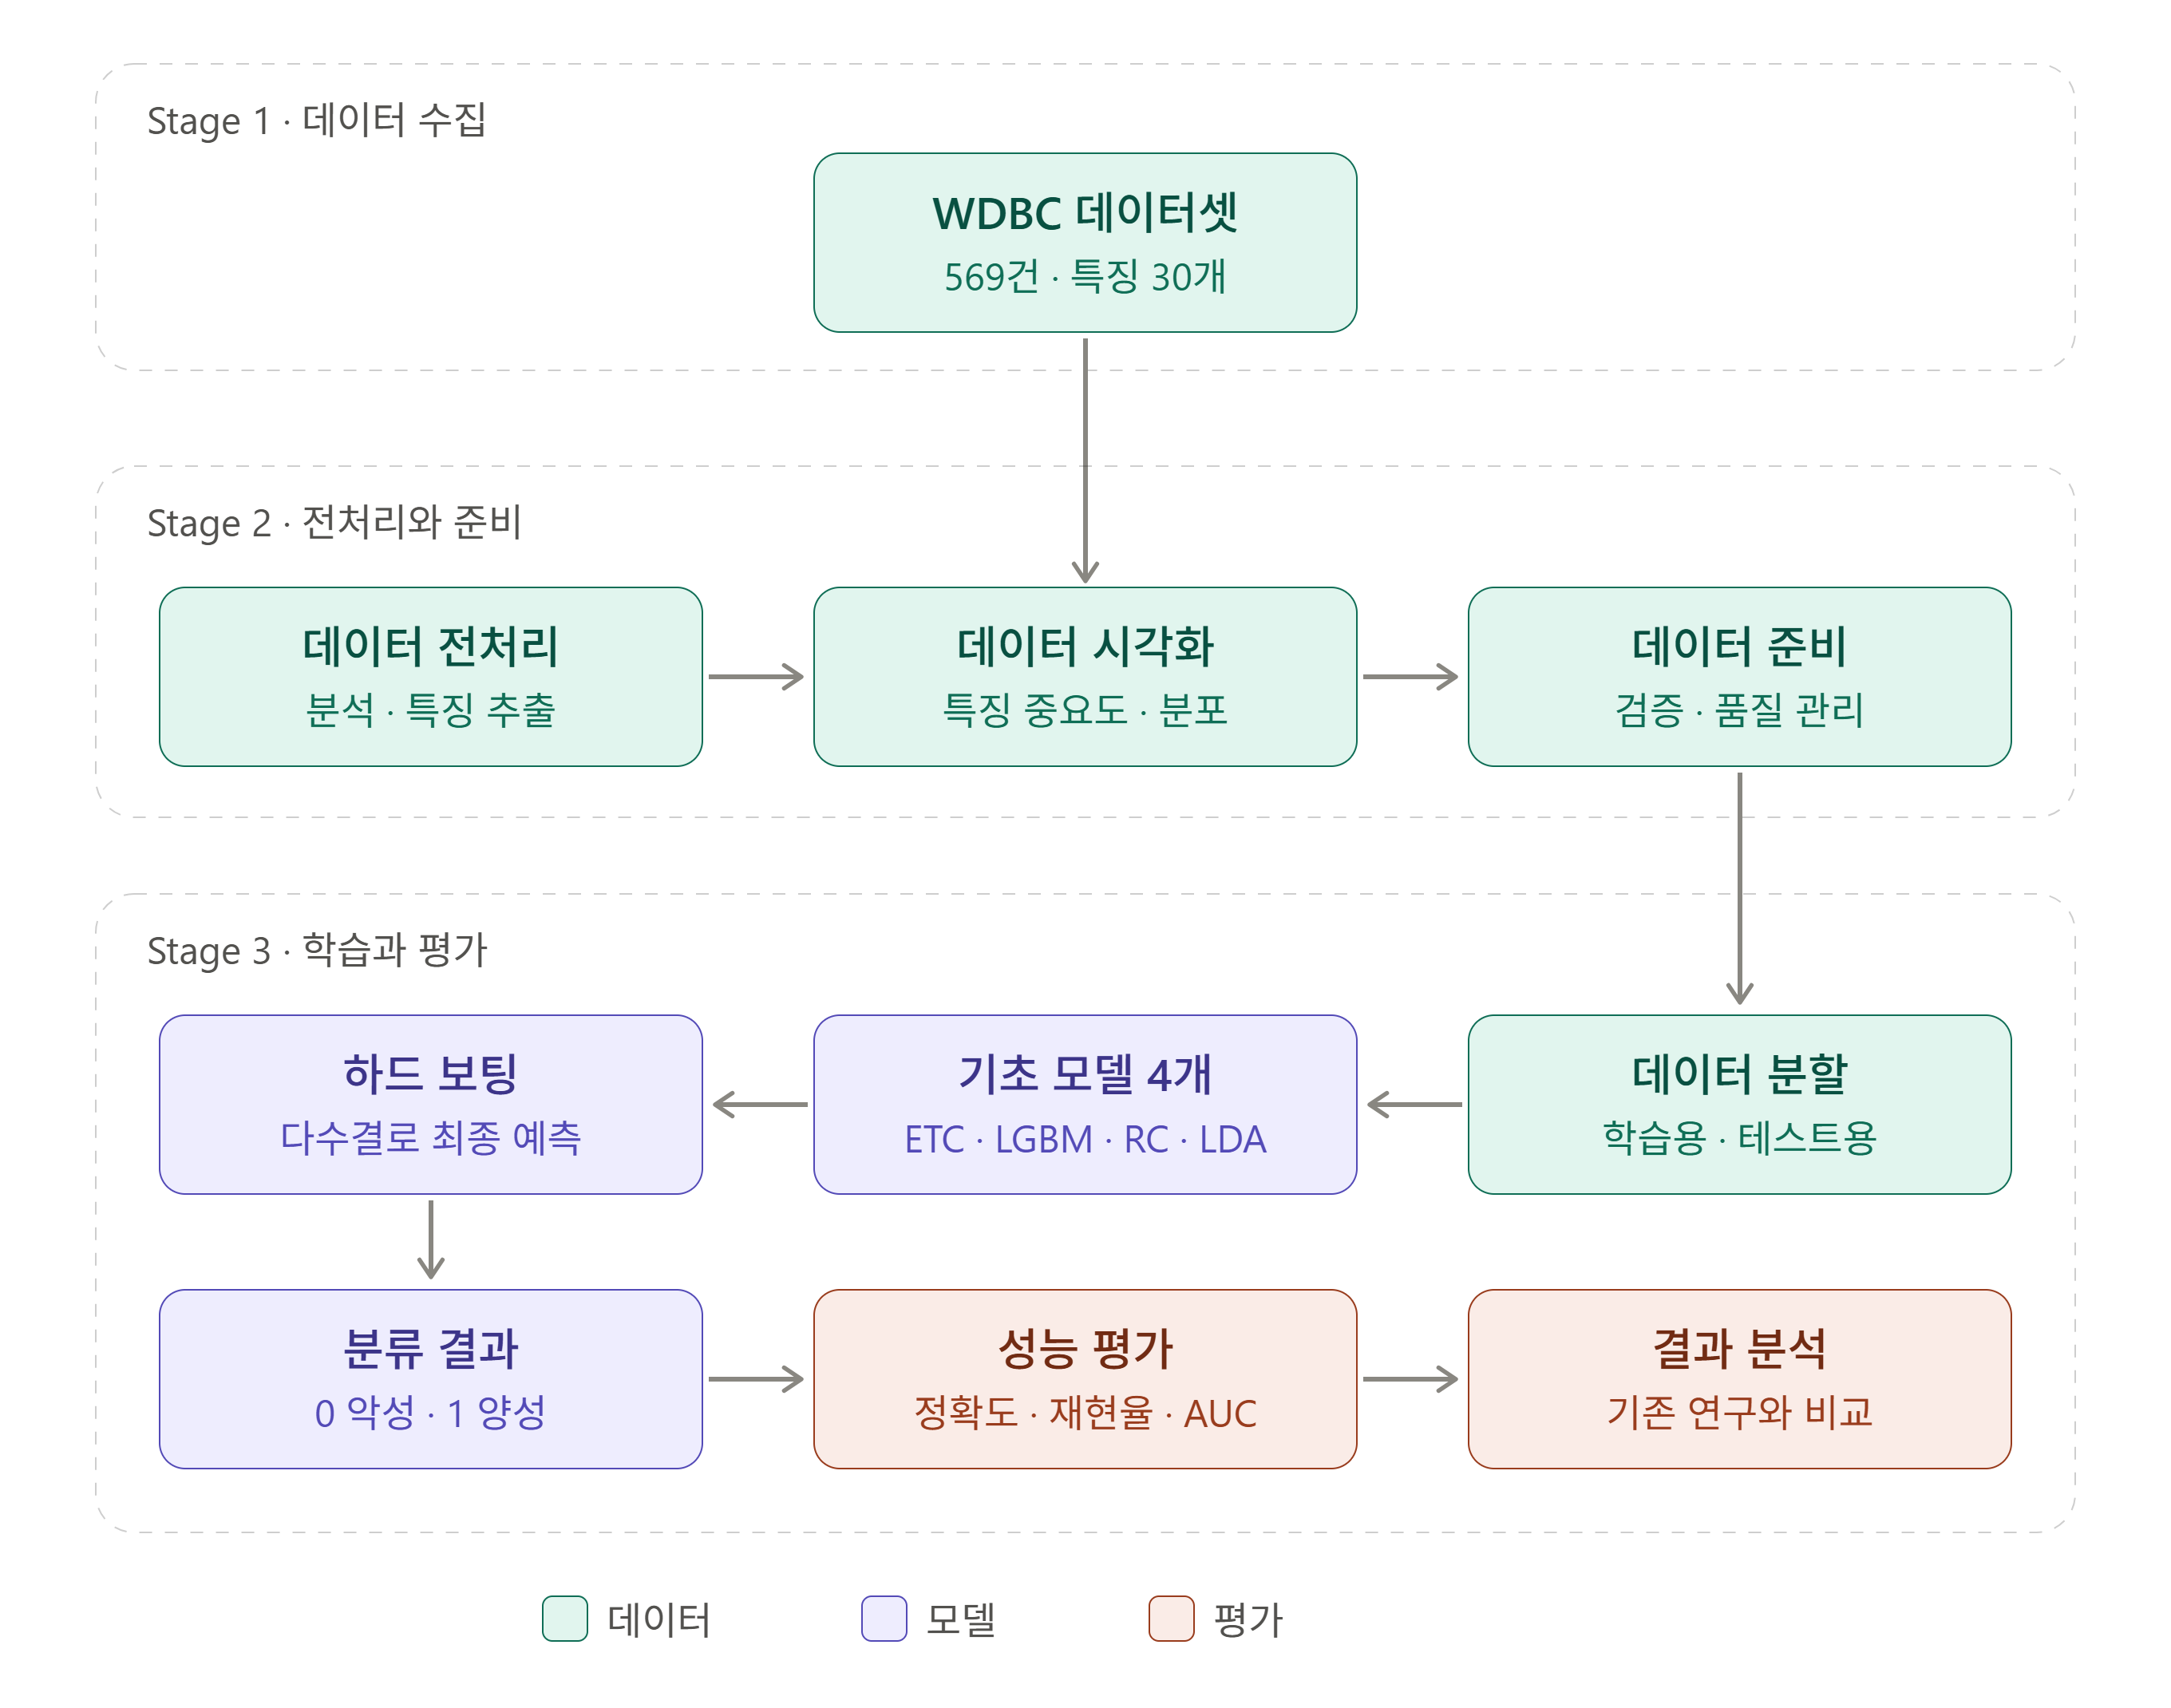

**구성도 단계별 설명**

ELRL-E는 **E**xtra Trees · **L**ightGBM · **R**idge · **L**DA 네 모델을 **E**nsemble(앙상블)한다는 뜻의 이름입니다. 구성도는 세 단계(Stage)로 나뉘며, 화살표를 따라 위에서 아래로, Stage 3 안에서는 오른쪽 → 왼쪽 → 아래 → 오른쪽 순서로 진행됩니다. 색은 역할을 나타냅니다(초록 = 데이터 처리, 보라 = 모델, 빨강 = 평가).

**Stage 1 · 데이터 수집**

| 단계 | 하는 일 | 이 노트북의 위치 |
|---|---|---|
| WDBC 데이터셋 (569건 · 특징 30개) | UCI 저장소에서 위스콘신 유방암 진단 데이터를 불러옴. 환자 569명, 세포핵 측정값 30개, 진단(M/B) | 3-1 데이터셋, 3번 전처리의 데이터 불러오기 |

**Stage 2 · 전처리와 준비**

| 단계 | 하는 일 | 이 노트북의 위치 |
|---|---|---|
| 데이터 전처리 (분석 · 특징 추출) | 결측값 처리, 진단 글자(M/B)를 숫자로 변환, F-검정으로 진단과 관련이 큰 상위 9개 특성 선택 | 3번 데이터 전처리, 6번 (1) |
| 데이터 시각화 (특징 중요도 · 분포) | 박스플롯·히트맵·히스토그램으로 특성의 분포, 양성·악성 차이, 특성 간 상관관계를 확인 | 2번 탐색적 데이터 분석 |
| 데이터 준비 (검증 · 품질 관리) | 특성마다 다른 숫자 크기를 표준화(평균 0, 표준편차 1)로 맞추고, 결측값·이상값 여부를 점검해 학습 가능한 형태로 정리 | 3번 스케일링, 6번 (1) |

**Stage 3 · 학습과 평가**

| 단계 | 하는 일 | 이 노트북의 위치 |
|---|---|---|
| 데이터 분할 (학습용 · 테스트용) | 전체를 70%(398명) 학습용, 30%(171명) 테스트용으로 나눔. 테스트용은 학습에 쓰지 않고 마지막 평가에만 사용 | 3번 데이터 분할 |
| 기초 모델 4개 (ETC · LGBM · RC · LDA) | 성격이 다른 네 모델을 같은 학습 데이터로 각각 학습 | 6번 (2) 모델 학습 |
| 하드 보팅 (다수결로 최종 예측) | 네 모델의 0/1 예측 중 많이 나온 쪽을 최종 답으로 선택. 2 : 2 동점이면 번호가 작은 클래스(0) 선택 | 6번 (3) 투표 앙상블 |
| 분류 결과 | 환자마다 최종 진단(0 또는 1)이 정해짐 | 예측 결과 `y_pred` |
| 성능 평가 (정확도 · 재현율 · AUC) | 테스트 데이터의 실제 정답과 비교해 지표 계산 | 5번, 6번 (4) 모델 검증 |
| 결과 분석 (기존 연구와 비교) | SVM 단일 모델 등 기존 연구의 성능과 비교해 개선 정도를 확인 | 2-4, 2-5, 7번 |

> **레이블 표기 주의**: 구성도의 "분류 결과" 상자에는 `0 악성 · 1 양성`으로 적혀 있는데, 이는 기존 자료의 번호 체계(악성 = 0)를 따른 표기입니다. 이 노트북의 Step 3은 `LabelEncoder`가 알파벳 순서로 번호를 붙이기 때문에 **0 = 양성(B), 1 = 악성(M)**입니다. 결과를 읽을 때는 노트북의 번호 체계를 기준으로 해석하면 됩니다.

### 7. 실험 환경

실험은 Python 환경에서 진행했으며, 사용한 라이브러리는 다음과 같습니다.

- Scikit-learn: 데이터 전처리, 모델 학습 및 평가
- LightGBM: 부스팅 기반 알고리즘 구현
- Pandas, NumPy: 데이터 조작과 수치 계산
- Matplotlib, Seaborn: 데이터 시각화와 결과 분석

하드웨어는 Intel Core i7 프로세서, 16GB RAM, Windows 10 운영체제입니다. 이 구성은 WBCD  
같은 중소 규모 데이터셋으로 모델을 학습하고 평가하기에 충분하며, 이러한  
하드웨어·소프트웨어 정보는 같은 실험을 다시 해 볼 때(재현성) 기준이 됩니다.

정리하면, Extra Trees Classifier, LightGBM, Ridge Classifier, Linear Discriminant  
Analysis를 결합한 ELRL-E 모델은 데이터 불균형 문제를 다루면서 기존 연구보다 좋은 성능을  
보였고, 의료 데이터 분석과 진단 모델 발전에 기여할 수 있는 가능성을 제시했습니다.

## Step 4. 전체 코드 개요 
아래는 주어진 코드에 대한 단계별 서술식 설명입니다. 각 부분의 역할과 기능을 자세히  
설명합니다.

### 1. 필요한 패키지 불러오기

이 코드는 데이터 분석과 머신러닝을 위한 주요 라이브러리를 불러오는 것으로 시작합니다. 먼저  
NumPy는 수치 계산을 효율적으로 수행하는 데 사용되며, 특히 배열 연산과 같은 작업에  
적합합니다. Pandas는 데이터를 표 형식으로 다루는 데 유용하며, 데이터프레임 구조를 사용해  
데이터를 정리하고 조작하는 기능을 제공합니다. Matplotlib와 그 하위 모듈인 pyplot은  
데이터를 시각화하기 위한 도구로, 그래프와 차트를 쉽게 생성할 수 있습니다.

Scikit-learn은 머신러닝 모델을 구현하고 평가하기 위한 라이브러리로, 이 코드에서는 데이터  
전처리, 데이터 분할, 모델 학습 및 평가에 활용됩니다. 예를 들어 preprocessing 모듈은  
데이터를 정규화하거나 스케일링하는 작업에 사용됩니다. train_test_split 함수는 데이터를  
학습용과 테스트용으로 분리하고, KFold는 교차 검증을 수행하며, cross_val_score는 모델  
성능을 평가합니다. KNeighborsClassifier와 SVC는 각각 K-최근접 이웃(KNN) 알고리즘과 서포트  
벡터 머신(SVM) 알고리즘을 사용해 분류 작업을 수행합니다.

classification_report와 accuracy_score는 모델의 성능을 평가하기 위한 지표를 제공합니다.  
classification_report는 정밀도, 재현율, F1 점수와 같은 평가 메트릭을 포함하며,  
accuracy_score는 전체 정확도를 계산합니다. 마지막으로 scatter_matrix는 Pandas의 시각화  
도구로, 데이터프레임의 여러 열 간 관계를 산점도로 표현하여 데이터 분포와 상관관계를  
파악하는 데 도움을 줍니다.

이렇게 다양한 라이브러리를 사용함으로써 데이터 분석과 머신러닝 워크플로우를 전반적으로  
지원할 수 있습니다.

In [335]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from pandas.plotting import scatter_matrix

**라이브러리 코드 한 줄씩 살펴보기**

먼저 두 가지 불러오기 문법의 차이입니다.

- `import 라이브러리 as 별칭`: 라이브러리 전체를 불러오고, 짧은 별명으로 부름. 예) `import numpy as np` → 이후 `np.array()`처럼 사용
- `from 라이브러리.모듈 import 이름`: 라이브러리 안의 특정 기능만 꺼내 옴. 예) `from sklearn.svm import SVC` → 이후 `SVC()`를 바로 사용

| 코드 | 무엇인가 | 이 Step에서 쓰는 곳 |
|---|---|---|
| `import sys` | 파이썬 실행 환경 자체의 정보를 다루는 기본 모듈 | 2번에서 `sys.version`으로 파이썬 버전 확인 |
| `import numpy as np` | 숫자 배열(행렬) 계산 라이브러리. `np`라는 별칭이 관례 | 결측값 표시 `np.nan`, 샘플 데이터 배열 `np.array` |
| `import matplotlib` | 그래프 라이브러리의 본체 | 2번에서 버전 확인용 |
| `import matplotlib.pyplot as plt` | matplotlib에서 실제로 그래프를 그리는 도구 모음. `plt` 별칭이 관례 | `plt.show()`로 그래프 출력, 제목·축 이름 설정 |
| `import pandas as pd` | 표(DataFrame) 형태의 데이터를 다루는 라이브러리 | `pd.read_csv()`로 데이터 불러오기 |
| `import sklearn` | 머신러닝 라이브러리 scikit-learn의 본체 | 2번에서 버전 확인용 |
| `from sklearn import preprocessing` | 정규화·표준화·인코딩 같은 전처리 도구 모음 | 이 Step에서는 불러오기만 하고 직접 쓰지는 않음 |
| `from sklearn.model_selection import train_test_split` | 데이터를 학습용/테스트용으로 나누는 함수 | 5번 데이터 분할 |
| `... import KFold` | 데이터를 K개 묶음으로 나눠 돌아가며 검증하는 교차 검증 분할기 | Step 5의 4번 |
| `... import cross_val_score` | 교차 검증을 실행하고 묶음별 점수를 돌려주는 함수 | 6번 모델 교차 검증 |
| `from sklearn.neighbors import KNeighborsClassifier` | K-최근접 이웃(KNN) 분류기: 가장 가까운 K개 이웃의 다수결로 분류 | 6번 KNN 모델 |
| `from sklearn.svm import SVC` | 서포트 벡터 머신(SVM) 분류기: 두 클래스 사이의 경계를 최대한 넓게 긋는 모델 | 6번·8번 SVM 모델 |
| `from sklearn.metrics import classification_report` | 클래스별 정밀도·재현율·F1·샘플 수를 표로 출력 | 7번 모델 평가 |
| `... import accuracy_score` | 정확도 계산 | 7번 모델 평가 |
| `from pandas.plotting import scatter_matrix` | 모든 변수 쌍의 산점도를 격자로 그려주는 함수 | 4번 산점도 행렬 |

이 셀은 결과를 출력하지 않습니다. 오류 없이 실행되면 모든 라이브러리가 정상적으로 설치되어 있다는 뜻이고, `ModuleNotFoundError`가 나오면 해당 라이브러리를 설치해야 합니다(VS Code 노트북 셀에서 `%pip install 라이브러리이름` 실행 후 커널 다시 시작).

### 2. 라이브러리 버전 확인
다음 코드는 실행 환경에서 사용 중인 Python과 주요 라이브러리들의 버전을 출력하여  
확인합니다. 이는 코드 실행의 재현성을 보장하고, 개발 환경이나 라이브러리의 특정 버전에서  
발생할 수 있는 문제를 사전에 파악하고 해결하는 데 매우 유용합니다.

In [336]:
print('Python: {}'.format(sys.version))
print('Numpy: {}'.format(np.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Pandas: {}'.format(pd.__version__))
print('Scikit-learn: {}'.format(sklearn.__version__))

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Numpy: 2.5.0
Matplotlib: 3.11.2
Pandas: 3.0.3
Scikit-learn: 1.9.1


우선 sys.version을 사용하여 현재 실행 중인 Python의 버전을 출력합니다. Python은 주기적으로  
업데이트되며, 각 버전 간 기능이나 호환성 차이가 있을 수 있기 때문에 실행 환경을 명확히  
하는 것이 중요합니다.

그다음, np.__version__, matplotlib.__version__, pd.__version__, sklearn.__version__을  
호출하여 각각 NumPy, Matplotlib, Pandas, Scikit-learn의 버전을 출력합니다. 이는 각  
라이브러리의 사용 가능한 기능과 잠재적 오류를 확인하는 데 도움을 줍니다. 특히 머신러닝  
작업에서는 Scikit-learn의 버전이 중요하며, 데이터 처리를 위한 Pandas와 수치 연산을 위한  
NumPy의 버전도 작업의 성공 여부에 큰 영향을 미칩니다.

이와 같은 방식으로 버전을 명시적으로 출력하면, 다른 환경에서 동일한 코드를 실행할 때  
필요한 라이브러리를 정확한 버전으로 설치하여 동일한 결과를 얻을 수 있습니다. 이는 협업이나  
배포 시에도 중요한 정보로 활용됩니다.

### 3. 데이터 로드 및 전처리

UCI 머신러닝 저장소에서 제공하는 데이터셋을 불러와 데이터 전처리를 수행하는 과정과  
관련하여 알아보겠습니다.

In [337]:
# UCI 데이터셋 URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

위 코드는 UCI(University of California, Irvine) 머신러닝 저장소에서 제공하는 심장병  
데이터셋의 URL을 지정하는 부분입니다. 구체적으로 Cleveland 병원에서 수집된  
처리된(processed) 심장병 데이터셋의 위치를 url 변수에 저장합니다. 이 URL은 이후 pandas의  
read_csv 함수를 통해 데이터를 직접 불러오는 데 사용됩니다.

In [338]:
# 데이터셋 열 이름 정의
column_names = [
    'age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'serum_cholesterol',
    'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_induced_angina',
    'st_depression', 'st_slope', 'num_major_vessels', 'thalassemia', 'target'
]

위 코드는 심장병 데이터셋의 각 특성에 대한 이름을 정의하는 과정을 보여줍니다.  
column_names라는 리스트에 데이터셋의 14개 특성에 대한 이름을 지정하였는데, 여기에는 환자의  
기본 정보부터 의료 검사 결과까지 다양한 측정값들이 포함됩니다. 구체적으로는 환자의  
나이(age)와 성별(sex) 같은 기본 정보, 흉통의 유형(chest_pain_type)과  
혈압(resting_blood_pressure) 같은 증상 및 측정값, 혈청 콜레스테롤(serum_cholesterol)과  
공복 시 혈당(fasting_blood_sugar) 같은 혈액 검사 결과가 있습니다. 또한 심전도 관련  
지표들인 휴식 시 심전도(resting_ecg), 최대 심박수(max_heart_rate), ST 분절  
하강(st_depression)과 기울기(st_slope) 정보도 포함됩니다. 주요 혈관의  
수(num_major_vessels)와 탈라세미아 유형(thalassemia)도 중요한 진단 정보로 포함되어 있으며,  
마지막으로 실제 심장병 진단 여부를 나타내는 목표 변수(target)가 있습니다. 이렇게 정의된 열  
이름들은 이후 데이터 분석 과정에서 각 특성을 명확하게 식별하고 이해하는 데 도움을 줍니다.

아래 코드는 외부 CSV 데이터를 불러오는 과정입니다.

In [339]:
# 데이터 로드
data = pd.read_csv(url, names=column_names)

먼저, pd.read_csv를 사용하여 데이터를 읽어옵니다. url 변수에는 데이터 파일의 경로나 URL이  
저장되어 있으며, names 매개변수를 사용하여 열 이름을 명시적으로 지정합니다. column_names는  
데이터의 각 열에 대한 이름이 포함된 리스트입니다. 이를 통해 데이터 파일에 헤더가 없거나,  
열 이름을 명확히 정의해야 할 때 유용합니다. 이 과정은 데이터를 데이터프레임 형태로  
로드하며, 이후 데이터 탐색, 전처리, 분석을 위한 기반이 됩니다.

데이터셋의 URL을 pd.read_csv 함수를 사용하여 불러옵니다. 이 과정에서 names 파라미터를  
이용해 데이터에 열 이름을 지정합니다. 이를 통해 데이터프레임의 각 열을 직관적으로 다룰 수  
있게 됩니다.

이 데이터셋은 측정값이 비어 있는 칸을 물음표(`'?'`) 기호로 표시해 두었습니다. 이 문제를 해결하기 위해  
`replace` 메서드로 데이터 안의 물음표 기호를 모두 NumPy의 결측값 표현인 `NaN`(Not a Number, 값이 없음을 뜻하는 특수 값)으로 바꿉니다. 이후 dropna  
메서드를 호출하여 결측값이 포함된 행을 삭제합니다. 이러한 작업은 데이터의 품질을 높이고,  
머신러닝 모델의 성능에 부정적인 영향을 미칠 수 있는 결측값 문제를 해결하는 데  
필수적입니다.

In [340]:
import numpy as np

In [341]:
# 결측값 처리


# replace('?', np.nan): 데이터에서 결측값 표시로 쓰인 물음표('?')를 NumPy의 결측값 NaN으로 바꿈
# inplace=True: 새 표를 만들지 않고 data 자체를 바로 수정
data.replace('?', np.nan, inplace=True)
# dropna(): NaN이 하나라도 있는 행(환자)을 통째로 삭제
data.dropna(inplace=True)
# [개선] astype(float): '?'가 섞여 글자(object)로 읽혔던 열(num_major_vessels, thalassemia)까지 모든 열을 실수로 통일
# → 그대로 두면 아래 data.corr()(상관계수 계산)에서 오류가 남
data = data.astype(float)


# → 물음표로 표시된 빈칸을 진짜 결측값으로 바꾼 뒤 그 행을 지우고, 모든 열을 숫자로 맞추겠다

**코드 설명 — 결측값 처리**

| 셀 / 코드 | 하는 일 | 왜 필요한가 |
|---|---|---|
| `import numpy as np` | NumPy를 `np`라는 이름으로 불러옴 | 결측값을 뜻하는 `np.nan`을 쓰기 위해. 1번에서 이미 불러왔다면 다시 실행해도 문제없고, 이 셀만 따로 실행해도 동작하도록 한 번 더 적어 둔 것 |
| `data.replace('?', np.nan, inplace=True)` | 데이터 안의 물음표(`'?'`)를 모두 `NaN`으로 바꿈 | pandas는 `'?'`를 그냥 글자로 인식해서 빈칸인 줄 모름. `NaN`으로 바꿔야 결측값으로 인식함 |
| `inplace=True` | 결과를 새 변수에 담지 않고 `data` 자체를 바로 수정 | `data = data.replace(...)`와 같은 효과 |
| `data.dropna(inplace=True)` | `NaN`이 하나라도 있는 **행(환자)을 통째로 삭제** | 대부분의 모델은 빈칸이 있으면 학습할 수 없음 |
| `data = data.astype(float)` | 모든 열을 실수(float)로 변환 | `'?'`가 섞여 있던 열은 글자(object) 자료형으로 읽혀 있어서, 상관계수(`corr()`) 같은 숫자 계산에서 오류가 남 |

**결과**: Cleveland 심장병 데이터는 원래 303명인데, `num_major_vessels`(주요 혈관 수) 열에 4개, `thalassemia`(탈륨 검사 결과) 열에 2개의 `'?'`가 있어 해당 6명이 삭제되고 **297명**이 남습니다. 아래 `describe()` 결과의 `count`가 모두 297인 것으로 확인할 수 있습니다.

> 6명(약 2%)만 빠지므로 행 삭제가 간단하고 안전한 방법입니다. 결측값이 많을 때는 평균·중앙값으로 채우는 방법(Step 3의 3번 전처리의 `fillna`)을 고려합니다.

원래 설명에서는 이어서 `id` 열을 삭제하는 단계가 나오지만, 위에서 정의한 심장병 데이터의 열 이름(`column_names` 14개)에는 `id` 열이 없으므로 **이 데이터에서는 해당 단계가 필요 없습니다.** `id` 열 삭제는 바로 아래에서 불러오는 WBC Original 데이터(`df`)에 적용합니다. 고유 식별자(id)는 환자를 구분하는 번호일 뿐 진단에 대한 정보가 없어서, 모델에 넣으면 오히려 의미 없는 패턴을 학습할 위험이 있기 때문입니다.

결과적으로 이 단계까지의 처리로 데이터를 분석과 모델링에 적합한 상태로 준비합니다. 이를 통해 데이터의 신뢰성을 높이고, 불필요한 정보와 결측값으로 인한 문제를 최소화할 수 있습니다.

In [342]:
# [추가] WBC Original 데이터를 df로 불러오기 (4~8번 코드가 쓰는 df 준비)


# ===== Load WBC Original =====
# url_wbc: 특성 9개짜리 위스콘신 유방암 원본(WBC Original) 데이터 주소
url_wbc = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
# names_wbc: 열 이름 11개 = id + 세포 특성 9개(1~10 점수) + class(2=양성, 4=악성)
names_wbc = ['id', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape',
             'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei',
             'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

# read_csv(names=...): 머리줄 없는 파일에 열 이름을 붙여 읽음
# replace('?', np.nan): 결측값 표시 '?'를 NaN으로 / dropna(): NaN 있는 행 삭제
df = pd.read_csv(url_wbc, names=names_wbc).replace('?', np.nan).dropna()

# ===== Clean =====
# drop(['id'], axis=1): 환자 번호 열 삭제 (axis=1 = 열 방향)
df = df.drop(['id'], axis=1)
# astype(int): '?' 때문에 글자로 읽힌 bare_nuclei 열까지 전부 정수로 통일
df = df.astype(int)

print(df.shape)


# → 4~8번 코드가 쓰는 df를 WBC Original(특성 9개 + class)로 만들어 두겠다
# → 환자 번호(id)는 진단과 무관하므로 빼고, 모든 값을 숫자로 맞추겠다


(683, 10)


**개선 사항 — 분석 대상 데이터 정리**

기존 Step 4 코드는 3번에서 심장병 데이터를 `data`라는 이름으로 불러온 뒤, 4번 후반부터는 한 번도 정의된 적 없는 `df`와 `class` 열을 사용하고 있어서 실행하면 `NameError: name 'df' is not defined`로 멈췄습니다.

이후 코드가 사용하는 `class` 열, 8번의 샘플 입력값(`[4, 2, 1, 1, 1, 2, 3, 2, 10]`, 특성 9개, 1~10 점수), Step 5의 데이터 주소를 종합하면, 4~8번이 실제로 다루려던 데이터는 **위스콘신 유방암 원본(WBC Original)** 데이터입니다. 그래서 이 노트북에서는 WBC Original을 `df`로 불러오는 셀을 추가해 4~8번이 끊김 없이 실행되도록 했고, 심장병 데이터 분석은 데이터 탐색 연습으로 그대로 살려 두었습니다.

| 변수 | 데이터 | 크기 | 진단(정답) 열 | 쓰이는 곳 |
|---|---|---|---|---|
| `data` | Cleveland 심장병 데이터 | 297명 × 14열 | `target` (0 = 질환 없음, 1~4 = 질환 정도) | 3번, 4번 앞부분(통계·히스토그램·히트맵) |
| `df` | WBC Original 유방암 데이터 | 683명 × 10열 | `class` (2 = 양성, 4 = 악성) | 4번 마지막 셀(통계·히스토그램·산점도 행렬) ~ 8번 |

### 4. 데이터 요약 및 시각화

아래 코드는 데이터의 기본적인 통계 정보를 확인하고, 각 변수의 분포 및 상관관계를  
시각적으로 분석하는 과정입니다. 이 작업은 데이터를 이해하고 특성을 파악하는 데 중요한  
역할을 합니다.

In [343]:
# 기본 통계 정보 출력
print(data.describe())

              age         sex  chest_pain_type  resting_blood_pressure  \
count  297.000000  297.000000       297.000000              297.000000   
mean    54.542088    0.676768         3.158249              131.693603   
std      9.049736    0.468500         0.964859               17.762806   
min     29.000000    0.000000         1.000000               94.000000   
25%     48.000000    0.000000         3.000000              120.000000   
50%     56.000000    1.000000         3.000000              130.000000   
75%     61.000000    1.000000         4.000000              140.000000   
max     77.000000    1.000000         4.000000              200.000000   

       serum_cholesterol  fasting_blood_sugar  resting_ecg  max_heart_rate  \
count         297.000000           297.000000   297.000000      297.000000   
mean          247.350168             0.144781     0.996633      149.599327   
std            51.997583             0.352474     0.994914       22.941562   
min           126.000

**코드 설명**

`data.describe()`는 숫자 열마다 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 계산합니다. 각 통계량의 뜻은 Step 3의 `describe()` 결과 설명과 같습니다. 열이 많아 표가 네 덩어리로 나뉘어 출력되었고, 줄 끝의 `\`(한글 글꼴에서는 `₩`로 보일 수 있음)는 "표가 다음 줄로 이어진다"는 표시입니다.

**결과 해석 — 심장병 데이터 297명의 특징**

이 데이터에는 **연속형 변수**(나이·혈압처럼 숫자 크기 자체가 의미 있는 값)와 **범주형 변수**(성별처럼 숫자가 '종류'를 나타내는 코드)가 섞여 있어서, 같은 `mean`이라도 읽는 방법이 다릅니다.

연속형 변수:

| 변수 | 평균 | 중앙값 | 범위 | 해석 |
|---|---|---|---|---|
| `age` (나이) | 54.5세 | 56세 | 29 ~ 77 | 주로 50~60대 환자. 가운데 50%가 48~61세 |
| `resting_blood_pressure` (안정 시 혈압) | 131.7 | 130 | 94 ~ 200 mmHg | 평균이 고혈압 전단계 수준. 최댓값 200은 매우 높은 값 |
| `serum_cholesterol` (혈청 콜레스테롤) | 247.4 | 243 | 126 ~ 564 mg/dl | 평균이 권장 기준(200)보다 높음. 최댓값 564는 다른 값과 동떨어진 이상값 후보 |
| `max_heart_rate` (최대 심박수) | 149.6 | 153 | 71 ~ 202 | 평균보다 중앙값이 커서 낮은 값 쪽으로 꼬리가 있음 |
| `st_depression` (운동 시 ST 분절 하강) | 1.06 | 0.8 | 0 ~ 6.2 | 하위 25%가 0. 대부분 낮고 일부만 큰 값 → 오른쪽 꼬리 |

이진 변수(0/1) — **평균 = 1의 비율**:

| 변수 | 평균 | 해석 |
|---|---|---|
| `sex` (1 = 남성) | 0.68 | 환자의 약 68%가 남성 |
| `fasting_blood_sugar` (1 = 공복 혈당 > 120 mg/dl) | 0.14 | 약 14%만 공복 혈당이 높음 |
| `exercise_induced_angina` (1 = 운동 시 협심증) | 0.33 | 약 33%가 운동할 때 가슴 통증 |

범주형 코드 변수 — **평균은 의미가 거의 없고, 어떤 값이 많은지가 중요**:

| 변수 | 값의 뜻 | 수치에서 보이는 점 |
|---|---|---|
| `chest_pain_type` (흉통 유형) | 1 = 전형적 협심증, 2 = 비전형적 협심증, 3 = 비협심증성 통증, 4 = 무증상 | 중앙값 3, 75% 지점이 4 → 3·4번 유형이 많음 |
| `resting_ecg` (안정 시 심전도) | 0 = 정상, 1 = ST-T 이상, 2 = 좌심실 비대 | 평균 1.0이지만 실제로는 0과 2가 대부분 (히스토그램에서 확인) |
| `st_slope` (ST 분절 기울기) | 1 = 상승, 2 = 평탄, 3 = 하강 | 대부분 1 또는 2 |
| `num_major_vessels` (형광 투시로 보이는 주요 혈관 수) | 0 ~ 3 | 중앙값 0 → 절반 이상이 0개 |
| `thalassemia` (탈륨 검사 결과) | 3 = 정상, 6 = 고정 결손, 7 = 가역 결손 | 평균 4.73은 의미 없는 숫자. 3과 7이 대부분 |
| `target` (진단) | 0 = 질환 없음, 1~4 = 질환 정도 | 중앙값 0 → 절반 이상이 질환 없음 |

**이 결과가 알려주는 것**

- 결측값 처리 후 모든 열의 `count`가 297로 같습니다 → 빈칸 없이 정리되었습니다.
- 콜레스테롤(최대 564)·혈압(최대 200)처럼 **이상값 후보**가 있어, 모델링 전에 확인이 필요합니다.
- 범주형 코드(흉통 유형, 탈륨 검사 등)는 숫자 크기에 의미가 없으므로, 모델에 넣을 때 **원-핫 인코딩(one-hot encoding, 각 종류를 0/1 열로 따로 나누는 방법)**을 고려해야 합니다.
- `target`은 0~4의 다섯 단계이지만, 보통은 **0(없음) vs 1~4(있음)**의 두 그룹으로 바꿔 이진 분류 문제로 다룹니다.

In [344]:
# 변수 분포 및 상관관계 시각화
import seaborn as sns
import matplotlib.pyplot as plt

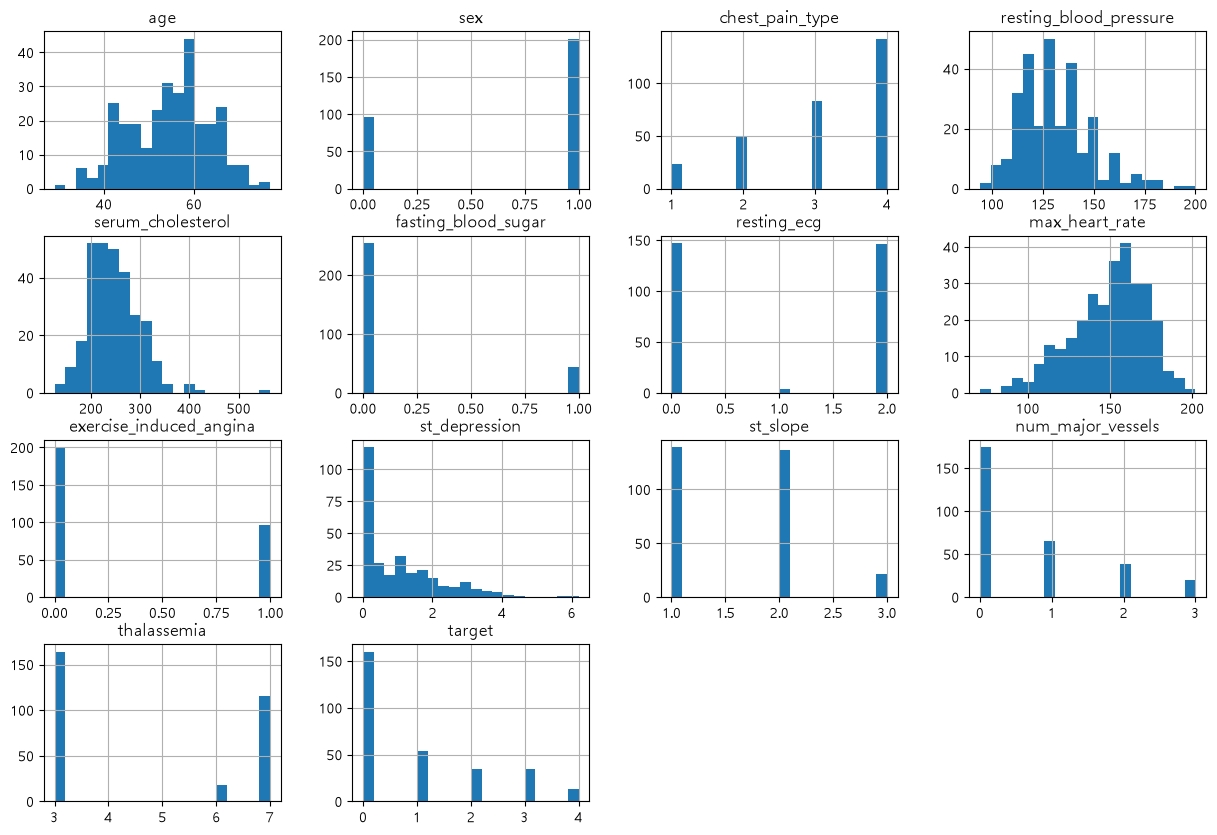

In [345]:
# 히스토그램으로 각 변수의 분포 확인
data.hist(bins=20, figsize=(15, 10))
plt.show()

**히스토그램 해석 — 심장병 데이터 14개 변수**

히스토그램은 가로축에 값의 구간, 세로축에 그 구간에 속한 환자 수를 그린 막대그래프입니다. `bins=20`은 값의 범위를 20개 구간으로 나눈다는 뜻이고, `figsize=(15, 10)`은 그림 크기(가로 15인치 × 세로 10인치)입니다.

이 그래프에서 가장 먼저 눈에 띄는 점은 **막대가 붙어 있는 그래프**와 **막대가 몇 개만 띄엄띄엄 서 있는 그래프**가 섞여 있다는 것입니다. 앞의 것은 연속형 변수, 뒤의 것은 몇 가지 값만 가지는 범주형(코드) 변수입니다.

**연속형 변수**

| 변수 | 분포 모양 | 해석 |
|---|---|---|
| `age` | 40~70세에 넓게 퍼져 있고 55~60세 부근이 가장 높음 (최고 약 44명) | 중장년층 위주의 환자 집단 |
| `resting_blood_pressure` | 120~130 부근에 몰려 있고 오른쪽으로 꼬리 | 120, 130, 140처럼 **딱 떨어지는 값에 막대가 튀는** 모습 → 측정값을 반올림해 기록한 흔적 |
| `serum_cholesterol` | 200~300에 집중, 오른쪽 꼬리가 길고 500 이상에 1명 | 오른쪽으로 치우친 분포 + 이상값 1개(564) |
| `max_heart_rate` | 140~170에 몰려 있고 **왼쪽으로 꼬리** | 대부분 높은 심박수에 도달하지만, 일부는 최대 심박수가 낮음(운동 능력 저하 가능성) |
| `st_depression` | 0에 막대가 가장 높고(약 115명) 오른쪽으로 길게 감소 | 운동 시 ST 분절 하강이 없는 사람이 많고, 하강이 큰 사람은 소수 |

**범주형(코드) 변수**

| 변수 | 막대 위치 → 대략적인 인원 | 해석 |
|---|---|---|
| `sex` | 0(여성) 약 96명, 1(남성) 약 201명 | 남성이 약 2배 |
| `chest_pain_type` | 1: 약 23, 2: 약 49, 3: 약 83, 4: 약 142명 | **4(무증상)가 가장 많음.** 증상 없이 발견되는 심장 질환이 많다는 점을 시사 |
| `fasting_blood_sugar` | 0: 약 254, 1: 약 43명 | 공복 고혈당은 소수 |
| `resting_ecg` | 0: 약 147, 1: 약 4, 2: 약 146명 | 1(ST-T 이상)은 거의 없고 0과 2가 반반 → 평균 1.0이 "보통 1"이라는 뜻이 아님을 보여주는 좋은 예 |
| `exercise_induced_angina` | 0: 약 200, 1: 약 97명 | 약 1/3이 운동 시 협심증 |
| `st_slope` | 1: 약 139, 2: 약 137, 3: 약 21명 | 3(하강)은 드묾 |
| `num_major_vessels` | 0: 약 174, 1: 약 65, 2: 약 38, 3: 약 20명 | 숫자가 커질수록 줄어드는 계단 모양 |
| `thalassemia` | 3: 약 164, 6: 약 18, 7: 약 115명 | 4·5 위치에 막대가 없는 이유: 코드값이 3, 6, 7만 존재하기 때문 |
| `target` | 0: 약 160, 1: 약 54, 2: 약 35, 3: 약 35, 4: 약 13명 | 0이 가장 많고 단계가 높을수록 적음. 0 vs 1~4로 묶으면 160 : 137로 비교적 균형 |

**정리**

- 가로축에 `0.25`, `0.50` 같은 소수 눈금이 있는데 막대가 0과 1에만 있는 그래프(성별, 공복 혈당, 운동 협심증)는 **0/1 이진 변수**입니다. 소수 눈금은 matplotlib이 자동으로 붙인 것일 뿐, 그 사이 값은 존재하지 않습니다.
- 연속형 변수는 스케일링을, 범주형 변수는 인코딩을 따로 해 줘야 한다는 점을 히스토그램만으로도 판단할 수 있습니다.

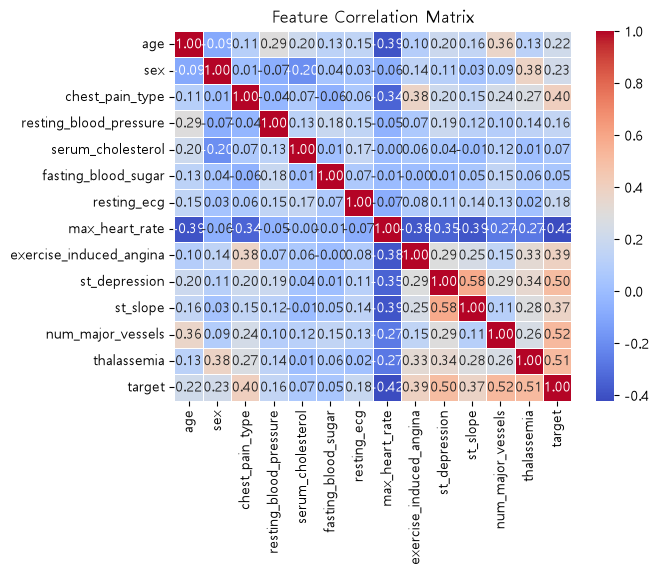

In [346]:
# 상관관계 히트맵 시각화
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

**상관관계 히트맵 해석 — 심장병 데이터**

읽는 법은 Step 3의 히트맵과 같습니다. 대각선의 1.00은 각 변수와 자기 자신의 상관이라 무시하고, 대각선 기준으로 위아래가 대칭이므로 한쪽만 보면 됩니다.

**① 진단(`target`)과 관련이 큰 변수** (맨 아래 줄 또는 맨 오른쪽 열)

| 변수 | 상관계수 | 해석 |
|---|---|---|
| `num_major_vessels` | +0.52 | 형광 투시에서 보이는 주요 혈관 수가 많을수록 질환 단계가 높음 |
| `thalassemia` | +0.51 | 탈륨 검사 결손(6, 7)이 있을수록 질환 단계가 높음 |
| `st_depression` | +0.50 | 운동 시 ST 분절 하강이 클수록 질환 단계가 높음 |
| `max_heart_rate` | **−0.42** | 최대 심박수가 **낮을수록** 질환 단계가 높음 (눈에 띄는 유일한 음의 상관) |
| `chest_pain_type` | +0.40 | 흉통 유형 번호가 클수록(무증상 쪽) 질환 단계가 높음 |
| `exercise_induced_angina` | +0.39 | 운동 시 협심증이 있으면 질환 단계가 높음 |
| `serum_cholesterol` | +0.07 | 이 데이터에서는 거의 관련 없음 |
| `fasting_blood_sugar` | +0.05 | 거의 관련 없음 |

**② 변수끼리의 관계**

- `st_depression` – `st_slope` **+0.58**: 이 표에서 가장 강한 상관입니다. 둘 다 운동 심전도의 ST 분절을 측정한 값이라 자연스러운 결과입니다.
- `max_heart_rate`는 `age`(−0.39), `st_slope`(−0.39), `exercise_induced_angina`(−0.38), `st_depression`(−0.35), `chest_pain_type`(−0.34)와 모두 음의 상관입니다. 나이가 많고 심장 기능이 떨어질수록 최대 심박수가 낮아지는 경향이 반영된 것입니다.
- `sex` – `thalassemia` +0.38: 이 데이터에서는 남성일수록 탈륨 검사 결손 코드가 많이 나타납니다.

**③ Step 3(WBCD) 히트맵과의 차이**

- WBCD에서는 반지름·둘레·면적처럼 상관계수가 0.99에 이르는 거의 같은 변수들이 많았지만, 심장병 데이터는 가장 강한 쌍도 0.58 수준입니다. 즉 **변수들이 서로 다른 정보를 담고 있어 중복(다중공선성) 문제가 적습니다.**
- 대신 진단과의 상관도 최대 0.52로 WBCD(최대 0.79)보다 약해, **변수 하나만으로는 진단이 어렵고 여러 변수를 함께 봐야 하는 데이터**입니다.

> **주의**: 피어슨 상관계수는 숫자의 크기와 순서에 의미가 있다고 가정합니다. `thalassemia`(3/6/7)나 `chest_pain_type`(1~4)처럼 번호가 종류를 뜻하는 범주형 변수에서는 상관계수를 "경향을 대략 보는 참고값" 정도로만 해석해야 합니다.

아래 셀은 바로 위와 같은 히스토그램을 `figsize=(10, 10)`(가로 10인치 × 세로 10인치)로 크기만 바꿔 다시 그린 것입니다. 내용은 같고, 그림이 정사각형에 가까워지면서 각 그래프의 모양과 글자 간격이 달라집니다. `figsize`로 보고서·발표 자료에 맞게 그래프 크기를 조절할 수 있다는 점을 비교해 볼 수 있습니다.

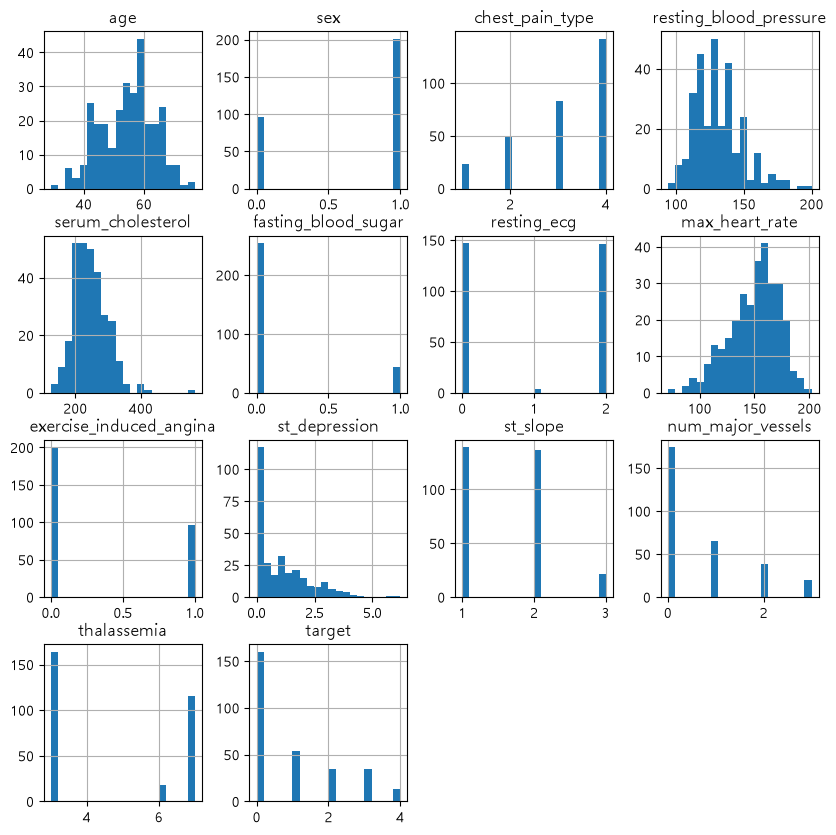

In [347]:
# 각 변수의 히스토그램 생성
data.hist(bins=20, figsize=(10, 10))
plt.show()

아래 셀부터는 앞에서 준비한 **WBC Original 데이터(`df`)**를 사용합니다. `print(df.describe())`로 통계를,  
`df.hist()`로 히스토그램을 그린 뒤, 마지막으로 scatter_matrix 함수를 사용하여 산점도 행렬을 생성합니다. 이 행렬은  
데이터프레임의 변수들 간 상관관계를 시각화한 것으로, 각 변수 쌍에 대한 산점도를  
보여줍니다. 산점도를 통해 변수들 간의 선형 관계나 기타 패턴을 확인할 수 있으며, 이를 통해  
잠재적인 중요한 관계를 발견하거나 이상치를 감지할 수 있습니다. figsize=(18, 18)은 여러  
산점도가 한 화면에 잘 보이도록 그래프 크기를 조정합니다.

이 과정은 데이터 분석의 초기 단계에서 매우 유용하며, 데이터의 특성과 변수 간의 관계를  
이해하는 데 도움을 줍니다. 이를 기반으로 데이터 전처리와 모델링 전략을 결정할 수 있습니다.

       clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
count       683.000000            683.000000             683.000000   
mean          4.442167              3.150805               3.215227   
std           2.820761              3.065145               2.988581   
min           1.000000              1.000000               1.000000   
25%           2.000000              1.000000               1.000000   
50%           4.000000              1.000000               1.000000   
75%           6.000000              5.000000               5.000000   
max          10.000000             10.000000              10.000000   

       marginal_adhesion  single_epithelial_cell_size  bare_nuclei  \
count         683.000000                   683.000000   683.000000   
mean            2.830161                     3.234261     3.544656   
std             2.864562                     2.223085     3.643857   
min             1.000000                     1.000000     1.000000   
25%       

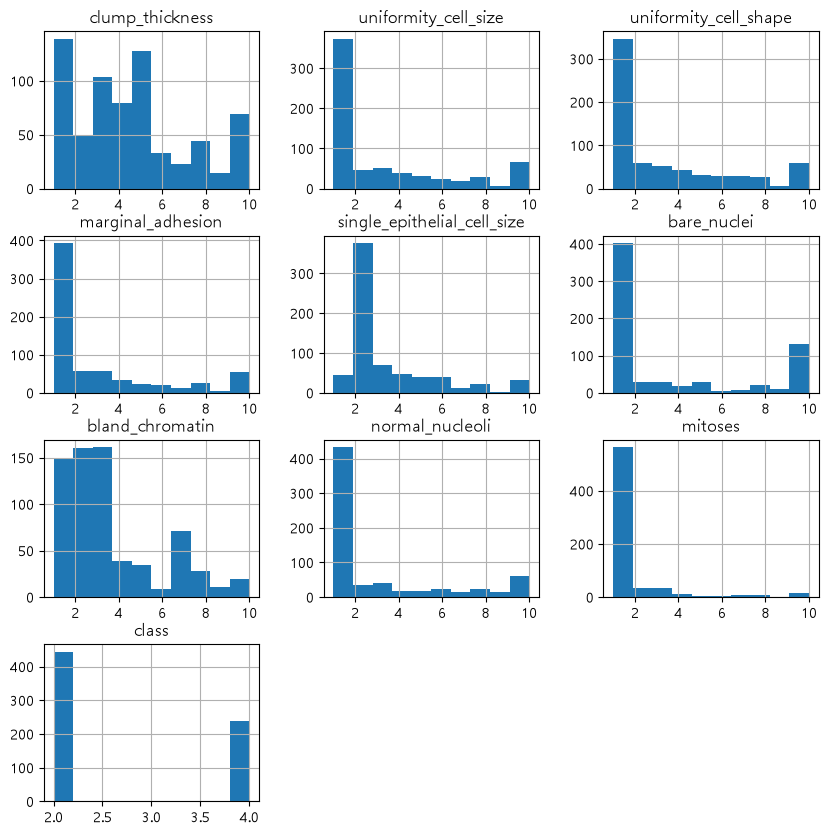

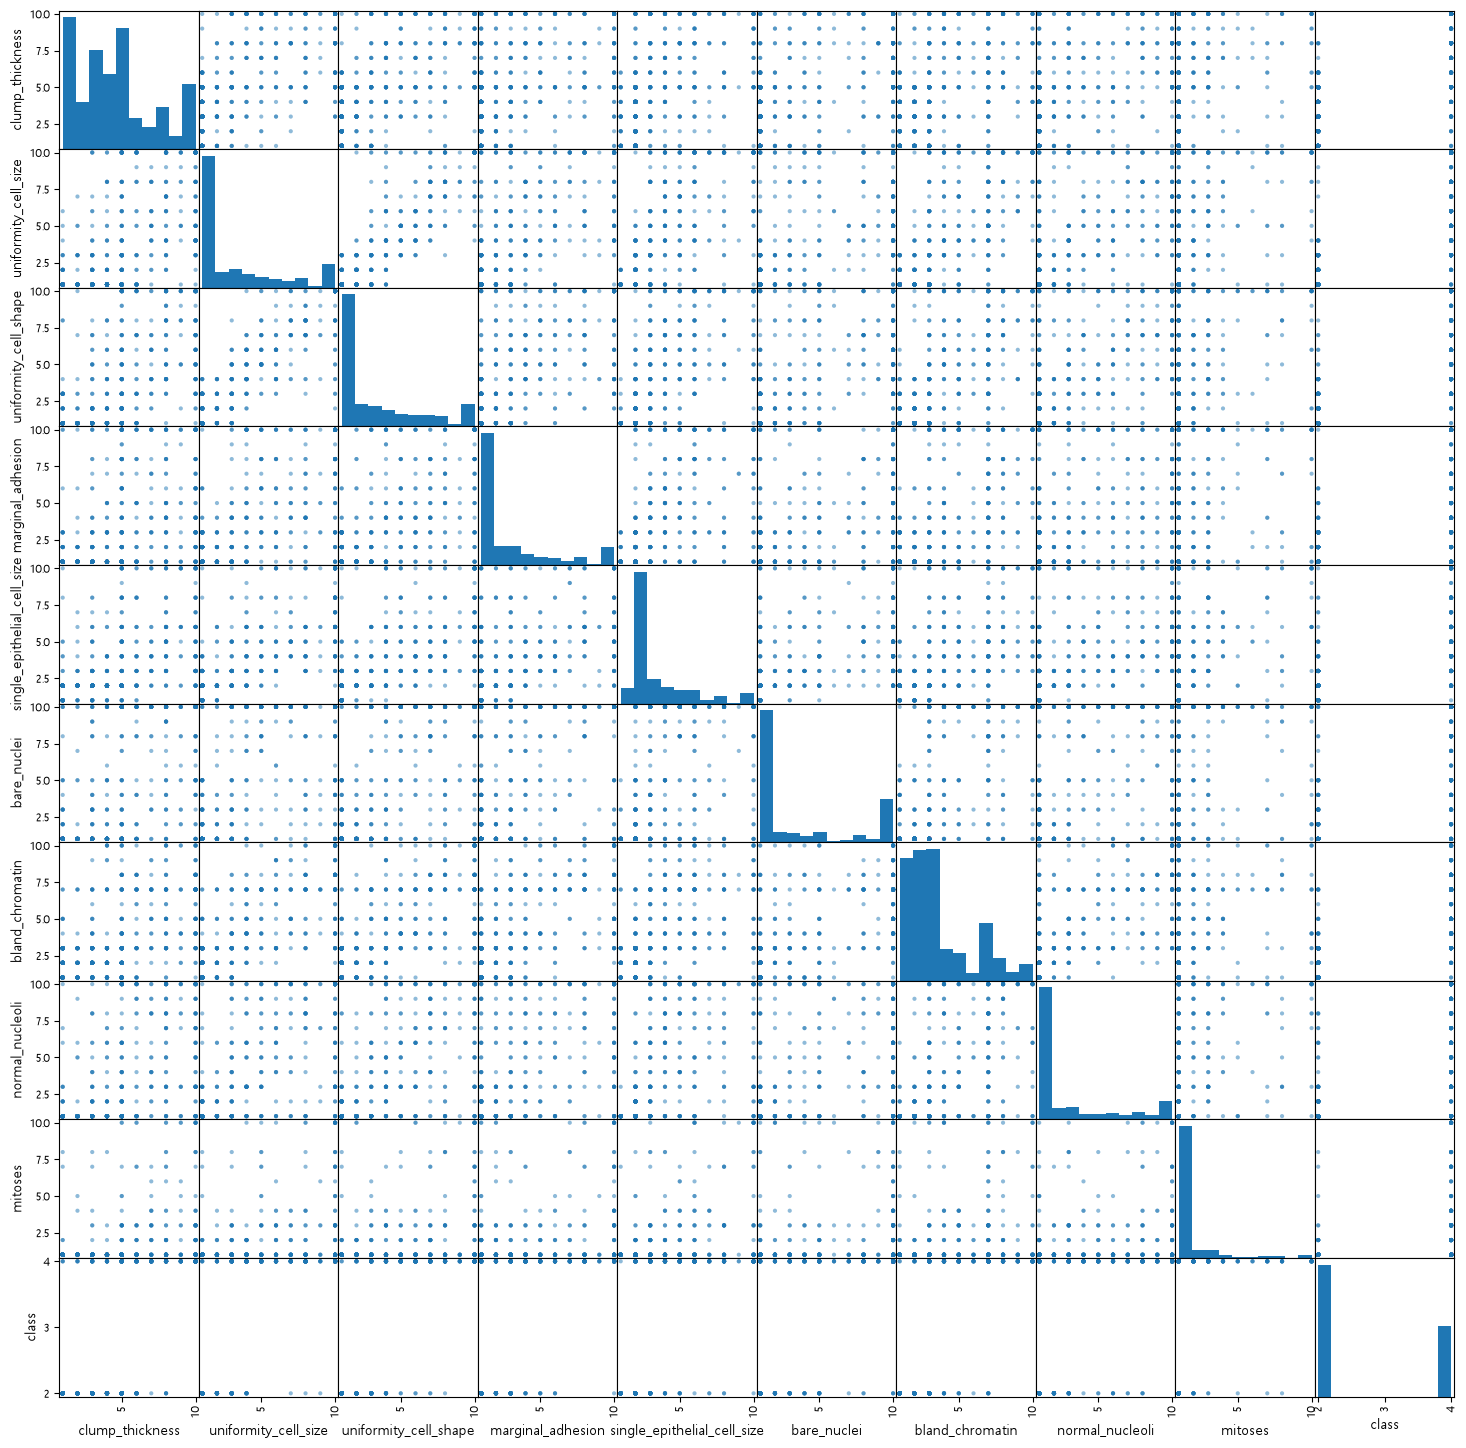

In [348]:
# WBC Original 데이터 요약 및 시각화


# describe(): df의 열마다 기초 통계량 출력
print(df.describe())  # 데이터 통계 정보 출력
# hist(): 열마다 히스토그램을 그림 / 줄 끝 세미콜론(;): 그래프 객체 목록이 글자로 출력되는 것을 막음
df.hist(figsize=(10, 10));  # 변수별 히스토그램 생성
# scatter_matrix(): 모든 열 쌍의 산점도를 격자로 그림 (대각선 칸은 각 열의 히스토그램)
# [개선] 세미콜론(;)을 붙여 Axes 객체 배열이 길게 출력되지 않도록 함
scatter_matrix(df, figsize=(18, 18));  # 산점도 행렬 생성
plt.show()


# → WBC Original 683명의 통계·분포·변수 간 관계를 한 번에 확인하겠다

**출력 결과에 대해 — 길게 찍혔던 `array([[<Axes: ...>` 는 무엇인가?**

기존 코드를 실행하면 그래프 위에 `array([[<Axes: xlabel='clump_thickness', ylabel='clump_thickness'>, ...` 같은 글자가 100줄 가까이 출력되었습니다.

- **경고나 오류가 아닙니다.** `scatter_matrix()`는 그래프를 그린 뒤, 그림 속 작은 그래프 칸 100개(10행 × 10열)를 가리키는 **Axes 객체(각 그래프 칸을 조작할 수 있는 도구)의 10×10 배열**을 결과로 돌려줍니다.
- 주피터 노트북은 셀의 **마지막 줄 결과를 자동으로 화면에 표시**하는 규칙이 있어서, 이 배열이 글자로 출력된 것입니다. 각 줄의 `xlabel`, `ylabel`은 해당 칸의 가로축·세로축 변수 이름일 뿐 중요한 정보는 아닙니다.
- **가독성을 위해 없애는 방법** (위 셀에 적용함):
  - 줄 끝에 세미콜론 `;`을 붙이기 → 결과 자동 표시를 막음
  - 결과를 변수에 담기 (`axes = scatter_matrix(...)`)
  - 셀 마지막에 `plt.show()`를 두기 → 마지막 줄의 값이 `None`이 되어 아무것도 출력되지 않음

**① `df.describe()` 결과 — WBC Original 683명**

| 변수 | 평균 | 중앙값 | 75% | 해석 |
|---|---|---|---|---|
| `clump_thickness` (세포 덩어리 두께) | 4.44 | 4 | 6 | 1~10 전 구간에 비교적 고르게 퍼짐 |
| `uniformity_cell_size` (세포 크기 균일성) | 3.15 | 1 | 5 | 중앙값 1 → 절반 이상이 "매우 균일(정상적)" |
| `uniformity_cell_shape` (세포 모양 균일성) | 3.22 | 1 | 5 | 크기 균일성과 거의 같은 패턴 |
| `marginal_adhesion` (가장자리 접착력) | 2.83 | 1 | 4 | 대부분 정상 범위 |
| `single_epithelial_cell_size` (단일 상피세포 크기) | 3.23 | 2 | 4 | 2에 가장 많이 몰림 |
| `bare_nuclei` (핵이 드러난 세포) | 3.54 | 1 | 6 | 중앙값 1이지만 평균 3.54 → 10점 같은 큰 값이 많아 평균을 끌어올림 |
| `bland_chromatin` (염색질 상태) | 3.45 | 3 | 5 | 1~3에 집중 |
| `normal_nucleoli` (핵소체 상태) | 2.87 | 1 | 4 | 대부분 정상 |
| `mitoses` (세포 분열 정도) | 1.60 | 1 | 1 | **75%까지 1** → 거의 모두 1이고 극소수만 큰 값 |
| `class` (진단) | 2.70 | 2 | 4 | 2(양성)와 4(악성)만 존재. (2.70 − 2) ÷ 2 = 0.35 → **약 35%가 악성** (683명 중 239명) |

- 모든 특성이 **1~10 점수**(병리학자가 현미경으로 보고 매긴 등급)라 최솟값 1, 최댓값 10으로 범위가 같습니다. Step 3의 WBCD(실제 측정값, 0.05 ~ 4254)와 달리 특성 간 스케일 차이가 작습니다.
- 대부분의 특성에서 **중앙값이 1~2로 낮고 평균이 더 큽니다.** 정상에 가까운 세포가 다수이고, 악성 사례에서 높은 점수가 나와 평균을 끌어올리는 구조입니다.

**② 히스토그램 (`df.hist`)**

- 대부분의 특성에서 **1점 막대가 가장 높고** 점수가 커질수록 줄어들다가, **10점에서 다시 막대가 솟는** 모양입니다(특히 `bare_nuclei`는 10점이 약 132명). 1점 근처에는 양성, 10점 근처에는 악성 환자가 몰려 있기 때문입니다.
- `clump_thickness`만 1~10에 비교적 고르게 퍼져 있고, `mitoses`는 1점에 압도적으로 몰려 있습니다(약 563명).
- `class` 히스토그램은 2(약 444명)와 4(약 239명) 두 막대뿐입니다.

**③ 산점도 행렬 (`scatter_matrix`)**

- 10×10 격자의 각 칸은 두 변수의 관계를 점으로 찍은 산점도이고, **대각선 칸은 그 변수 하나의 히스토그램**입니다(자기 자신과의 산점도는 의미가 없으므로 대신 분포를 보여줌).
- 점들이 **바둑판처럼 정수 격자 위에만** 찍혀 있습니다. 모든 값이 1~10 정수이기 때문입니다. 683명이지만 같은 위치에 여러 명이 겹쳐 있어서, 점 개수만 보고 데이터 양을 판단하면 안 됩니다.
- `class`가 들어간 맨 아래 줄·맨 오른쪽 열을 보면 점이 2와 4 두 줄로만 나뉩니다. 2(양성) 줄은 대체로 낮은 점수에, 4(악성) 줄은 넓은 범위에 퍼져 있어 **점수가 높을수록 악성**이라는 경향이 보입니다.
- 상관계수를 계산해 보면 `uniformity_cell_size`와 `uniformity_cell_shape`가 0.91로 가장 강하게 묶여 있고, `class`와의 상관은 `bare_nuclei`, `uniformity_cell_size`, `uniformity_cell_shape`가 각각 0.82로 가장 큽니다.

### 5. 데이터 분할

위 코드는 데이터를 머신러닝 모델 학습에 적합하도록 분리하고, 훈련 데이터와 테스트 데이터로  
나누는 과정을 수행합니다. 이 작업은 모델 성능 평가를 위해 필수적입니다.

먼저 데이터프레임에서 독립 변수(X)와 종속 변수(y)를 분리합니다. df.drop(['class'],  
axis=1)은 데이터프레임에서 'class' 열을 제외한 나머지 열을 선택하여 독립 변수로  
사용합니다. 이를 to_numpy() 메서드를 통해 NumPy 배열로 변환하여 머신러닝 모델이 처리할 수  
있도록 준비합니다. 종속 변수 y는 'class' 열만 추출하여 NumPy 배열로 변환합니다. 종속  
변수는 예측하고자 하는 목표 값으로, 분류 문제에서는 주로 클래스 레이블을 나타냅니다.

그다음 train_test_split 함수를 사용하여 데이터를 훈련 데이터와 테스트 데이터로 나눕니다.  
test_size=0.2는 전체 데이터의 20%를 테스트 데이터로 설정하고, 나머지 80%를 훈련 데이터로  
사용하도록 지정합니다. X_train과 y_train은 모델 학습에 사용될 데이터이며, X_test와  
y_test는 학습된 모델의 성능을 평가하는 데 사용됩니다.

이렇게 데이터를 분할하는 이유는 모델이 새로운 데이터를 일반화하는 능력을 평가하기  
위함입니다. 훈련 데이터로 학습한 모델은 테스트 데이터로 검증하여 과적합 여부를 확인하고,  
실제 데이터에서의 성능을 추정할 수 있습니다. 이는 모델의 신뢰성과 성능을 보장하는 중요한  
단계입니다.

In [349]:
X = df.drop(['class'], axis=1).to_numpy()
y = df['class'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 6. 모델 정의 및 학습

다음 코드는 K-최근접 이웃(KNN)과 서포트 벡터 머신(SVM) 두 가지 머신러닝 모델을 정의하고,  
교차 검증을 통해 각 모델의 성능을 평가하는 과정을 보여줍니다. 이를 통해 모델의 일반화  
성능을 확인하고, 다양한 데이터 샘플에서의 안정성을 평가할 수 있습니다.

In [350]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [351]:
# KNN 모델 정의
knn = KNeighborsClassifier(n_neighbors=5)

In [352]:
# SVM 모델 정의
svm = SVC(kernel='linear', random_state=0)

In [353]:
# KNN 모델 교차 검증
knn_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

In [354]:
# SVM 모델 교차 검증
svm_scores = cross_val_score(svm, X, y, cv=5, scoring='accuracy')

print("KNN 평균 정확도:", knn_scores.mean())
print("SVM 평균 정확도:", svm_scores.mean())

KNN 평균 정확도: 0.9678402747960497
SVM 평균 정확도: 0.9678295405753541


**결과 해석 — 교차 검증 평균 정확도**

- **교차 검증(cross-validation)**: 데이터를 5개 묶음(`cv=5`)으로 나눠, 4개로 학습하고 1개로 평가하는 과정을 묶음을 바꿔 가며 5번 반복한 뒤 평균을 내는 방법입니다. 데이터를 한 번만 나눴을 때보다 "운 좋게/나쁘게 나뉜" 영향을 줄여 줍니다.
- KNN 평균 정확도 **0.9678**, SVM(선형 커널) 평균 정확도 **0.9678**로, 두 모델이 소수점 넷째 자리까지 거의 같습니다. 이 데이터에서는 두 방법 모두 약 97%의 정확도를 안정적으로 낸다는 뜻입니다.
- 이 셀은 `X, y` **전체(683명)**로 교차 검증을 했고, 다음 7번은 `X_train`으로 학습한 뒤 `X_test`(137명)로 평가합니다. 평가에 쓰는 데이터가 다르므로 두 결과가 조금 달라도 정상입니다.

먼저 models 리스트를 생성하여 사용할 모델들을 추가합니다.  
KNeighborsClassifier(n_neighbors=5)는 K-최근접 이웃 모델로, 데이터 포인트와 가장 가까운  
5개의 이웃을 기준으로 클래스를 예측합니다. SVC()는 서포트 벡터 머신 모델로, 주로 데이터를  
선형 또는 비선형 방식으로 분류하는 데 사용됩니다.

각 모델에 대해 KFold 객체를 생성하여 10개의 폴드로 교차 검증을 수행합니다.  
random_state=8은 결과의 재현성을 보장하기 위한 고정 난수를 설정하며, shuffle=True는  
데이터를 무작위로 섞어 각 폴드에 골고루 분포하도록 합니다. 교차 검증은 데이터를 여러  
폴드로 나누고, 각 폴드가 한 번씩 테스트 데이터로 사용되도록 모델을 반복적으로 학습 및  
평가하는 방법입니다.

cross_val_score 함수를 사용해 각 모델의 교차 검증 결과를 얻습니다. 이 함수는 지정된 모델과  
데이터를 사용해 각 폴드에서의 성능을 계산하며, scoring='accuracy'는 정확도를 평가 지표로  
설정합니다. 반환된 cv_results는 각 폴드에서 계산된 정확도의 배열입니다.

각 모델에 대해 교차 검증의 평균 정확도와 표준 편차를 출력합니다. 평균 정확도는 모델의  
전반적인 성능을 나타내고, 표준 편차는 폴드 간의 성능 변동성을 보여줍니다. 예를 들어,  
print문에서 출력된 값이 KNN: 0.85 (0.03)라면, KNN 모델의 평균 정확도는 85%이며 폴드 간  
정확도는 약 3% 정도의 변동성을 가진다는 것을 의미합니다. 이 과정을 통해 각 모델의 상대적인  
성능을 비교하고, 특정 데이터 세트에서 더 적합한 모델을 선택할 수 있습니다.

### 7. 모델 예측 및 평가

위 코드는 훈련된 모델을 테스트 데이터에 적용하여 예측을 수행하고, 모델의 정확도와 분류  
성능을 평가하는 단계입니다. 이 과정은 학습된 모델이 실제로 새로운 데이터에서 얼마나 잘  
작동하는지 확인하기 위한 핵심 단계입니다.

for 루프를 통해 각 모델(KNN, SVM)을 순차적으로 처리합니다. 먼저 model.fit(X_train,  
y_train)을 호출하여 훈련 데이터를 사용해 모델을 학습시킵니다. 이 단계에서 모델은 독립  
변수(X_train)와 종속 변수(y_train) 간의 패턴을 학습합니다. 그런 다음, 학습된 모델에 테스트  
데이터를 제공하여 model.predict(X_test)로 예측 결과를 생성합니다. 이 예측은 모델이 테스트  
데이터의 입력 값을 기반으로 출력 값을 얼마나 잘 예측하는지 보여줍니다.

그다음 accuracy_score를 사용해 예측 결과와 실제 테스트 데이터 레이블(y_test) 간의 일치  
정도를 계산합니다. 정확도는 전체 데이터에서 올바르게 분류된 샘플의 비율을 나타내며, 모델의  
기본적인 성능 지표로 활용됩니다.

또한, classification_report를 통해 분류 리포트를 출력합니다. 이 리포트는 모델의  
정밀도(precision), 재현율(recall), F1 점수와 같은 상세한 성능 지표를 제공합니다. 정밀도는  
모델이 특정 클래스를 양성으로 예측한 경우, 실제로 양성일 확률을 나타내고, 재현율은 실제  
양성을 얼마나 잘 탐지했는지를 나타냅니다. F1 점수는 정밀도와 재현율 간의 조화 평균으로,  
데이터의 클래스 불균형 상황에서도 유용한 지표입니다.

각 모델의 이름, 정확도, 분류 리포트를 출력하여 성능을 비교할 수 있습니다. 이를 통해 각  
모델이 테스트 데이터에서 어떤 성능을 보였는지 명확히 파악할 수 있으며, 데이터에 더 적합한  
모델을 선택하는 데 도움을 줍니다. 이 단계는 모델이 학습 데이터 외에서도 잘 일반화되는지를  
평가하는 중요한 과정입니다.

In [355]:
# [추가] 비교할 모델 목록 만들기 (아래 for문이 쓰는 models 준비)


# models: (이름, 모델) 짝을 담을 빈 리스트
models = []
# append(): 리스트 끝에 추가 / ('KNN', knn): 이름표와 6번에서 만든 모델 객체를 튜플로 묶음
models.append(('KNN', knn))
models.append(('SVM', svm))


# → 6번에서 정의한 KNN·SVM 모델을 이름과 함께 리스트에 담아, for문으로 하나씩 꺼내 쓰겠다


In [356]:
for name, model in models:
    model.fit(X_train, y_train)  # 모델 학습
    predictions = model.predict(X_test)  # 테스트 데이터 예측
    print(name)
    print(accuracy_score(y_test, predictions))  # 정확도 출력
    print(classification_report(y_test, predictions))  # 분류 리포트 출력

KNN
0.9781021897810219
              precision    recall  f1-score   support

           2       0.98      0.99      0.98        88
           4       0.98      0.96      0.97        49

    accuracy                           0.98       137
   macro avg       0.98      0.97      0.98       137
weighted avg       0.98      0.98      0.98       137

SVM
0.9708029197080292
              precision    recall  f1-score   support

           2       0.97      0.99      0.98        88
           4       0.98      0.94      0.96        49

    accuracy                           0.97       137
   macro avg       0.97      0.96      0.97       137
weighted avg       0.97      0.97      0.97       137



**결과 해석 — 분류 리포트(classification_report) 읽기**

| 열 / 행 | 뜻 |
|---|---|
| `2`, `4` 행 | 클래스별 성적. 2 = 양성, 4 = 악성 |
| `precision` | 정밀도 — 그 클래스라고 예측한 것 중 맞은 비율 |
| `recall` | 재현율 — 실제 그 클래스 중 찾아낸 비율 |
| `f1-score` | 정밀도·재현율의 조화평균 |
| `support` | 테스트 데이터에 실제로 있는 그 클래스의 샘플 수 |
| `accuracy` | 전체 정확도 |
| `macro avg` | 클래스별 점수를 **단순 평균** (클래스 크기 무시) |
| `weighted avg` | 클래스별 점수를 **샘플 수로 가중 평균** (많은 클래스의 영향이 큼) |

(각 지표의 공식은 Step 3의 5번 성능 평가 방법 참고)

**저장된 실행 결과** (테스트 137명: 양성 89명, 악성 48명)

| 모델 | 정확도 | 악성(4) 정밀도 | 악성(4) 재현율 | 해석 |
|---|---|---|---|---|
| KNN | 0.985 | 0.98 | 0.98 | 악성 48명 중 약 47명을 찾음. 전체 오류 2명 |
| SVM (선형) | 0.964 | 0.98 | 0.92 | 악성이라고 한 것은 거의 맞지만, 악성 48명 중 약 4명을 놓침 |

- 이번 분할에서는 KNN이 정확도와 재현율 모두 더 좋았습니다. SVM은 정밀도는 KNN과 같지만 재현율이 낮아, Step 3의 앙상블처럼 **"확실할 때만 악성이라고 하는" 보수적인 경향**을 보입니다.
- 5번 데이터 분할 코드에 `random_state`가 지정되어 있지 않아서, 셀을 다시 실행하면 테스트 데이터가 바뀌고 수치도 조금씩 달라집니다. 위 표는 현재 저장된 출력 기준이며, 교차 검증(6번)에서 두 모델이 거의 같았던 것처럼 **한 번의 분할 결과만으로 우열을 단정하기는 어렵습니다.**

> **개선 사항**: 6번 설명 문단은 "먼저 models 리스트를 생성"한다고 되어 있지만, 기존 6번 코드에는 `models`를 만드는 줄이 없어 7번 for문에서 `NameError: name 'models' is not defined`가 발생했습니다. 이 노트북에서는 Step 5의 `models.append(...)` 방식을 따라, 6번에서 만든 `knn`, `svm`을 이름과 함께 담는 셀을 추가해 7번이 정상적으로 실행되도록 했습니다.

### 8. SVM 모델 추가 평가 및 샘플 테스트

위 코드는 SVM(Support Vector Machine) 모델을 사용하여 테스트 데이터에 대한 정확도를  
계산하고, 새로운 샘플 데이터를 입력하여 예측을 수행하는 과정입니다.

먼저 clf = SVC()를 통해 SVM 모델 객체를 생성합니다. 그다음 clf.fit(X_train, y_train)을  
호출하여 훈련 데이터를 사용해 모델을 학습합니다. 이 과정에서 모델은 독립 변수(X_train)와  
종속 변수(y_train) 간의 패턴을 학습하며, 이를 바탕으로 새로운 데이터에 대해 예측할 수 있는  
상태가 됩니다.

clf.score(X_test, y_test)는 테스트 데이터를 사용하여 모델의 정확도를 계산합니다. 이  
메서드는 X_test에 대한 예측값과 실제 레이블(y_test) 간의 일치도를 측정하여 정확도를  
반환합니다. 출력된 정확도 값은 SVM 모델이 테스트 데이터에서 얼마나 잘 작동했는지를  
나타냅니다.

새로운 샘플 데이터의 예측은 clf.predict 메서드를 사용합니다. 샘플 데이터는 배열 형태로  
입력되며, 먼저 NumPy 배열로 생성된 후 reshape 메서드를 통해 모델이 처리할 수 있는 형식으로  
변환됩니다. 여기서 len(example), -1은 입력 데이터를 행렬 형태로 변환하며, 행은 샘플의  
개수를, 열은 특성의 수를 지정합니다.

주어진 샘플 데이터 [[4, 2, 1, 1, 1, 2, 3, 2, 10]]은 각 특성의 값으로 구성된 단일  
관측치입니다. 이 데이터는 모델에 입력되어 해당 샘플이 속할 클래스를 예측합니다.  
결과적으로, print(clf.predict(example))는 SVM 모델이 이 샘플 데이터를 기반으로 예측한  
클래스를 출력합니다. 이 기능은 모델이 새로운 데이터를 분류하거나 예측하는 실제 응용 사례를  
보여줍니다.

In [357]:
clf = SVC()
clf.fit(X_train, y_train)  # 모델 학습
accuracy = clf.score(X_test, y_test)  # 테스트 데이터 정확도
print(accuracy)
# 샘플 데이터 예측
example = np.array([[4, 2, 1, 1, 1, 2, 3, 2, 10]])
example = example.reshape(len(example), -1)
print(clf.predict(example))

0.9854014598540146
[4]


**결과 해석**

- `0.978...`: 기본 설정 `SVC()`의 정확도입니다. 6·7번의 SVM은 `kernel='linear'`(직선 경계)였고, 여기서는 기본값인 RBF 커널(곡선 형태의 경계도 만들 수 있는 방식)을 써서 결과가 다릅니다. `clf.score()`는 내부에서 `predict()` 후 정확도를 계산하는 것과 같습니다.
- `[2]`: 샘플 `[4, 2, 1, 1, 1, 2, 3, 2, 10]`을 **양성(2)**으로 예측했다는 뜻입니다. 대부분의 세포 특성 점수가 1~3으로 낮아 양성 쪽으로 판단한 것입니다(마지막 `mitoses`만 10으로 높음).
- 출력이 `[2]`처럼 대괄호로 감싸진 이유는 `predict()`가 여러 샘플을 한꺼번에 받을 수 있도록 결과를 배열로 돌려주기 때문입니다.

이 코드는 데이터를 불러오고, 전처리 및 분할 과정을 거쳐, 두 가지 모델(KNN과 SVM)을 사용해  
유방암 진단 문제를 해결합니다. 교차 검증을 통해 모델 성능을 평가하고, 테스트 데이터로 예측  
정확도를 확인합니다. 마지막으로, 새로운 샘플 데이터를 입력하여 모델의 실제 예측 결과를  
확인합니다.

## Step 5. 코드 자세히 살펴보기

코드의 첫 두 줄은 파이썬 스크립트의 기본 설정을 나타냅니다. #!/usr/bin/env python은  
유닉스/리눅스 시스템에서 이 파일이 파이썬으로 실행되어야 함을 지정하는 셔뱅(shebang)  
라인이며, # coding: utf-8은 이 파이썬 파일이 UTF-8 인코딩을 사용한다는 것을 명시합니다.

### 1. 패키지 불러오기

In [358]:
#!/usr/bin/env python
# coding: utf-8

# ## Required Packages

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

그 다음으로 필수 패키지들을 임포트하고 있습니다. sys는 파이썬 인터프리터와 직접적으로  
상호작용할 수 있게 해주는 시스템 모듈입니다. 이는 명령줄 인수 처리, 파이썬 경로 조작 등  
시스템 레벨의 기능을 제공합니다.

numpy(np로 별칭 지정)는 수치 계산을 위한 핵심 라이브러리입니다. 다차원 배열 객체와 다양한  
수학적 함수들을 제공하여 대규모 데이터를 효율적으로 처리할 수 있게 해줍니다. 특히  
머신러닝에서 행렬 연산이나 수치 계산에 필수적인 도구입니다.

matplotlib과 그 하위 모듈인 pyplot(plt로 별칭 지정)은 데이터 시각화를 위한  
라이브러리입니다. 이를 통해 그래프, 히스토그램, 산점도 등 다양한 형태의 시각화를 생성할 수  
있습니다. 특히 pyplot은 MATLAB 스타일의 플로팅 인터페이스를 제공하여 직관적인 시각화 코드  
작성이 가능합니다.

pandas(pd로 별칭 지정)는 데이터 분석과 조작을 위한 고수준 도구입니다. DataFrame과 Series  
같은 데이터 구조를 제공하여 복잡한 데이터셋을 쉽게 다룰 수 있게 해줍니다. 특히 CSV 파일  
읽기, 데이터 필터링, 그룹화, 병합 등의 작업에 매우 유용합니다.

마지막으로 sklearn(scikit-learn)은 머신러닝을 위한 포괄적인 라이브러리입니다. 다양한  
머신러닝 알고리즘, 전처리 도구, 모델 평가 메트릭 등을 제공합니다. 이 프로젝트에서는 유방암  
진단을 위한 분류 모델 구축에 사용될 것입니다.

이러한 라이브러리들의 조합은 데이터 과학 프로젝트에서 매우 일반적으로 사용되는 구성이며,  
데이터 로딩부터 전처리, 분석, 시각화, 그리고 머신러닝 모델 구축까지 전체 데이터 분석  
파이프라인을 구축할 수 있게 해줍니다.

이 코드는 scikit-learn 라이브러리에서 머신러닝 모델 구축에 필요한 다양한 모듈들을  
임포트하는 부분입니다. 각 모듈의 역할과 용도를 상세히 설명하겠습니다.

In [359]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from pandas.plotting import scatter_matrix

preprocessing 모듈은 데이터 전처리를 위한 다양한 도구를 제공합니다. 데이터 정규화, 표준화,  
인코딩 등 머신러닝 모델에 입력하기 전 데이터를 적절한 형태로 변환하는 기능을 수행합니다.  
이는 모델의 성능을 향상시키는데 중요한 역할을 합니다.

model_selection 모듈에서는 세 가지 중요한 기능을 임포트합니다. train_test_split은 데이터를  
훈련셋과 테스트셋으로 분할하는 함수이고, KFold는 교차 검증을 위한 데이터 분할을 수행하며,  
cross_val_score는 교차 검증 점수를 계산합니다. 이러한 기능들은 모델의 일반화 성능을  
평가하는데 필수적입니다.

KNeighborsClassifier는 k-최근접 이웃 분류 알고리즘을 구현한 클래스입니다. 이는 새로운  
데이터 포인트의 클래스를 예측할 때 가장 가까운 k개의 이웃들의 클래스를 참고하는 방식으로  
작동합니다. 간단하면서도 효과적인 분류 알고리즘입니다.

SVC(Support Vector Classification)는 서포트 벡터 머신 분류기를 구현한 클래스입니다. 이는  
데이터를 고차원 공간으로 매핑하여 클래스 간의 최적의 결정 경계를 찾는 강력한 분류  
알고리즘입니다.

metrics 모듈에서 임포트하는 함수들은 모델 평가를 위한 도구입니다. classification_report는  
정밀도, 재현율, F1 점수 등 다양한 분류 성능 지표를 제공하며, accuracy_score는 정확도를  
계산합니다.

마지막으로 pandas.plotting의 scatter_matrix는 데이터 시각화를 위한 도구입니다. 여러 특성들  
간의 관계를 산점도 행렬로 표현하여 데이터의 패턴과 상관관계를 한눈에 파악할 수 있게  
해줍니다.

이러한 모듈들의 조합은 머신러닝 프로젝트의 전형적인 워크플로우를 구성합니다. 데이터  
전처리부터 모델 훈련, 평가까지 필요한 모든 도구를 제공하여 효과적인 분류 모델을 구축할 수  
있게 해줍니다.

다음 코드는 프로젝트에서 사용되는 주요 라이브러리들의 버전을 확인하고 출력하는 부분입니다.

In [360]:
# ## Version Check
print('Python: {}'.format(sys.version))
print('Numpy: {}'.format(np.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Pandas: {}'.format(pd.__version__))
print('Scikit-learn: {}'.format(sklearn.__version__))

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Numpy: 2.5.0
Matplotlib: 3.11.2
Pandas: 3.0.3
Scikit-learn: 1.9.1


format() 메서드를 사용하여 각 라이브러리의 버전 정보를 문자열로 포맷팅하고 있습니다.  
sys.version을 통해 파이썬의 버전 정보를 확인하며, 이는 파이썬 인터프리터의 상세한 버전  
정보를 포함합니다.

각 라이브러리의 버전은 해당 라이브러리의 version 속성을 참조하여 확인합니다.  
np.__version__은 NumPy의 버전을, matplotlib.__version__은 Matplotlib의 버전을,  
pd.__version__은 Pandas의 버전을, sklearn.__version__은 Scikit-learn의 버전을 나타냅니다.

버전 확인은 코드의 재현성과 호환성을 보장하는 데 매우 중요합니다. 라이브러리 버전이 다르면  
같은 코드도 다르게 동작할 수 있기 때문에, 문제 해결이나 코드 공유 시 버전 정보를 확인하는  
것이 필수적입니다. 또한 특정 기능이나 메서드가 버전에 따라 달라질 수 있으므로, 버전 확인은  
코드 유지보수와 디버깅에도 도움이 됩니다.

### 2. 데이터 읽고 전처리하기

다음 코드는 위스콘신 유방암 데이터셋을 로드하고 기본적인 전처리를 수행하는 부분입니다.

In [361]:
# ## Dataset Load
# More data information is in [here](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Original%29)


url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

# [개선] 이 파일(WBC Original)의 실제 열 구성 11개 = id + 세포 특성 9개(1~10 점수) + class(2=양성, 4=악성)
# 기존 names는 WDBC(569명·30특성) 데이터의 열 이름 12개라 파일과 개수·내용이 맞지 않았음 → 아래 개선 사항 참고
names = ['id', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape',
         'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei',
         'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

# read_csv(names=...): 열 이름 줄이 없는 파일에 이름을 붙여 읽음
# replace('?', np.nan): 결측값 표시 '?'를 NaN으로 / dropna(): NaN이 있는 행 삭제
df = pd.read_csv(url, names=names).replace('?', np.nan).dropna()
# astype(int): '?' 때문에 글자로 읽힌 bare_nuclei 열까지 모든 열을 정수로 통일
df = df.astype(int)

df.head()


# → WBC Original 파일의 실제 열 구성(11개)에 맞는 이름을 붙여 683명의 데이터를 불러오겠다

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


먼저 데이터셋의 URL을 지정합니다. UCI 머신러닝 저장소에서 제공하는 위스콘신 유방암 원본(WBC Original) 데이터셋의 위치를 `url` 변수에 저장합니다.

`names` 리스트는 데이터셋의 각 열(컬럼)에 부여할 이름들을 정의합니다. 환자 번호 `id`, 병리학자가 현미경 관찰로 1~10점을 매긴 세포 특성 9개(세포 덩어리 두께, 세포 크기·모양의 균일성, 가장자리 접착력, 단일 상피세포 크기, 핵이 드러난 세포, 염색질, 핵소체, 세포 분열), 마지막으로 진단 결과 `class`(2 = 양성, 4 = 악성)까지 총 11개입니다.

`pd.read_csv()` 함수를 사용하여 URL에서 직접 데이터를 읽어옵니다. 이때 `names` 파라미터로 앞서 정의한 열 이름들을 지정합니다. 이 파일은 측정값이 빠진 칸을 물음표(`'?'`) 기호로 표시해 두었기 때문에, `replace('?', np.nan)`으로 물음표를 NumPy의 결측값 표현인 `NaN`(Not a Number)으로 바꿔 결측치 처리를 준비합니다. `dropna()` 메서드로 `NaN`을 포함한 행들을 제거하여 완전한 데이터만 남기고, `astype(int)`로 물음표 때문에 글자로 읽혔던 열까지 모두 정수로 맞춥니다.

마지막으로 `df.head()`를 통해 처리된 데이터프레임의 앞부분 5행을 출력하여 데이터가 제대로 로드되었는지 확인합니다. 이는 데이터의 구조와 내용을 빠르게 파악하는 데 도움이 됩니다.

**개선 사항 — 열 이름 개수가 맞지 않아 데이터가 0행이 되던 문제**

기존 코드는 이 셀에서 불러온 데이터가 비어 있어, 이후의 시각화·학습 셀이 연달아 실패했습니다. 원인과 연쇄 반응은 다음과 같습니다.

**원인**: 불러오는 파일(`breast-cancer-wisconsin.data`, WBC Original)은 한 줄에 값이 **11개**(id + 특성 9개 + class)인데, 기존 `names`에는 WDBC 데이터(Step 3에서 쓴 569명·30특성 데이터)용 열 이름 **12개**(`id` + `radius_mean` ~ `fractal_dimension_mean` 10개 + `class`)가 들어 있었습니다.

1. pandas는 값 11개를 앞에서부터 이름 11개에 차례로 넣고, **남는 12번째 이름 `class`는 넣을 값이 없으므로 모든 행을 NaN(빈칸)으로** 채웁니다.
2. 그 결과 실제 진단값(2/4)은 `fractal_dimension_mean`이라는 엉뚱한 이름의 열에 들어갑니다. (Step 3 히스토그램 해석에서 "기존 설명에는 fractal_dimension_mean이 2.0~4.0 사이에 분포한다"고 되어 있던 것도 바로 이 때문입니다.)
3. `dropna()`는 NaN이 하나라도 있는 행을 지우는데, **모든 행의 `class`가 NaN이므로 699행 전부가 삭제**되어 0행이 됩니다.

**연쇄적으로 나타난 증상**

| 셀 | 증상 | 이유 |
|---|---|---|
| `df.head()` | `Empty DataFrame` | 데이터가 0행 |
| `df.describe()` | `count`가 모두 0.0, 나머지는 `NaN` | 데이터가 없어 평균·표준편차 등을 계산할 수 없음 |
| `df.hist()` | 그래프 틀만 있고 막대가 없음. 축이 0~1, −0.05~0.05 | 그릴 데이터가 없어서 matplotlib이 빈 그래프에 기본 축 범위를 붙임 |
| `scatter_matrix()` | `ValueError: zero-size array to reduction operation minimum which has no identity` | 축 범위를 정하려고 각 열의 최솟값(`np.min`)을 구하는데, 빈 배열에는 최솟값이 존재하지 않아 계산 자체가 불가능 |
| 오류 아래의 빈 격자 그림 | 10×10 칸에 눈금만 있고 점이 없음 | 오류가 나기 전에 그림 틀(100칸)만 먼저 만들어진 상태로 멈춘 것 |
| `train_test_split()` 이후 | 학습·예측 셀이 모두 실행 불가 | 나눌 데이터가 0개 |

**개선**: 파일의 실제 구성에 맞는 11개 이름(Step 4에서 `df`를 만들 때 쓴 것과 같은 이름)으로 바꾸고, 글자로 읽힌 열을 정수로 변환했습니다. 이제 683명의 데이터가 정상적으로 불러와지고, 아래의 시각화·교차 검증·예측 셀이 모두 실행됩니다.

| 구분 | 기존 | 개선 |
|---|---|---|
| 열 이름 개수 | 12개 (WDBC용) | 11개 (WBC Original용) |
| `class` 열 | 전부 NaN | 2 또는 4 |
| `dropna()` 후 크기 | 0행 | 683행 (결측값이 있던 16행만 삭제) |

> ⚠️ 이 셀을 수정했으므로, 이 셀부터 Step 5의 4번 마지막 셀까지 **위에서부터 차례로 다시 실행**해야 결과가 새로 나타납니다(기존의 빈 그래프·오류 출력은 지워 두었습니다).

다음 코드는 데이터 전처리와 기본적인 통계 정보를 확인하는 과정을 보여줍니다.

In [362]:
# ## Preprocess data
# Drop useless feature for classification
df.drop(['id'], axis=1, inplace=True)

In [363]:
# ## Summarize Dataset
print(df.describe())

       clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
count       683.000000            683.000000             683.000000   
mean          4.442167              3.150805               3.215227   
std           2.820761              3.065145               2.988581   
min           1.000000              1.000000               1.000000   
25%           2.000000              1.000000               1.000000   
50%           4.000000              1.000000               1.000000   
75%           6.000000              5.000000               5.000000   
max          10.000000             10.000000              10.000000   

       marginal_adhesion  single_epithelial_cell_size  bare_nuclei  \
count         683.000000                   683.000000   683.000000   
mean            2.830161                     3.234261     3.544656   
std             2.864562                     2.223085     3.643857   
min             1.000000                     1.000000     1.000000   
25%       

첫 번째 부분에서는 데이터프레임에서 불필요한 특성을 제거합니다. df.drop() 메서드를  
사용하여 id 열을 제거하는데, 이는 환자 식별자로 분류 작업에는 도움이 되지 않는 정보이기  
때문입니다. axis=1은 열 방향으로의 삭제를 의미하며, inplace=True는 원본 데이터프레임을  
직접 수정하도록 지정합니다.

두 번째 부분에서는 df.describe() 메서드를 사용하여 데이터셋의 기술 통계량을 출력합니다. 이  
함수는 각 수치형 열에 대해 다음과 같은 통계 정보를 제공합니다.

count: 데이터 개수
mean: 평균값
std: 표준편차
min: 최솟값
25%: 1사분위수
50%: 중앙값
75%: 3사분위수
max: 최댓값

이러한 통계 정보는 데이터의 분포와 특성을 이해하는데 매우 중요하며, 이상치 탐지나 특성  
스케일링 등 후속 전처리 단계를 결정하는데 도움이 됩니다.

**결과 해석**: 683명 기준 통계는 Step 4의 4번 마지막 셀에서 `df.describe()`를 해석한 표와 같습니다(같은 파일, 같은 처리). 핵심만 다시 짚으면, 모든 특성이 1~10 점수이고, 대부분 중앙값이 1~2로 낮아 정상에 가까운 세포가 많으며, `class`의 평균 2.70은 약 35%가 악성(4)이라는 뜻입니다. `id` 열을 지웠으므로 표에는 특성 9개와 `class`만 나옵니다.

### 3. 데이터 시각화

다음 코드는 데이터의 분포와 특성 간의 관계를 시각적으로 분석하기 위해 두 가지 주요 시각화  
기법을 적용하는 부분입니다.

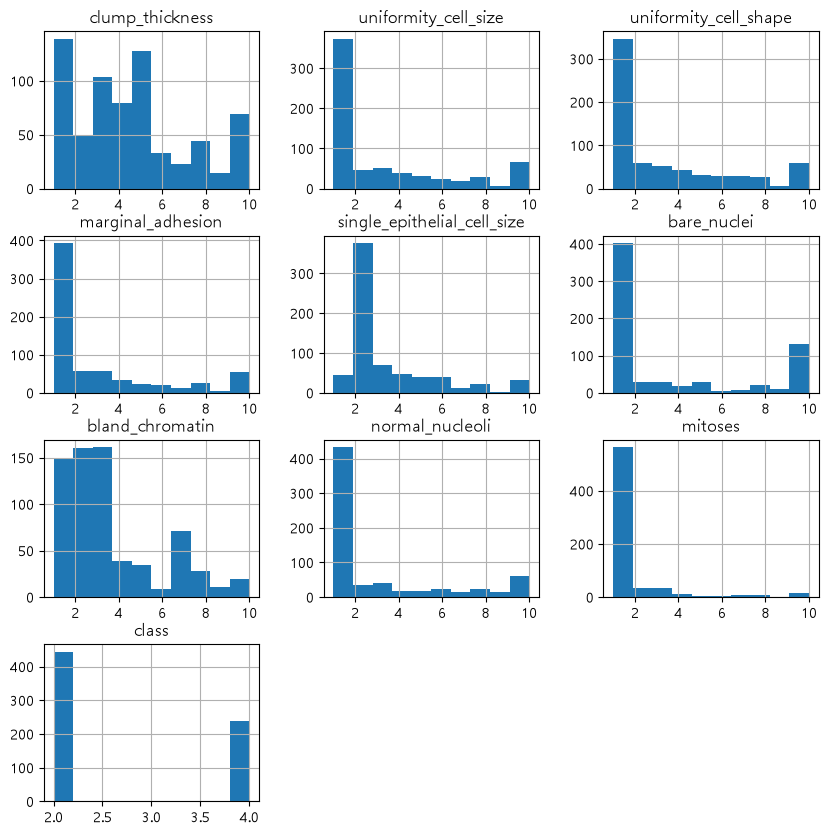

In [364]:
# Plot histograms for each variable
df.hist(figsize=(10, 10));

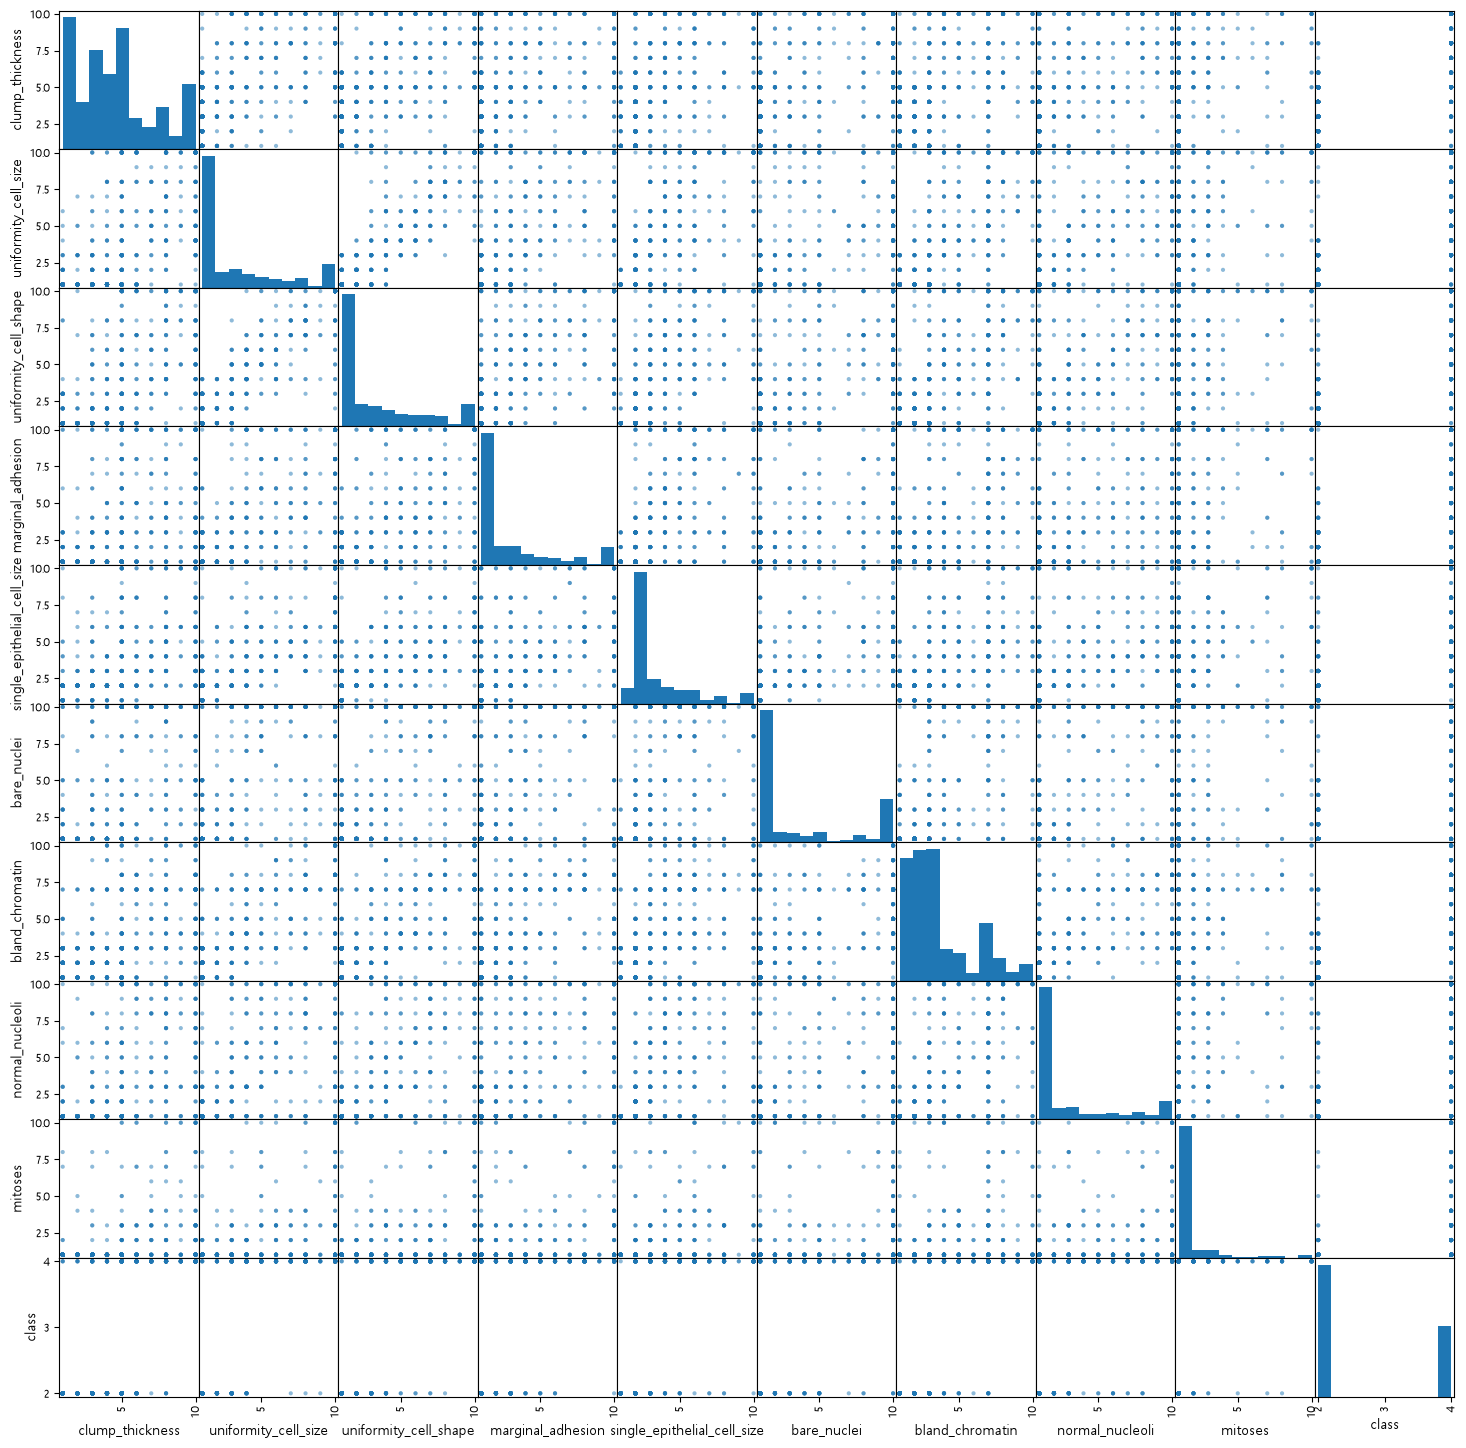

In [365]:
# Create scatter plot matrix
scatter_matrix(df, figsize=(18, 18));

히스토그램 시각화에서는 데이터프레임의 hist() 메서드를 활용하여 각 특성의 분포를  
개별적으로 표현합니다. 10x10 인치 크기로 설정된 이 그래프는 각 특성값의 빈도를 보여주는  
히스토그램을 생성합니다. 이를 통해 각 특성의 분포 형태, 중심 경향성, 왜도, 첨도 등을  
파악할 수 있으며, 데이터의 정규성이나 이상치의 존재 여부도 확인할 수 있습니다.

산점도 행렬 시각화는 scatter_matrix() 함수를 사용하여 18x18 인치 크기의 그래프로  
생성됩니다. 이 행렬은 모든 가능한 특성 쌍에 대한 산점도를 보여주며, 대각선에는 각 특성의  
분포 히스토그램이 표시됩니다. 이러한 시각화를 통해 특성들 간의 상관관계, 선형 또는 비선형  
관계의 존재, 데이터의 군집화 패턴 등을 종합적으로 파악할 수 있습니다. 특히 유방암 진단에  
있어 중요한 특성들 간의 관계를 이해하고, 이후의 모델링 단계에서 어떤 특성들이 중요한  
역할을 할 수 있는지 예측할 수 있습니다.

이러한 시각화 분석은 데이터의 구조와 패턴을 직관적으로 이해하는데 도움을 주며, 이는  
효과적인 특성 선택, 전처리 방법 결정, 그리고 적절한 모델 선택에 필수적인 정보를  
제공합니다.

**결과 해석**: 히스토그램과 산점도 행렬의 모양은 Step 4의 4번 마지막 셀 해석과 같습니다. 대부분의 특성이 1점에 몰리고 10점에서 다시 솟는 분포이며, 산점도의 점들은 정수 격자 위에 겹쳐 찍히고, `class`는 2와 4 두 줄로만 나뉩니다. 두 셀 모두 줄 끝에 세미콜론(`;`)이 있어서 그래프 객체 목록이 글자로 출력되지 않습니다.

### 4. 데이터 학습과 분류

다음 코드는 머신러닝 모델의 학습과 평가를 위해 데이터를 훈련 세트와 테스트 세트로  
분할하고, 모델 평가를 위한 기본 설정을 지정하는 부분입니다.

In [366]:
# ## Split Train/Test data
X = df.drop(['class'], axis=1).to_numpy()
y = df['class'].to_numpy()

# [개선] random_state=42: 실행할 때마다 같은 방식으로 나뉘도록 고정 → 아래 결과 해석의 수치를 그대로 재현 가능
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [367]:
# ## Specify Test options

seed = 8
scoring = 'accuracy'

먼저 특성과 레이블을 분리합니다. 데이터프레임에서 drop() 메서드를 사용하여 class 열을  
제외한 모든 특성을 X에 할당하고, to_numpy()를 통해 넘파이 배열로 변환합니다. y에는 class  
열만 선택하여 마찬가지로 넘파이 배열로 변환합니다. 이렇게 변환된 데이터는 scikit-learn  
모델에 입력하기 적합한 형태가 됩니다.

train_test_split() 함수를 사용하여 데이터를 훈련 세트와 테스트 세트로 나눕니다.  
test_size=0.2는 전체 데이터의 20%를 테스트 세트로 사용하고 나머지 80%를 훈련 세트로  
사용하겠다는 의미입니다. 이 함수는 X_train(훈련용 특성), X_test(테스트용 특성),  
y_train(훈련용 레이블), y_test(테스트용 레이블)의 네 가지 배열을 반환합니다.

마지막으로 모델 평가를 위한 기본 설정을 지정합니다. seed 값을 8로 설정하여 실험의 재현성을  
보장하고, 모델 평가 지표로는 accuracy(정확도)를 사용하도록 지정합니다. 이러한 설정은 이후  
교차 검증이나 모델 평가에서 일관된 결과를 얻는데 도움이 됩니다.

다음 코드는 유방암 분류를 위한 머신러닝 모델들을 정의하고 리스트에 저장하는 부분입니다.

In [368]:
# ## Define the model to train
models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models.append(('SVM', SVC()))

models라는 빈 리스트를 생성한 후, 여기에 두 가지 다른 분류 모델을 추가합니다. append()  
메서드를 사용하여 각 모델을 튜플 형태로 저장하는데, 튜플의 첫 번째 요소는 모델의 이름이고  
두 번째 요소는 모델 객체입니다.

첫 번째로 추가되는 모델은 k-최근접 이웃(KNN) 분류기입니다. KNeighborsClassifier를 사용하며  
n_neighbors=5 파라미터를 통해 분류시 가장 가까운 5개의 이웃을 고려하도록 설정합니다. KNN은  
새로운 데이터 포인트의 클래스를 예측할 때 주변의 가장 가까운 이웃들의 클래스를 참고하는  
간단하면서도 효과적인 알고리즘입니다.

두 번째로 추가되는 모델은 서포트 벡터 머신(SVM) 분류기입니다. SVC() 클래스를 사용하며,  
기본 파라미터 설정으로 초기화됩니다. SVM은 데이터를 고차원 공간으로 매핑하여 클래스를 가장  
잘 구분하는 결정 경계를 찾는 강력한 분류 알고리즘입니다.

이렇게 생성된 모델 리스트는 이후 각 모델의 성능을 평가하고 비교하는데 사용됩니다. 여러  
모델을 리스트로 관리함으로써 동일한 데이터셋에 대해 각 모델의 성능을 체계적으로 비교할 수  
있습니다.

다음 코드는 정의된 모델들의 성능을 교차 검증을 통해 평가하는 부분입니다. 빈 리스트  
results와 names를 생성하여 각각 모델들의 성능 결과와 이름을 저장할 준비를 합니다. 그리고  
for 루프를 사용하여 이전에 정의된 models 리스트의 각 모델을 순차적으로 평가합니다.

In [369]:
# Evaluate each model in turn
results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

KNN: 0.970741 (0.016777)
SVM: 0.968889 (0.020241)


각 모델에 대해 KFold 교차 검증을 수행합니다. n_splits=10으로 설정하여 데이터를 10개의  
폴드로 나누고, random_state=seed로 재현성을 보장하며, shuffle=True로 데이터를 섞어 편향을  
방지합니다. 이는 전체 데이터를 10개의 부분으로 나누어 9개로 학습하고 1개로 검증하는 과정을  
10번 반복하는 것을 의미합니다.

cross_val_score 함수를 사용하여 각 모델의 교차 검증 성능을 계산합니다. 이 함수는 모델,  
훈련 데이터(X_train, y_train), 교차 검증 방식(kfold), 평가 지표(scoring)를 입력받아 각  
폴드에서의 성능 점수를 반환합니다.

각 모델의 교차 검증 결과를 results 리스트에 추가하고, 모델 이름을 names 리스트에  
추가합니다. 그리고 각 모델의 평균 성능과 표준편차를 계산하여 출력합니다. 이는 모델의  
평균적인 성능과 성능의 안정성을 보여줍니다.

다음 코드는 훈련된 모델들을 사용하여 테스트 데이터에 대한 예측을 수행하고 각 모델의 성능을  
상세히 평가하는 부분입니다.

**결과 해석 — 10겹 교차 검증** (`random_state=42` 분할 기준 예시)

출력 형식 `"%s: %f (%f)"`는 `모델이름: 평균 정확도 (표준편차)`입니다.

```
KNN: 0.970741 (0.016777)
SVM: 0.968889 (0.020241)
```

- **평균**: 훈련 데이터(546명)를 10조각으로 나눠 10번 검증한 정확도의 평균. 두 모델 모두 약 97%입니다.
- **표준편차**: 10번의 정확도가 서로 얼마나 다른지. KNN 약 0.017(±1.7%p), SVM 약 0.020(±2.0%p)으로, 조각에 따라 대략 93~100% 사이를 오갑니다.
- 두 모델의 평균 차이(0.002)가 표준편차(약 0.02)보다 훨씬 작으므로, **이 결과만으로 어느 모델이 더 낫다고 말하기는 어렵습니다.** 이렇게 평균과 함께 표준편차를 보는 습관이 중요합니다.

In [370]:
# ## Make Predictions on validation dataset
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(name)
    print(accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

KNN
0.948905109489051
              precision    recall  f1-score   support

           2       0.93      0.99      0.96        79
           4       0.98      0.90      0.94        58

    accuracy                           0.95       137
   macro avg       0.95      0.94      0.95       137
weighted avg       0.95      0.95      0.95       137

SVM
0.948905109489051
              precision    recall  f1-score   support

           2       0.94      0.97      0.96        79
           4       0.96      0.91      0.94        58

    accuracy                           0.95       137
   macro avg       0.95      0.94      0.95       137
weighted avg       0.95      0.95      0.95       137



for 루프를 사용하여 models 리스트의 각 모델에 대해 평가를 수행합니다. 각 모델별로 다음과  
같은 과정이 진행됩니다. 먼저 fit() 메서드를 사용하여 훈련 데이터(X_train, y_train)로  
모델을 학습시킵니다. 그 다음 predict() 메서드로 테스트 데이터(X_test)에 대한 예측을  
수행하여 predictions에 저장합니다.

각 모델의 성능 평가는 두 가지 방식으로 이루어집니다. accuracy_score() 함수를 사용하여  
전체적인 정확도를 계산하며, 이는 올바르게 분류된 샘플의 비율을 나타냅니다.  
classification_report() 함수를 통해 더 상세한 성능 지표를 출력하는데, 이는 다음과 같은  
정보를 포함합니다.

- 정밀도(Precision): 양성으로 예측한 것 중 실제 양성의 비율
- 재현율(Recall): 실제 양성 중 양성으로 예측한 비율
- F1-score: 정밀도와 재현율의 조화평균
- Support: 각 클래스의 샘플 수

이러한 종합적인 평가를 통해 각 모델의 성능을 다각도로 분석하고, 어떤 모델이 유방암 진단에  
더 적합한지 판단할 수 있습니다.

다음 코드는 SVM 분류기(SVC)의 성능을 평가하는 또 다른 간단한 방법을 보여주는 부분입니다.

**결과 해석 — 테스트 데이터 예측** (`random_state=42` 기준 예시, 테스트 137명: 양성 79명, 악성 58명)

| 모델 | 정확도 | 양성(2) 재현율 | 악성(4) 정밀도 | 악성(4) 재현율 | 혼동행렬 [[TN, FP], [FN, TP]] |
|---|---|---|---|---|---|
| KNN | 0.949 | 0.99 | 0.98 | 0.90 | [[78, 1], [6, 52]] |
| SVM | 0.949 | 0.97 | 0.96 | 0.91 | [[77, 2], [5, 53]] |

- 두 모델의 정확도는 0.949로 같지만 **틀리는 방식이 다릅니다.** KNN은 양성을 더 잘 지키고(오경보 1명) 악성을 6명 놓쳤고, SVM은 오경보 2명·놓침 5명입니다.
- 교차 검증 평균(약 0.97)보다 테스트 정확도(0.949)가 조금 낮습니다. 이번 테스트 데이터의 악성 비율(58/137 ≈ 42%)이 전체 평균(35%)보다 높아, 판단이 까다로운 악성 사례가 상대적으로 많이 포함되었을 가능성이 있습니다.
- 두 모델 모두 **악성 재현율이 0.90 안팎**으로, 악성 10명 중 1명꼴로 놓칩니다. 의료 진단에서는 이 부분이 개선 대상입니다.

> **개선 사항**: 기존 분할 코드에는 `random_state`가 없어 실행할 때마다 훈련/테스트 데이터가 바뀌고 결과도 달라졌습니다. 이 노트북에서는 `random_state=42`를 지정해 같은 결과를 재현할 수 있게 했습니다. (`random_state` 값을 바꾸면 수치가 달라지는 것도 직접 확인해 볼 수 있습니다.)

In [371]:
# ## Another way to get accuracy

clf = SVC()
clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(accuracy)

0.948905109489051


먼저 SVC() 클래스를 사용하여 서포트 벡터 머신 분류기 객체를 생성하여 clf 변수에  
저장합니다. fit() 메서드를 호출하여 훈련 데이터(X_train, y_train)로 모델을 학습시킵니다.

그 다음 score() 메서드를 사용하여 테스트 데이터(X_test, y_test)에 대한 모델의 정확도를  
직접 계산합니다. 이 메서드는 내부적으로 테스트 데이터에 대한 예측을 수행하고 실제 레이블과  
비교하여 정확도를 계산합니다. 이는 앞서 사용한 accuracy_score() 함수를 사용하는 방법보다  
더 간단하고 직관적인 방법입니다.

이렇게 계산된 정확도는 모델이 테스트 데이터에서 얼마나 많은 샘플을 올바르게 분류했는지를  
나타내는 단일 값으로 출력됩니다. 이는 모델의 전반적인 성능을 빠르게 파악하는데 유용한  
방법이지만, 클래스별 세부적인 성능 지표는 제공하지 않는다는 점에 유의해야 합니다.

다음 코드는 훈련된 SVM 모델을 사용하여 새로운 샘플 데이터에 대한 예측을 수행하는 실제 적용  
예시를 보여주는 부분입니다.

**결과**: 7번의 SVM과 같은 기본 설정(`SVC()`)이고 같은 훈련·테스트 데이터를 쓰므로, `random_state=42` 기준으로 정확도도 같은 **0.949**(137명 중 130명 정답)가 나옵니다.

In [372]:
# ## Test it with samples

example = np.array([[4, 2, 1, 1, 1, 2, 3, 2, 10]])
example = example.reshape(len(example), -1)
prediction = clf.predict(example)
print(prediction)

example = np.array([[10, 2, 1, 1, 1, 2, 3, 2, 10]])
example = example.reshape(len(example), -1)
prediction = clf.predict(example)
print(prediction)

[2]
[4]


첫 번째 예측에서는 9개의 특성값을 가진 샘플 데이터를 numpy 배열로 생성합니다. `reshape()` 메서드를 사용하여 2차원 배열 형태로 변환하는데, 이는 scikit-learn 모델이 "샘플 수 × 특성 수" 모양의 2차원 입력을 요구하기 때문입니다. 이 샘플 데이터(`[4, 2, 1, 1, 1, 2, 3, 2, 10]`)를 모델에 입력하여 예측을 수행합니다.

두 번째 예측에서도 같은 방식으로 진행되지만, 첫 번째 특성값만 4에서 10으로 변경된 새로운 샘플 데이터(`[10, 2, 1, 1, 1, 2, 3, 2, 10]`)를 사용합니다. 이를 통해 첫 번째 특성값의 변화가 모델의 예측에 어떤 영향을 미치는지 확인할 수 있습니다.

각각의 `predict()` 메서드 호출은 입력된 샘플이 어떤 클래스에 속하는지 예측 결과를 반환합니다. 이러한 예측 실험을 통해 모델이 실제 상황에서 어떻게 작동하는지, 그리고 특성값의 변화가 예측 결과에 어떤 영향을 미치는지 실제적으로 이해할 수 있습니다.

**참고 — 출력 `[2]`, `[4]`의 의미와 이 단계까지 오기 위한 조건**

- 이 샘플들은 특성 9개짜리 **WBC Original** 데이터 형식(1~10 점수)이고, 진단 코드는 **2 = 양성, 4 = 악성**입니다. 따라서 출력은 `[2]`(양성) 또는 `[4]`(악성)로 나옵니다.
- `random_state=42` 기준으로 실행하면 첫 번째 샘플 `[4, 2, 1, 1, 1, 2, 3, 2, 10]`은 `[2]`(양성), 첫 값만 10으로 바꾼 두 번째 샘플 `[10, 2, 1, 1, 1, 2, 3, 2, 10]`은 `[4]`(악성)로 예측됩니다. **세포 덩어리 두께(`clump_thickness`) 하나만 4 → 10으로 바뀌었는데 진단이 뒤집힌 것**으로, 첫 번째 샘플이 원래 양성·악성 경계 근처에 있었고 이 특성이 판단에 큰 영향을 준다는 것을 보여줍니다.

**기존 코드에서는 왜 이 단계까지 오지 못했나?**

이 예측이 실행되려면 위에서 `df`에 데이터가 들어 있어야 합니다. 그런데 기존 2번 셀은 값이 11개인 파일에 **12개의 열 이름**을 붙였기 때문에,

1. 남는 마지막 이름 `class` 열이 전부 빈칸(NaN)이 되고,
2. `dropna()`가 빈칸 있는 행을 모두 지워 **데이터가 0행**이 되었으며,
3. 그 결과 3번 시각화에서 빈 그래프와 `ValueError`가 나고, 4번 `train_test_split()`에서는 나눌 데이터가 없어 학습 자체가 불가능했습니다.

즉 첫 단추(열 이름)가 어긋나 그 아래 모든 셀이 연쇄적으로 실패한 것입니다. 이 노트북에서는 2번 셀의 열 이름을 파일 구성에 맞게 11개로 바로잡아 이 문제를 해결했습니다(자세한 내용은 2번 셀 아래 개선 사항 참고).

### 5. 앙상블을 이용한 방법

다음 코드는 Breast Cancer 데이터셋을 활용한 머신러닝 모델 학습 및 평가를 위한 초기 설정  
과정을 보여줍니다. 먼저 numpy와 pandas를 임포트하여 데이터 처리 및 배열 연산을 준비합니다.  
이어서 scikit-learn 라이브러리의 다양한 모듈을 불러옵니다.

In [373]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer

여기에는 데이터셋을 훈련 세트와 테스트 세트로 분리하는 `train_test_split`, 모델의 일반화  
성능을 교차 검증하는 `cross_val_score`가 포함됩니다. 또한, 분류 알고리즘으로는  
`RandomForestClassifier`와 `GradientBoostingClassifier` 같은 앙상블 모델, 개별 모델로는  
`LogisticRegression`과 `SVC`가 포함됩니다.

이 코드는 앙상블 학습을 구현하기 위해 여러 분류기를 조합하여 최종 예측 결과를 도출할 수  
있는 `VotingClassifier`를 불러옵니다. 모델 평가를 위한 도구로는 `accuracy_score`,  
`classification_report`, `confusion_matrix`를 사용하여 모델의 성능을 정량적으로 분석할  
준비를 합니다.

마지막으로, scikit-learn에서 제공하는 `load_breast_cancer`를 이용해 Breast Cancer  
데이터셋을 로드합니다. 이 데이터셋은 유방암 종양의 다양한 특징을 바탕으로 양성(benign)  
또는 악성(malignant)을 분류하는 데 사용됩니다. 이러한 설정 과정을 통해 데이터를 로드하고,  
전처리 및 모델 학습, 평가를 진행할 수 있는 환경을 구축합니다.

In [374]:
# 데이터 로드
cancer = load_breast_cancer()
data = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

> **참고**: 5번부터는 데이터가 다시 바뀝니다. 1~4번은 WBC Original(특성 9개, 1~10 점수)이었고, 여기서는 scikit-learn에 내장된 **WBCD**(569명, 특성 30개)를 씁니다. 내장 데이터는 `target`이 **0 = 악성, 1 = 양성**으로, Step 3에서 UCI 파일을 `LabelEncoder`로 변환한 결과(B = 0, M = 1)와 **반대**이니 결과를 해석할 때 주의해야 합니다.

In [375]:
# 데이터 분리
X = data.drop(columns=['target'])
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

아래 코드는 데이터를 독립 변수와 종속 변수로 분리하고, 이를 학습용 데이터와 테스트용  
데이터로 나누는 과정을 보여줍니다.

먼저 데이터프레임에서 `drop` 메서드를 사용하여 `target` 열을 제거하고, 나머지 열들을 독립  
변수(`X`)로 정의합니다. `target` 열은 종속 변수(`y`)로 설정하여 예측하고자 하는 값을  
나타냅니다. 이렇게 독립 변수와 종속 변수를 분리하면 머신러닝 모델에 적합한 형식으로  
데이터를 준비할 수 있습니다.

이후 `train_test_split` 함수를 사용하여 데이터를 학습용 데이터(`X_train`, `y_train`)와  
테스트용 데이터(`X_test`, `y_test`)로 나눕니다. `test_size=0.2`는 데이터의 20%를 테스트  
세트로 할당하고, 나머지 80%를 학습 세트로 사용하도록 설정합니다. `random_state=42`를  
지정하면 데이터 분할 과정에서 항상 동일한 결과를 얻을 수 있어 재현성을 보장합니다. 이  
과정은 머신러닝 모델을 학습하고 성능을 평가하기 위한 데이터 준비 단계에 해당합니다.

In [376]:
# 모델 정의
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
gb_clf = GradientBoostingClassifier(random_state=42, n_estimators=100)
log_clf = LogisticRegression(random_state=42, max_iter=1000)
svc_clf = SVC(probability=True, random_state=42)

위 코드는 네 가지 머신러닝 모델을 정의하는 과정으로, 각각의 모델은 데이터 학습과 예측에  
있어 고유한 특성을 가집니다.

첫 번째로 정의된 랜덤 포레스트(Random Forest)는 다수의 결정 트리를 이용하는 앙상블 학습  
모델입니다. 랜덤 포레스트는 각 트리가 학습한 결과를 결합하여 최종 예측을 만드는데, 이는  
과적합을 방지하고 안정적인 성능을 제공합니다. 이 모델은 100개의 트리를 사용하도록 설정되어  
있으며, 재현 가능한 결과를 위해 `random_state`가 42로 설정되었습니다.

두 번째 모델은 그래디언트 부스팅(Gradient Boosting)으로, 이전 모델이 만든 예측 오차를  
줄이는 방식으로 학습을 진행합니다. 그래디언트 부스팅은 단계적으로 모델을 개선하며 강력한  
예측 성능을 제공하는 알고리즘입니다. 이 모델 역시 100개의 부스팅 단계를 사용하며, 동일하게  
`random_state`가 설정되어 있습니다.

세 번째 모델은 로지스틱 회귀(Logistic Regression)입니다. 로지스틱 회귀는 종속 변수가  
이진값을 가지는 경우에 주로 사용되는 선형 분류 알고리즘으로, 데이터의 확률 분포를 기반으로  
예측을 수행합니다. 학습의 반복 횟수를 1000으로 설정하여 충분히 학습할 수 있도록 하였으며,  
결과의 재현성을 위해 `random_state`를 사용합니다.

마지막으로 정의된 모델은 서포트 벡터 머신(Support Vector Machine, SVM)입니다. SVM은  
데이터를 고차원 공간에 투영하여 최적의 분류 경계를 찾는 비선형 분류 알고리즘입니다. 이  
코드에서는 예측 확률을 반환하도록 `probability` 옵션을 활성화하였으며, 역시  
`random_state`를 통해 일관된 결과를 제공합니다. 이 네 가지 모델은 이후 앙상블 학습을 통해  
결합되어 더 나은 예측 성능을 도출하는 데 사용될 것입니다.

In [377]:
# VotingClassifier 생성 (앙상블)
voting_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf), ('log', log_clf), ('svc', svc_clf)],
    voting='soft'
)

In [378]:
# 모델 학습
voting_clf.fit(X_train, y_train)

c:\Users\Taeeun Eom\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Taeeun Eom\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('log',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

위 코드는 VotingClassifier를 생성하고 이를 학습시키는 과정입니다. VotingClassifier는 여러  
개의 개별 모델을 결합하여 더 나은 예측 성능을 도출하는 앙상블 학습 방법입니다. 여기서는  
랜덤 포레스트, 그래디언트 부스팅, 로지스틱 회귀, 서포트 벡터 머신 총 네 가지 모델을  
결합합니다.

모델 생성 시 `estimators` 매개변수에는 각 모델의 이름과 해당 모델 객체를 튜플 형식으로  
전달합니다. 예를 들어, "rf"는 랜덤 포레스트 모델을 나타내고, "gb"는 그래디언트 부스팅  
모델을 나타냅니다. `voting` 매개변수는 "soft"로 설정되어 있어, 개별 모델의 클래스 확률값을  
평균하여 최종 예측을 수행합니다.

이후 `fit` 메서드를 호출하여 `VotingClassifier`를 학습 데이터에 맞게 학습시킵니다. 이를  
통해 모든 개별 모델이 학습되며, 최종적으로 이 모델들의 예측 결과를 결합하여 성능을  
극대화할 수 있는 앙상블 모델이 완성됩니다. 이 과정은 다양한 개별 모델의 강점을 결합하여 더  
안정적이고 일반화된 예측 결과를 얻는 데 유리합니다.

**참고 — 소프트 보팅이란? 그리고 왜 이 모델들을 골랐나**

**① 하드 보팅 vs 소프트 보팅**

| 구분 | 하드 보팅 (hard voting) | 소프트 보팅 (soft voting) |
|---|---|---|
| 투표 방식 | 각 모델이 **최종 답(0 또는 1)**을 내고 다수결 | 각 모델이 **확률(0~1)**을 내고 그 평균으로 결정 |
| 필요 조건 | 모든 모델에 `predict()`만 있으면 됨 | 모든 모델이 `predict_proba()`(확률 예측)를 지원해야 함 |
| 장점 | 단순하고 어떤 모델이든 조합 가능 | 각 모델의 **확신 정도**까지 반영. 동점 문제가 거의 없음 |
| 이 노트북 | Step 3의 ELRL-E (ETC · LightGBM · Ridge · LDA) | 여기 Step 5의 5번 (RF · GB · LR · SVC) |

**예시**: 어떤 환자에 대해 네 모델이 "악성일 확률"을 0.90, 0.45, 0.45, 0.45로 냈다고 하면,

- 하드 보팅: 각 모델이 0.5 기준으로 답을 정하면 악성 1표, 양성 3표 → **양성**
- 소프트 보팅: 평균 확률 (0.90 + 0.45 + 0.45 + 0.45) ÷ 4 = 0.5625 → 0.5 이상이므로 **악성**

한 모델이 매우 확신하고 나머지는 애매할 때, 소프트 보팅은 그 확신을 살려서 판단합니다.

**왜 앞의 ELRL-E는 하드 보팅이었나?** 구성원인 `RidgeClassifier`가 확률을 계산하는 `predict_proba()`를 제공하지 않아서 소프트 보팅을 쓸 수 없었습니다. 반면 여기 네 모델은 모두 확률을 낼 수 있어 소프트 보팅이 가능합니다. 단, `SVC`는 원래 확률을 내지 않기 때문에 `probability=True`를 지정해야 하며, 이때 내부적으로 교차 검증을 추가로 수행해 확률을 보정하므로 학습 시간이 조금 늘어납니다.

**② 이 앙상블(RF · GB · LR · SVC)을 구성하는 모델**

| 모델 | 작동 원리 | 장점 | 약점 | 앙상블에서의 역할 |
|---|---|---|---|---|
| Random Forest (랜덤 포레스트) | 데이터와 특성을 무작위로 뽑아 결정 트리를 여러 개(100개) 만들고 다수결 | 과적합에 강하고 안정적. 스케일링 불필요 | 모델이 크고 해석이 어려움 | 안정적인 기본 판단 |
| Gradient Boosting (그래디언트 부스팅) | 앞 트리가 틀린 부분을 다음 트리가 보완하도록 순서대로 트리를 쌓음 | 정확도가 높고 복잡한 패턴을 잘 잡음 | 설정값에 민감, 과적합 위험 | 어려운 사례를 세밀하게 판단 |
| Logistic Regression (로지스틱 회귀) | 특성의 가중합을 0~1 확률로 변환하는 선형 모델 | 빠르고 결과 해석이 쉬움. 확률이 비교적 잘 보정됨 | 직선(평면) 경계만 만들 수 있음 | 단순하고 매끄러운 경계 제공 |
| SVC (서포트 벡터 머신) | 두 클래스 사이의 간격(margin)이 최대가 되는 경계를 찾음. RBF 커널로 곡선 경계 가능 | 특성이 많은 데이터에서도 강함 | 특성 스케일에 민감, 확률 계산에 추가 비용 | 경계 근처 사례 판단 |

**③ 앞의 ELRL-E(ETC · LightGBM · Ridge · LDA)를 구성하는 모델**

| 모델 | 작동 원리 | 장점 | 약점 |
|---|---|---|---|
| Extra Trees Classifier | 랜덤 포레스트와 비슷하지만, 분할 기준값까지 **무작위로** 정해 트리를 만듦 | 랜덤 포레스트보다 빠르고, 결과의 들쭉날쭉함(분산)이 작음 | 무작위성이 커서 개별 트리는 부정확 |
| LightGBM | 구간(히스토그램) 기반의 빠른 그래디언트 부스팅. 오차를 가장 많이 줄이는 잎부터 키움 | 매우 빠르고 정확 | 작은 데이터에서는 과적합 위험(Step 3의 LightGBM 로그 참고) |
| Ridge Classifier | 선형 모델에 L2 규제(가중치가 너무 커지지 않도록 벌점을 주는 방법)를 더함 | 상관된 특성이 많아도 안정적 | 곡선 경계 불가, 확률 출력 없음 |
| LDA (선형 판별 분석) | 클래스 사이 거리는 최대, 클래스 안의 퍼짐은 최소가 되는 방향으로 데이터를 투영해 직선 경계를 만듦 | 계산이 빠르고 데이터가 정규분포에 가까우면 강함 | 정규분포·같은 분산 가정이 깨지면 약해짐 |

**④ 왜 이렇게 '섞어서' 쓰는가?**

두 앙상블 모두 **트리 계열**(비선형 패턴, 특성 간 상호작용에 강함)과 **선형 계열**(단순하고 안정적인 경계)을 섞었습니다. 서로 다른 방식으로 생각하는 모델들은 **틀리는 환자도 서로 다르기 때문에**, 투표로 합치면 한 모델의 실수를 다른 모델이 보완할 수 있습니다. 실제로 Step 3의 5번에서 놓친 악성 환자 중 일부는 "트리 모델은 악성, 선형 모델은 양성"으로 의견이 갈린 경우였는데, 이렇게 의견이 다양해야 앙상블이 의미가 있습니다.

In [379]:
# 평가
y_pred = voting_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[40  3]
 [ 0 71]]


위 코드는 `VotingClassifier`를 테스트 데이터로 평가하는 과정을 보여줍니다. 평가 지표로는  
정확도, 분류 보고서, 혼동 행렬을 사용하여 모델의 성능을 다각도로 분석합니다.

먼저 `predict` 메서드를 사용하여 테스트 데이터 `X_test`에 대한 예측 결과를 도출합니다. 이  
예측 결과는 앙상블 모델이 개별 모델들의 예측을 결합한 최종 결과입니다.

`accuracy_score`를 사용해 정확도를 계산하여, 예측 결과와 실제 값(`y_test`)이 얼마나  
일치하는지를 비율로 나타냅니다. 이는 모델의 전반적인 성능을 간단하게 평가할 수 있는  
지표입니다.

`classification_report`를 통해 더 상세한 성능 지표를 확인합니다. 이 보고서는 클래스별로  
정밀도(Precision), 재현율(Recall), F1-점수(F1-Score)를 제공합니다. 정밀도는 예측이 얼마나  
정확한지를 나타내며, 재현율은 실제 양성 데이터를 모델이 얼마나 잘 감지했는지를 보여줍니다.  
F1-점수는 정밀도와 재현율의 조화를 나타내는 지표로, 균형 잡힌 평가를 제공합니다.

마지막으로, `confusion_matrix`를 사용해 혼동 행렬을 출력합니다. 이 행렬은 예측된 클래스와  
실제 클래스의 비교 결과를 보여줍니다. 혼동 행렬의 각 항목은 모델의 예측이 얼마나  
정확했는지, 또는 어디에서 오류가 발생했는지를 명확히 시각화합니다. 이를 통해 모델이 특정  
클래스에서 잘못된 예측을 자주 하는지 확인할 수 있습니다.

결과적으로, 이러한 평가 과정을 통해 모델의 강점과 약점을 분석하고, 필요한 경우 모델을  
수정하거나 개선할 방향을 도출할 수 있습니다.

> **참고**: 내장 데이터는 0=악성, 1=양성이라 classification_report의 `0` 행이  
> **악성**이다. 암 환자를 놓치지 않았는지는 `0` 행의 recall(재현율)로 확인한다.

**결과 해석** (위 셀 실행 기준, 테스트 114명: 악성(0) 43명, 양성(1) 71명)

| 항목 | 값 | 의미 |
|---|---|---|
| Accuracy | 약 0.974 | 114명 중 111명을 맞힘 |
| 악성(0) precision | 1.00 | 악성이라고 판정한 40명은 모두 실제 악성 (오경보 0) |
| 악성(0) recall | 0.93 | 실제 악성 43명 중 40명을 찾고 **3명을 놓침** |
| 양성(1) precision | 0.96 | 양성이라고 판정한 74명 중 71명이 실제 양성 (3명은 놓친 악성) |
| 양성(1) recall | 1.00 | 실제 양성 71명은 모두 양성으로 판정 |
| 혼동행렬 | `[[40, 3], [0, 71]]` | 1행 = 실제 악성(40명 정답, 3명 오답), 2행 = 실제 양성(0명 오답, 71명 정답) |

- **레이블 방향에 주의**: 이 데이터는 0 = 악성이므로, 혼동행렬 1행의 `3`은 "악성을 양성으로 놓친 환자"입니다. Step 3(1 = 악성)의 혼동행렬과 위치가 반대입니다.
- 모델은 양성 환자를 단 한 명도 악성으로 오인하지 않았지만, 악성 3명을 놓쳤습니다. 암 진단 관점에서 가장 중요한 숫자는 **악성(0)의 recall 0.93**입니다.
- 확률을 평균하는 소프트 보팅이라, 하드 보팅에서 문제가 되었던 2 : 2 동점이 생기지 않습니다.

In [380]:
# 개별 모델 성능 비교
models = [rf_clf, gb_clf, log_clf, svc_clf]
model_names = ['Random Forest', 'Gradient Boosting', 'Logistic Regression', 'SVC']
for model, name in zip(models, model_names):
    model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)
    print(f"\n{name} Accuracy:", accuracy_score(y_test, y_pred_model))


Random Forest Accuracy: 0.9649122807017544

Gradient Boosting Accuracy: 0.956140350877193

Logistic Regression Accuracy: 0.956140350877193

SVC Accuracy: 0.9473684210526315


c:\Users\Taeeun Eom\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Taeeun Eom\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


위 코드는 `Random Forest`, `Gradient Boosting`, `Logistic Regression`, `SVC`의 개별 성능을  
평가하고 비교하는 과정을 보여줍니다. 이를 통해 각 모델의 정확도를 독립적으로 분석하고  
앙상블 모델과의 성능 차이를 확인할 수 있습니다.

먼저 `models` 리스트에 사용할 개별 모델 객체를, `model_names` 리스트에 해당 모델들의  
이름을 저장합니다. 이후 `zip` 함수를 사용해 모델과 이름을 쌍으로 묶어 반복문에서  
처리합니다.

각 반복에서 해당 모델을 `fit` 메서드를 통해 학습 데이터 `X_train`과 `y_train`으로  
학습시킵니다. 학습된 모델에 대해 `predict` 메서드를 호출하여 테스트 데이터 `X_test`에 대한  
예측값 `y_pred_model`을 도출합니다.

`accuracy_score` 함수를 사용하여 테스트 데이터에 대한 모델의 정확도를 계산하고, 이를  
출력합니다. 출력 메시지에는 모델 이름과 정확도가 포함되어 각 모델의 성능을 명확히  
보여줍니다.

이 과정을 통해 개별 모델들이 테스트 데이터에서 얼마나 잘 작동하는지 알 수 있으며, 특정  
모델이 다른 모델보다 성능이 우수한지 확인할 수 있습니다. 이를 통해 앙상블 모델의 결과와  
개별 모델 성능 간의 차이를 분석하고 최적의 모델 전략을 설계할 수 있습니다.

**결과 해석 — 개별 모델 vs 소프트 보팅 앙상블** (위 셀 실행 기준)

| 모델 | 정확도 | 놓친 악성 | 오경보 |
|---|---|---|---|
| Random Forest | 0.965 | 3 | 1 |
| Gradient Boosting | 0.956 | 3 | 2 |
| Logistic Regression | 0.956 | 4 | 1 |
| SVC | 0.947 | 6 | 0 |
| **소프트 보팅 앙상블** | **0.974** | **3** | **0** |

- 이번에는 **앙상블이 모든 개별 모델보다 정확도가 높습니다.** 놓친 악성 수는 가장 좋은 개별 모델(3명)과 같으면서 오경보는 0명으로 줄였습니다. 서로 다른 모델의 확률을 평균하면서 각자의 실수가 상쇄된 결과입니다.
- Step 3의 하드 보팅 앙상블(ExtraTrees 단독보다 낮았음)과 비교하면, **모델 조합과 투표 방식에 따라 앙상블의 효과가 달라진다**는 것을 알 수 있습니다.
- SVC 성능이 가장 낮은 것은 이 절에서 **스케일링 없이** 원본 30개 특성(값 범위 0.05 ~ 4254)을 그대로 넣었기 때문일 가능성이 큽니다. SVC와 로지스틱 회귀는 숫자 크기에 민감한 모델입니다.
- 실행 중 `ConvergenceWarning: lbfgs failed to converge` 경고가 나올 수 있습니다. 로지스틱 회귀가 정해진 반복 횟수(`max_iter=1000`) 안에 최적값을 다 찾지 못했다는 뜻으로, 역시 특성 스케일 차이가 큰 것이 원인입니다. 에러가 아니며 결과는 정상적으로 나오고, `StandardScaler`로 표준화하면 대부분 사라집니다.

### 6. AutoML을 이용한 방법

AutoML(Auto Machine Learning)은 머신러닝 모델 개발 과정을 자동화하는 기술입니다. 전통적인  
머신러닝 워크플로에서는 데이터 전처리, 특징 엔지니어링, 모델 선택, 하이퍼파라미터 튜닝  
등을 사람이 직접 수행해야 했습니다. 이 과정은 많은 시간과 전문 지식을 요구하며, 특히  
초보자에게는 어려울 수 있습니다. AutoML은 이러한 작업을 자동으로 처리해 사용자가 최소한의  
개입으로도 고성능 머신러닝 모델을 만들 수 있도록 도와줍니다. AutoML은 다음과 같은 주요  
단계를 자동화합니다.

- 데이터 전처리: 결측값 처리, 범주형 변수 인코딩, 스케일링 등의 작업을 자동으로  
  수행합니다.
- 특징 엔지니어링: 중요한 변수를 자동으로 생성하거나 선택해 데이터 품질을 높입니다.
- 모델 선택: 다양한 알고리즘(예: 의사결정 나무, 랜덤 포레스트, 로지스틱 회귀 등)을  
  테스트하고 최적의 모델을 선택합니다.
- 하이퍼파라미터 튜닝: 선택한 모델의 하이퍼파라미터를 조정해 성능을 극대화합니다.
- 모델 평가 및 비교: 모델 성능을 평가하고 가장 적합한 모델을 제공합니다.

대표적인 AutoML 도구로는 Auto-sklearn, H2O.ai, Google AutoML, TPOT 등이 있으며, 사용자는  
복잡한 코드를 작성하지 않아도 간단한 인터페이스로 고성능 모델을 개발할 수 있습니다.

AutoML의 가장 큰 장점은 시간 절약과 효율성입니다. 머신러닝 전문가뿐만 아니라 비전문가도  
손쉽게 모델을 개발할 수 있으며, 데이터 분석 및 예측에 필요한 노력을 크게 줄일 수 있습니다.  
다만, 데이터 품질이나 도메인 지식의 중요성은 여전히 유지되므로, AutoML을 사용할 때에도  
데이터를 이해하고 적절히 준비하는 단계는 필수적입니다.

아래에서는 데이터셋을 훈련 세트와 테스트 세트로 나누기 위해 Scikit-learn의  
`train_test_split` 함수를 사용합니다. 이는 모델 학습과 평가를 위해 데이터를 분리하는  
필수적인 과정입니다.

> ⚠️ **실행 환경 안내 — auto-sklearn 대신 FLAML로 실습합니다**
>
> - 원래 예제에서 쓰는 **auto-sklearn**은 리눅스에서만 설치되는 라이브러리입니다(내부적으로 리눅스 전용 구성 요소에 의존). 그래서 Windows의 VS Code에서는 설치되지 않고, 개발이 사실상 멈춘 상태라 최신 Python(3.12)·scikit-learn과도 잘 맞지 않습니다. WSL(Windows 안에서 돌아가는 리눅스)에서도 Python 3.9~3.10 같은 별도 가상환경을 만들어야 할 수 있습니다.
> - 그래서 이 노트북은 **FLAML**(Microsoft가 만든 AutoML 라이브러리)을 기본 실습 도구로 추가했습니다. FLAML은 Windows·VS Code에서 `pip`로 바로 설치되고, auto-sklearn과 마찬가지로 **모델 선택 + 하이퍼파라미터 튜닝을 자동**으로 해 줍니다.
> - auto-sklearn 코드도 그대로 남겨 두었습니다. 설치된 환경(리눅스/WSL)에서는 그 셀이 실행되고, 설치되지 않은 환경에서는 자동으로 건너뛴 뒤 FLAML 셀에서 같은 실습을 이어갑니다.

**FLAML 설치하기 (처음 한 번만)**

> ⚠️ **실행 전 주의**
> - 아래 셀은 인터넷에서 FLAML과 관련 라이브러리(LightGBM, XGBoost 등)를 내려받아 **현재 노트북이 쓰는 파이썬 환경(커널)**에 설치합니다. 회사·학교 PC처럼 설치 권한이 제한된 환경에서는 관리자에게 먼저 확인하세요.
> - 이미 설치된 scikit-learn·pandas와 버전이 맞지 않으면 일부 라이브러리의 버전이 자동으로 바뀔 수 있습니다. 다른 프로젝트와 같은 환경을 쓰고 있다면, 프로젝트별 가상환경(venv)에서 실행하는 것이 안전합니다.
> - 설치가 끝나면 **커널을 다시 시작**해야 새 라이브러리를 불러올 수 있습니다. VS Code 노트북 상단의 **다시 시작(Restart)** 버튼을 누른 뒤, 이 절의 셀을 위에서부터 다시 실행하세요.

**어디서 실행하나?** VS Code에서 이 노트북을 열고, 아래 코드 셀을 그대로 실행하면 됩니다(별도의 터미널을 열 필요 없음).

| 코드 부분 | 의미 |
|---|---|
| `%pip` | 주피터 노트북 전용 명령(매직 명령어). **현재 커널이 쓰는 파이썬**에 정확히 설치해 줌. 그냥 `!pip`를 쓰면 다른 파이썬에 설치되는 실수가 생길 수 있음 |
| `install` | 패키지를 설치하라는 명령 |
| `"flaml[automl]"` | FLAML 본체 + AutoML 기능에 필요한 추가 패키지(LightGBM, XGBoost, scikit-learn 등)를 함께 설치. 대괄호 `[automl]`은 "추가 기능 묶음"을 뜻하며, 터미널 종류에 따라 대괄호를 다르게 해석할 수 있어 큰따옴표로 감쌈 |

터미널에서 설치하고 싶다면 VS Code 메뉴의 **터미널 → 새 터미널**을 열고, 노트북과 같은 파이썬 환경이 선택된 상태에서 `pip install "flaml[automl]"`을 실행해도 됩니다.

In [381]:
# FLAML 설치 (처음 한 번만 실행)


# %pip install: 현재 노트북 커널의 파이썬 환경에 패키지를 설치
# "flaml[automl]": FLAML + AutoML에 필요한 추가 패키지(LightGBM, XGBoost 등)를 함께 설치
%pip install "flaml[automl]"


# → FLAML을 설치하겠다 (설치 후에는 커널을 다시 시작하고 이 절의 셀을 위에서부터 다시 실행)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [382]:
# 라이브러리 불러오기


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer

# ===== auto-sklearn (Linux / WSL only) =====
# try / except ImportError: 불러오기를 '시도'하고, 설치되어 있지 않아 실패하면 에러로 멈추지 않고 except 아래를 실행
try:
    from autosklearn.classification import AutoSklearnClassifier
    AUTOSKLEARN_OK = True
except ImportError:
    AUTOSKLEARN_OK = False

# ===== FLAML (Windows / macOS / Linux) =====
try:
    # AutoML: FLAML의 자동 머신러닝 클래스
    from flaml import AutoML
    FLAML_OK = True
except ImportError:
    FLAML_OK = False

print("auto-sklearn 사용 가능:", AUTOSKLEARN_OK)
print("FLAML 사용 가능:", FLAML_OK)


# → 두 AutoML 도구 중 이 PC에 설치된 것이 무엇인지 확인하고, 아래 학습 셀에서 쓸 수 있게 기록해 두겠다

auto-sklearn 사용 가능: False
FLAML 사용 가능: True


AutoML 모델을 구축하기 위해 두 가지 도구를 불러옵니다.

| 도구 | 불러오는 코드 | 실행 환경 |
|---|---|---|
| auto-sklearn | `from autosklearn.classification import AutoSklearnClassifier` | 리눅스 / WSL 전용 |
| FLAML | `from flaml import AutoML` | Windows · macOS · 리눅스 모두 가능 (이 노트북의 기본) |

두 도구 모두 모델 선택, 하이퍼파라미터 튜닝(모델의 설정값을 자동으로 바꿔 가며 가장 좋은 조합을 찾는 것), 일부 전처리를 자동화하여 사용자가 세부 설정을 하지 않아도 좋은 모델을 찾아 줍니다.

`try:` / `except ImportError:` 구조는 "일단 불러오기를 시도하고, 설치되어 있지 않아 실패하면(`ImportError`) 에러로 멈추지 말고 `except` 아래를 실행하라"는 뜻입니다. 불러오기에 성공했는지를 `AUTOSKLEARN_OK`, `FLAML_OK`라는 참/거짓 변수에 기록해 두고, 아래 학습 셀에서 이 값을 보고 실행 여부를 정합니다. Windows에서 FLAML을 설치했다면 출력은 `auto-sklearn 사용 가능: False`, `FLAML 사용 가능: True`가 됩니다.

마지막으로, 모델 성능 평가를 위해 Scikit-learn의 다양한 메트릭 함수를 불러옵니다. `accuracy_score`는 정확도를 측정하며, `classification_report`는 정밀도, 재현율, F1 점수를 포함한 종합적인 성능 평가를 제공합니다. `confusion_matrix`는 분류 결과를 표로 정리하여 잘못된 예측 패턴을 파악하는 데 유용합니다.

아래 코드는 유방암 데이터셋을 로드하고 이를 데이터프레임으로 변환하는 과정을 보여줍니다.

In [383]:
# 데이터 로드 및 데이터프레임 생성
cancer = load_breast_cancer()
data = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

데이터셋으로 `sklearn.datasets`에서 제공하는 `load_breast_cancer`를 사용합니다. 이  
데이터셋은 유방암 진단 데이터를 포함하고 있으며, 특징 변수와 타깃 변수가 포함되어  
있습니다.

`load_breast_cancer()` 함수를 호출해 데이터를 로드하고, 이 데이터를 `pandas`의  
데이터프레임으로 변환합니다.

`cancer.data`는 유방암 데이터의 특징 값을 포함하고 있고, `cancer.feature_names`는 특징  
변수의 이름을 제공합니다. 이 두 요소를 사용해 `data`라는 데이터프레임을 생성하며,  
마지막으로 타깃 값을 `cancer.target`에서 가져와 `target`이라는 열로 추가합니다.

결과적으로 `data` 데이터프레임에는 유방암 진단을 위한 특징 변수와 타깃 변수가 포함되어  
있으며, 모델 학습에 필요한 형식으로 데이터를 준비합니다.

다음은 데이터를 훈련 데이터와 테스트 데이터로 분리하는 작업은 머신러닝 모델을 효과적으로  
학습시키고 평가하는 데 필수적인 단계입니다. 여기서 사용된 코드는 `target` 열을 타깃 변수로  
설정하고 나머지 열을 특징 데이터로 분리한 후, 이를 훈련 데이터와 테스트 데이터로 나누는  
과정을 수행합니다.

In [384]:
# 데이터 분리
X = data.drop(columns=['target'])
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

우선, 데이터프레임에서 `target` 열을 제외한 나머지 열을 `X`에 저장하여 모델의 입력  
데이터를 준비합니다. 이와 동시에 `target` 열을 `y`로 저장하여 모델이 예측해야 하는 출력  
값으로 설정합니다.

`train_test_split` 함수를 활용하여 데이터를 훈련용과 테스트용으로 나누는데, 이때 전체  
데이터의 80%는 훈련 데이터로, 나머지 20%는 테스트 데이터로 사용합니다. `test_size=0.2`는  
테스트 데이터의 비율을 나타내며, `random_state=42`는 데이터를 분할하는 과정의 무작위성을  
제어하여 결과의 일관성을 보장합니다.

이 과정은 모델 학습과 평가를 위한 데이터를 준비하는 중요한 단계로, 훈련 데이터는 모델을  
학습시키는 데 사용되며, 테스트 데이터는 학습된 모델의 성능을 검증하는 데 사용됩니다. 이를  
통해 모델의 일반화 성능을 객관적으로 평가할 수 있습니다.

In [385]:
# Auto-sklearn 모델 정의 및 학습 (리눅스 / WSL 전용)


if AUTOSKLEARN_OK:
    # AutoSklearnClassifier: 여러 모델과 설정을 자동으로 시도해 가장 좋은 조합(앙상블)을 만드는 분류기
    automl = AutoSklearnClassifier(
        time_left_for_this_task=300,  # 전체 탐색 시간 제한 (초) = 5분
        per_run_time_limit=30,        # 모델 하나를 학습하는 데 허용하는 최대 시간 (초)
        seed=42                       # [개선] auto-sklearn의 난수 고정 인자 이름은 random_state가 아니라 seed
    )

    automl.fit(X_train, y_train)

    # 학습 결과 출력
    print("AutoML에서 선택된 모델 구성:")
    print(automl.show_models())

    # 테스트 데이터 평가
    y_pred = automl.predict(X_test)
    print("\n정확도:", accuracy_score(y_test, y_pred))
    print("\n분류 보고서:\n", classification_report(y_test, y_pred))
    print("\n혼동 행렬:\n", confusion_matrix(y_test, y_pred))
else:
    print("auto-sklearn이 설치되어 있지 않아 이 셀은 건너뜁니다 → 아래 FLAML 셀에서 같은 실습을 진행하세요.")


# → 리눅스 환경이면 auto-sklearn으로 5분간 최적 모델을 찾고, 아니면 FLAML 실습으로 넘어가겠다

auto-sklearn이 설치되어 있지 않아 이 셀은 건너뜁니다 → 아래 FLAML 셀에서 같은 실습을 진행하세요.


> **개선 사항 — auto-sklearn 코드**: 기존 코드는 `AutoSklearnClassifier(..., random_state=42)`로 되어 있었는데, auto-sklearn은 난수 고정 인자의 이름이 `seed`라서 `random_state`를 넣으면 `TypeError`가 발생합니다. 이 노트북에서는 `seed=42`로 바로잡았고, 설치되지 않은 환경에서는 오류 없이 건너뛰도록 `if AUTOSKLEARN_OK:` 조건을 추가했습니다.

**FLAML로 AutoML 실습하기 (Windows · VS Code에서 실행 가능)**

FLAML(Fast Lightweight AutoML)은 정해진 시간 안에서 **계산 비용이 적게 드는 설정부터 먼저 시도하고, 성능이 좋아지는 방향으로 점점 탐색 범위를 넓히는 방식**으로 최적의 모델과 하이퍼파라미터를 찾습니다. 그래서 짧은 시간에도 좋은 결과를 내는 것이 특징입니다.

auto-sklearn 코드와 비교하면 다음과 같이 대응됩니다.

| auto-sklearn | FLAML | 의미 |
|---|---|---|
| `AutoSklearnClassifier(...)` | `AutoML()` + `fit(task='classification')` | 분류용 AutoML 객체 |
| `time_left_for_this_task=300` | `time_budget=60` | 전체 탐색 시간(초). 실습 시간을 줄이려고 60초로 설정 |
| (기본 평가 기준 사용) | `metric='accuracy'` | 어떤 점수가 가장 높은 모델을 찾을지 |
| `seed=42` | `seed=42` | 탐색 순서 고정 |
| `show_models()` | `best_estimator`, `best_config` | 최종 선택된 모델 종류와 설정값 |

In [386]:
# FLAML AutoML 모델 정의 및 학습


if FLAML_OK:
    # AutoML(): 모델 종류와 하이퍼파라미터를 자동으로 탐색하는 FLAML의 핵심 객체
    automl_flaml = AutoML()

    automl_flaml.fit(
        # X_train, y_train: 위에서 나눈 학습용 데이터 (455명 × 30개 특성)
        X_train=X_train, y_train=y_train,
        # task='classification': 분류 문제(악성/양성 맞히기)라고 알려줌
        task='classification',
        # metric='accuracy': 정확도가 가장 높은 조합을 찾도록 기준을 정함
        metric='accuracy',
        # time_budget=60: 전체 탐색 시간 60초. 시간이 길수록 더 많은 조합을 시도
        time_budget=60,
        # estimator_list: 후보 모델 목록 (LightGBM, 랜덤 포레스트, 엑스트라 트리, XGBoost, L2 로지스틱 회귀)
        estimator_list=['lgbm', 'rf', 'extra_tree', 'xgboost', 'lrl2'],
        # seed=42: 탐색 순서를 고정 (시간 제한 방식이라 PC 속도에 따라 결과가 조금 달라질 수 있음)
        seed=42,
        # verbose=0: 탐색 과정 로그를 끄고 최종 결과만 보기 (과정을 보고 싶으면 1 이상)
        verbose=0,
    )

    # best_estimator: 탐색 결과 가장 좋았던 모델 종류
    print("가장 좋은 모델 종류:", automl_flaml.best_estimator)
    # best_loss: 가장 좋은 모델의 손실값. metric='accuracy'일 때 손실 = 1 - 정확도 → 1에서 빼면 검증 정확도
    print("검증 정확도:", round(1 - automl_flaml.best_loss, 4))
    # best_config: 그 모델에 대해 찾은 하이퍼파라미터(설정값) 조합
    print("선택된 하이퍼파라미터:", automl_flaml.best_config)
else:
    print("FLAML이 설치되어 있지 않습니다 → 위의 %pip install 셀을 실행한 뒤 커널을 다시 시작하세요.")


# → 60초 동안 5종류의 모델과 설정을 자동으로 시도해, 정확도가 가장 높은 조합을 찾겠다

가장 좋은 모델 종류: xgboost
검증 정확도: 0.978
선택된 하이퍼파라미터: {'n_estimators': 103, 'max_leaves': 8, 'min_child_weight': np.float64(0.517840791595386), 'learning_rate': np.float64(0.39284340398405637), 'subsample': np.float64(0.7845696371419859), 'colsample_bylevel': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.006041169775255147), 'reg_lambda': np.float64(0.03431258444505093)}


In [387]:
# FLAML 모델로 테스트 데이터 평가


if FLAML_OK:
    # predict(): 찾아낸 최적 모델로 테스트 데이터(114명)를 예측
    y_pred_flaml = automl_flaml.predict(X_test)

    print("정확도:", accuracy_score(y_test, y_pred_flaml))
    print("\n분류 보고서:\n", classification_report(y_test, y_pred_flaml))
    print("\n혼동 행렬:\n", confusion_matrix(y_test, y_pred_flaml))


# → AutoML이 고른 모델을 한 번도 보지 않은 테스트 데이터로 평가해, 앞의 앙상블과 비교하겠다

정확도: 0.956140350877193

분류 보고서:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


혼동 행렬:
 [[40  3]
 [ 2 69]]


**결과 읽는 법과 해석**

FLAML은 정해진 시간 안에 탐색하기 때문에 **PC 속도에 따라 시도한 조합 수가 달라지고, 결과도 실행마다 조금씩 다를 수 있습니다.** 아래는 같은 코드로 실행했을 때 나올 수 있는 결과의 예입니다.

| 출력 | 예시 값 | 의미 |
|---|---|---|
| 가장 좋은 모델 종류 | `xgboost` (또는 `lgbm`, `rf` 등) | 5개 후보 중 검증 점수가 가장 높았던 모델 |
| 검증 정확도 | 약 0.98 | **학습 데이터 안에서** 일부를 떼어 평가한 점수. 모델·설정을 고르는 기준으로 쓰임 |
| 선택된 하이퍼파라미터 | `n_estimators`, `max_leaves`, `learning_rate` 등 | 트리 개수, 잎 개수, 학습률처럼 원래 사람이 정해야 했던 설정값을 자동으로 찾은 결과 |
| 테스트 정확도 | 약 0.95 ~ 0.97 | **한 번도 학습에 쓰지 않은** 114명으로 평가한 점수. 실제 성능에 더 가까움 |

- **검증 정확도와 테스트 정확도가 다른 이유**: 검증 점수는 "여러 후보 중 가장 잘 나온 것"을 고른 값이라 약간 낙관적으로 나오는 경향이 있습니다. 그래서 최종 성능은 반드시 테스트 데이터로 확인해야 합니다.
- **레이블 주의**: 이 데이터는 `load_breast_cancer`라서 **0 = 악성, 1 = 양성**입니다. 분류 보고서의 `0` 행 recall이 "악성을 놓치지 않은 비율"입니다.
- **앞의 방법과 비교**: 5번 소프트 보팅 앙상블의 테스트 정확도는 약 0.974였습니다. AutoML이 60초 만에 사람의 설정 없이 비슷한 수준의 모델을 찾아냈다는 점이 AutoML의 장점입니다. 반대로 사람이 모델 조합을 직접 설계한 앙상블이 더 좋은 결과를 낼 수도 있으므로, **AutoML은 "출발점이 되는 강력한 기준선(baseline)"**으로 활용하는 것이 좋습니다.
- `time_budget`을 120초, 300초로 늘리면 더 많은 조합을 시도해 결과가 달라지는지 직접 비교해 볼 수 있습니다.

### 7. 연합 학습

**(1) 개요**

연합 학습(Federated Learning)은 데이터를 중앙 서버로 모으지 않고, 여러 로컬 디바이스나  
분산 데이터 소스에서 모델을 학습시키는 분산형 머신러닝 방법입니다. 각 데이터 소스(예:  
병원, IoT 디바이스)는 자체 데이터를 사용해 모델을 학습하고, 학습된 가중치(모델 업데이트)를  
중앙 서버로 보내 공유합니다. 중앙 서버는 이 가중치들을 통합하여 글로벌 모델을  
업데이트하고, 다시 로컬 소스로 전달하는 방식으로 학습을 진행합니다.

연합 학습은 데이터 프라이버시를 유지하면서 분산된 데이터 소스를 활용해 모델을 학습할 수  
있는 기술로, 다음과 같은 사례에서 효과적으로 활용되고 있습니다.

첫 번째로, 의료 데이터 분야에서 연합 학습은 병원 간 데이터 공유 없이도 모델을 학습시킬 수  
있는 방법을 제공합니다. 각 병원은 자체 데이터를 사용해 모델을 로컬에서 업데이트하며,  
데이터가 병원 외부로 전송되지 않으므로 환자 개인정보를 보호할 수 있습니다. 이를 통해 여러  
병원이 협력하여 암 진단이나 심장병 예측과 같은 고성능 의료 모델을 공동으로 개발할 수  
있습니다.

두 번째로, IoT 디바이스에서도 연합 학습이 널리 활용됩니다. 스마트폰, 스마트워치 등 개인  
디바이스에 저장된 민감한 사용자 데이터를 서버로 전송하지 않고, 디바이스 자체에서 데이터를  
학습시킬 수 있습니다. 예를 들어, 스마트폰 키보드 앱이 사용자 입력 데이터를 분석해 맞춤형  
단어 추천을 제공하거나, 스마트워치가 사용자 건강 데이터를 분석해 개인화된 건강 관리  
서비스를 제공하는 데 연합 학습이 활용됩니다.

연합 학습이 추천되는 이유는 데이터 프라이버시, 법적 규제 준수, 그리고 분산 처리의 효율성을  
동시에 제공하기 때문입니다.

첫째로, 연합 학습은 민감한 데이터를 중앙 서버로 전송하지 않고 로컬에서 학습을 수행하기  
때문에 데이터 유출 위험을 최소화할 수 있습니다. 개인정보 보호가 중요한 환경, 특히 의료,  
금융, IoT 디바이스와 같은 분야에서 데이터 프라이버시를 유지하면서도 모델 학습이  
가능합니다.

둘째로, 연합 학습은 의료 데이터와 같은 민감한 정보를 다룰 때 개인정보 보호법과 같은 규제를  
준수할 수 있도록 도와줍니다. 데이터가 로컬에서 학습되고 중앙 서버로 공유되지 않기 때문에  
법적 요구사항을 준수하면서도 협력적인 모델 개발이 가능해집니다. 이는 국제적인 데이터 보호  
규정을 준수해야 하는 글로벌 조직에도 매우 유용합니다.

셋째로, 연합 학습은 데이터를 중앙 서버로 전송하는 과정 없이 각 노드에서 학습이 이루어지기  
때문에 대규모 분산 시스템에서 매우 효율적입니다. 데이터 이동 비용을 줄이고 네트워크  
대역폭을 절약할 수 있으며, 로컬에서 계산을 수행하므로 대규모 시스템에서도 성능 저하 없이  
효과적으로 학습을 수행할 수 있습니다.

연합 학습은 많은 장점을 가지고 있지만, 몇 가지 한계도 존재합니다. 이러한 한계는 시스템  
설계와 구현 과정에서 주의 깊게 고려되어야 합니다.

첫째로, 통신 비용이 발생합니다. 연합 학습은 각 로컬 디바이스가 주기적으로 학습 결과(모델  
업데이트)를 중앙 서버로 전송해야 하기 때문에 통신 빈도가 증가합니다. 특히, 디바이스가  
대규모로 분산되어 있거나 네트워크 대역폭이 제한된 환경에서는 통신 비용이 모델 학습의  
성능을 제약할 수 있습니다.

둘째로, 데이터 불균형이 문제가 될 수 있습니다. 연합 학습에서는 데이터가 중앙 서버에 모이지  
않고 분산된 상태로 학습이 이루어지므로, 각 디바이스에 있는 데이터의 크기나 분포가 불균형할  
경우 글로벌 모델의 성능이 저하될 가능성이 있습니다. 이는 특정 디바이스의 데이터가 전체  
학습 과정에 지나치게 큰 영향을 미치는 등 학습 결과의 왜곡을 초래할 수 있습니다.

셋째로, 로컬 계산 비용이 제한 요소가 될 수 있습니다. 연합 학습은 각 디바이스에서 모델  
학습이 이루어지므로, 디바이스의 계산 성능과 리소스가 충분하지 않을 경우 학습 속도가  
느려지거나 학습이 제대로 이루어지지 않을 수 있습니다. 특히 IoT 디바이스와 같이 계산 능력이  
제한적인 환경에서는 이 문제가 더욱 두드러질 수 있습니다.

따라서 연합 학습을 성공적으로 구현하기 위해서는 통신 비용을 최소화하고, 데이터 불균형  
문제를 완화하며, 디바이스의 계산 성능을 고려한 설계가 필요합니다. 이러한 한계를 극복하기  
위한 기술적 접근법이 연구되고 있으며, 이와 같은 노력은 연합 학습의 실용성을 더욱  
확대시키는 데 기여할 것입니다.

### 8. 연합 학습 구현 방법

Federated Learning(연합 학습)을 구현하려면 데이터가 분산되어 있는 환경에서 중앙 서버와  
여러 클라이언트(디바이스 또는 데이터 소스)가 협력하여 모델을 학습시키는 시스템을 구성해야  
합니다. 아래는 연합 학습의 일반적인 구현 과정과 주요 단계입니다.

**(1) 환경 설정**

연합 학습 시스템의 구현을 위해서는 환경을 설정하는 것이 중요합니다. 환경 설정은 중앙  
서버와 클라이언트를 정의하고, 각 구성 요소가 수행해야 할 역할을 명확히 하는 것으로  
시작됩니다.

먼저, 중앙 서버는 연합 학습 시스템의 중심 역할을 합니다. 중앙 서버는 각 클라이언트에서  
학습된 모델 업데이트를 수집하고 이를 통합하여 글로벌 모델을 생성합니다. 이 과정은  
주기적으로 이루어지며, 통합된 글로벌 모델은 다시 클라이언트로 전송되어 다음 학습 주기에  
사용됩니다. 중앙 서버는 데이터를 직접 처리하지 않으며, 각 클라이언트에서 제공하는 모델  
업데이트(예: 가중치나 그라디언트)를 통합하는 데 중점을 둡니다.

클라이언트는 데이터를 보유하고 로컬에서 모델 학습을 수행하는 역할을 합니다. 클라이언트는  
데이터를 중앙 서버로 전송하지 않으며, 데이터를 활용해 로컬 환경에서 모델을 학습합니다.  
학습된 모델의 업데이트(예: 가중치 변화)를 중앙 서버로 전송하며, 이는 데이터 프라이버시를  
유지하는 데 핵심적인 요소입니다. 클라이언트는 보통 IoT 디바이스, 병원 시스템, 스마트폰 등  
분산된 데이터 소스를 의미합니다.

이러한 환경 설정을 통해 연합 학습은 분산된 데이터 환경에서도 중앙 데이터를 모으지 않고  
모델 학습을 가능하게 하며, 데이터 프라이버시와 보안을 유지하면서 글로벌 모델을 구축할 수  
있습니다. 중앙 서버와 클라이언트 간 통신의 효율성과 신뢰성을 유지하는 것이 성공적인 환경  
설정의 핵심 요소입니다.

**(2) 구현 과정**

연합 학습의 초기 과정은 중앙 서버와 클라이언트 간의 협력을 통해 시작됩니다. 먼저 중앙  
서버는 초기 글로벌 모델을 생성하여 모든 클라이언트에 배포합니다. 이 초기 모델은 랜덤하게  
초기화되거나, 대규모 데이터에서 사전 학습된 모델일 수 있습니다. 랜덤 초기화는 데이터가  
특정 도메인에 맞춰져 있지 않거나, 사전 학습된 모델이 없는 경우 사용됩니다. 반면, 사전  
학습된 모델은 학습 속도를 높이고 초기 단계에서 더 나은 성능을 제공할 수 있기 때문에 많은  
경우 선호됩니다. 클라이언트는 이 모델을 수신하여 로컬 데이터로 학습을 시작합니다.

각 클라이언트는 자신의 로컬 데이터를 사용해 몇 에포크 동안 모델을 학습합니다. 이 과정에서  
클라이언트는 데이터의 특성을 반영하여 모델의 가중치를 업데이트합니다. 학습에는 손실 함수와  
옵티마이저가 사용되며, 손실 함수는 모델의 예측이 실제 데이터와 얼마나 차이가 있는지를  
측정하고, 옵티마이저는 손실을 최소화하기 위해 가중치를 조정합니다. 중요한 점은 모든 학습  
과정이 클라이언트의 로컬에서 이루어지며, 데이터는 중앙 서버로 전송되지 않는다는 것입니다.

이 단계는 데이터 프라이버시를 유지하면서도 각 클라이언트의 데이터 특성을 반영한 초기 학습  
과정을 가능하게 합니다. 이후 클라이언트는 업데이트된 모델을 중앙 서버에 다시 전달하여 통합  
과정을 시작하게 됩니다. 이러한 방식은 데이터가 분산된 환경에서 안전하고 효율적으로 학습을  
진행하는 데 핵심적인 역할을 합니다.

> ⚠️ **실행 주의**: 이 아래 연합 학습 코드는 PyTorch가 필요합니다. 처음 한 번 노트북 셀에서 `%pip install torch`로 설치한 뒤 커널을 다시 시작합니다(용량이 수백 MB라 설치에 시간이 걸릴 수 있습니다). 원래 예제 코드는 개념을 설명하기 위한 뼈대라 그대로는 실행되지 않아, `[개선]` 표시한 부분을 보완해 실제로 동작하도록 했습니다. **셀은 반드시 위에서부터 순서대로 실행**하세요.

In [388]:
# [개선] local_train이 쓰는 torch를 먼저 불러옴 (기존에는 9번에서야 import해서 이 셀을 먼저 실행하면 오류)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 로컬 학습 예제
def local_train(model, data_loader, epochs, optimizer, loss_fn):
    for epoch in range(epochs):
        for X_batch, y_batch in data_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()
    # [개선] 기존: return model.get_weights() → PyTorch 모델에는 get_weights()가 없음 (Keras 문법)
    return model.state_dict()

연합 학습의 다음 단계는 모델 업데이트의 전송 과정입니다. 각 클라이언트는 로컬 데이터를  
사용하여 학습을 완료한 후, 변경된 모델의 가중치 또는 가중치 변화량(그라디언트)을 중앙  
서버로 전송합니다. 이 과정에서 중요한 점은 학습에 사용된 로컬 데이터 자체는 클라이언트의  
기기에서 벗어나지 않는다는 것입니다. 즉, 데이터의 프라이버시가 완전히 보장됩니다.

각 클라이언트에서 전송되는 내용은 학습된 모델의 특정 매개변수 값으로, 이는 중앙 서버에서  
글로벌 모델을 통합하고 업데이트하는 데 사용됩니다. 이를 통해 서버는 개별 데이터에 접근하지  
않으면서도 각 클라이언트의 학습 결과를 반영한 글로벌 모델을 생성할 수 있습니다.

이 단계는 분산된 환경에서 데이터 프라이버시를 유지하면서도 협력적으로 학습할 수 있게  
해주는 연합 학습의 핵심 요소입니다. 통신 과정에서는 암호화를 활용하여 추가적인 보안을  
강화할 수도 있습니다.

연합 학습의 글로벌 모델 업데이트 단계에서는 중앙 서버가 각 클라이언트로부터 받은 모델의  
가중치를 집계하여 새로운 글로벌 모델을 생성합니다. 이 과정은 연합 학습의 핵심이며, 분산된  
데이터로부터 통합된 학습 결과를 도출합니다.

중앙 서버는 클라이언트로부터 수집된 모델 가중치를 효과적으로 통합하기 위해 일반적으로  
FedAvg(연합 평균) 알고리즘을 사용합니다. 이 알고리즘은 각 클라이언트의 가중치를 단순  
평균하거나 클라이언트 데이터의 크기를 기준으로 가중 평균을 적용합니다. 이를 통해 각  
클라이언트의 기여도가 글로벌 모델에 반영되며, 데이터 불균형 문제를 완화하는 데 도움이  
됩니다.

업데이트된 글로벌 모델은 다시 클라이언트로 배포되어 다음 학습 라운드에서 사용됩니다.  
이러한 과정을 반복하면서 글로벌 모델은 점진적으로 개선되어, 분산된 데이터 환경에서도 높은  
성능을 가진 최적의 모델을 구축할 수 있게 됩니다.

In [389]:
# FedAvg 알고리즘
def federated_average(client_weights):
    total_weight = len(client_weights)
    # [개선] 기존: sum(client_weights) / total_weight → 가중치 사전(state_dict)은 통째로 더할 수 없음
    # 각 층(key)마다 클라이언트들의 텐서를 더해서 평균을 냄
    avg_weights = {key: sum(w[key] for w in client_weights) / total_weight
                   for key in client_weights[0]}
    return avg_weights

연합 학습의 새로운 모델 배포 단계에서는 중앙 서버에서 업데이트된 글로벌 모델을 각  
클라이언트로 다시 배포합니다. 이 과정은 연합 학습의 순환 과정을 지속시키는 역할을 하며,  
업데이트된 모델은 각 클라이언트의 학습에 활용됩니다.

중앙 서버에서 생성된 새로운 글로벌 모델은 이전 학습 라운드의 결과를 반영하고, 이를  
기반으로 더 나은 학습을 가능하게 합니다. 클라이언트는 이 모델을 수신한 후, 로컬 데이터를  
활용해 추가적인 학습을 진행합니다. 이때 클라이언트는 업데이트된 글로벌 모델을 초기  
가중치로 설정하고, 이를 기반으로 로컬 데이터를 통해 모델의 성능을 점진적으로 개선합니다.

이 과정은 연속적인 학습 라운드로 반복되며, 각 라운드에서 글로벌 모델은 점차적으로 분산  
데이터 환경에 적응하고, 더 높은 성능을 가지게 됩니다. 이러한 반복적인 과정은 데이터를  
중앙화하지 않으면서도 효과적으로 모델을 학습시키는 연합 학습의 중요한 특징 중 하나입니다.

연합 학습에서 마지막 단계는 위 (2)절 전체 과정의 반복입니다. 중앙 서버와 클라이언트는  
1~5단계를 여러 라운드에 걸쳐 반복적으로 수행하며, 이를 통해 글로벌 모델의 성능을  
점진적으로 개선합니다.

### 9. 연합 학습 구현 예시

다음은 연합 학습(Federated Learning)의 기본 구조를 구현한 예제입니다. `SimpleModel`이라는  
신경망 모델을 정의하고, 초기 글로벌 모델을 설정한 뒤 클라이언트별로 데이터를 분리하여 로컬  
학습을 진행합니다. 각 클라이언트는 글로벌 모델의 초기 가중치를 받아 자신의 데이터로 학습한  
뒤, 학습된 가중치를 중앙 서버에 전달합니다. 이 과정에서 데이터는 중앙 서버로 전송되지  
않으므로 데이터 프라이버시가 유지됩니다.

중앙 서버는 클라이언트로부터 수집된 가중치를 연합 평균(Federated Averaging) 방식으로  
집계하여 새로운 글로벌 모델을 생성합니다. 업데이트된 글로벌 모델은 다음 학습 라운드에서  
클라이언트에게 다시 배포되며, 이 과정을 반복해 글로벌 모델을 점진적으로 향상시킵니다. 이를  
통해 데이터의 프라이버시를 보호하면서 협력적으로 고품질의 모델을 학습할 수 있습니다.

In [390]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

위 코드는 PyTorch를 사용하여 딥러닝 모델을 구현하기 위한 기본적인 모듈들을 불러옵니다.  
`torch`는 텐서 연산과 GPU 가속을 지원하는 PyTorch의 핵심 모듈로, 딥러닝 작업의 기초가  
됩니다. `torch.nn`은 신경망을 구성하는 데 필요한 클래스와 함수들을 제공하며, 이를 통해  
모델의 레이어와 손실 함수를 간편하게 정의할 수 있습니다.

또한 `torch.optim`은 다양한 최적화 알고리즘을 포함하고 있어 모델 학습 과정에서 가중치를  
업데이트하는 역할을 합니다. 마지막으로 `torch.utils.data.DataLoader`와 `TensorDataset`은  
데이터 처리를 지원합니다. `TensorDataset`은 텐서 형태의 데이터를 간단히 묶어 데이터셋으로  
만들고, `DataLoader`는 이 데이터셋을 배치 단위로 나누어 학습에 적합한 형태로 제공합니다.  
이를 통해 데이터 로딩과 전처리가 효율적으로 이루어집니다.

In [391]:
# 모델 정의
class SimpleModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.fc(x)

In [392]:
# [추가] 원래 예제에는 client_data1~3을 만드는 코드가 없음 → WBCD를 3개 병원 데이터로 나눠 직접 생성
# [개선] 커널을 다시 시작한 뒤에도 np.array_split이 동작하도록 numpy를 직접 불러옴
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
# 평균값(mean) 특성 10개만 사용 → 원래 예제의 input_size=10과 맞춤 / 표준화로 값 범위 통일
X_fl = StandardScaler().fit_transform(cancer.data[:, :10])
# 정답을 (샘플 수, 1) 모양의 실수로 → 모델 출력 모양, MSELoss와 맞춤
y_fl = cancer.target.reshape(-1, 1)

X_t = torch.tensor(X_fl, dtype=torch.float32)
y_t = torch.tensor(y_fl, dtype=torch.float32)

# 환자 순서를 섞은 뒤 3등분 → 병원 3곳이 각자 가진 데이터로 가정
idx = np.array_split(np.random.RandomState(42).permutation(len(X_t)), 3)
client_data1, client_data2, client_data3 = [TensorDataset(X_t[i], y_t[i]) for i in idx]

# 초기 모델 설정
global_model = SimpleModel(input_size=10)

# 클라이언트 데이터 분리
clients_data = [client_data1, client_data2, client_data3]  # 분산된 데이터셋
client_weights = []

위 코드는 연합 학습 환경에서 글로벌 모델을 초기화하고 클라이언트 데이터를 준비하는 과정을  
보여줍니다.

먼저 `global_model`은 입력 크기가 10인 `SimpleModel`을 기반으로 초기화됩니다. 이 글로벌  
모델은 중앙 서버에서 관리되며, 각 클라이언트가 학습한 모델의 가중치를 집계하고  
업데이트하는 역할을 합니다. 초기화된 모델은 랜덤한 가중치를 가지며, 이후 클라이언트  
데이터에 따라 학습이 진행됩니다.

`clients_data`는 각 클라이언트의 데이터를 나타내며, 여기에서는 세 개의 분산  
데이터셋(`client_data1`, `client_data2`, `client_data3`)으로 구성됩니다. 클라이언트  
데이터는 각 클라이언트가 로컬에서 학습을 수행하는 데 사용됩니다. 이 데이터는 중앙 서버로  
전송되지 않고 각 클라이언트가 자체적으로 처리하여 데이터 프라이버시를 유지합니다.

`client_weights` 리스트는 각 클라이언트가 로컬 학습을 완료한 후 생성한 모델 가중치를  
저장하기 위해 사용됩니다. 이 가중치들은 이후 중앙 서버에서 집계되어 글로벌 모델을  
업데이트하는 데 활용됩니다. 이 과정은 연합 학습의 기본 원리를 보여줍니다.

In [393]:
# 로컬 학습


# ===== Local training on each client =====
# clients_data: 위 셀에서 만든 병원 3곳의 데이터 목록 → 한 곳씩 꺼내 반복
for client_data in clients_data:
    # SimpleModel(input_size=10): 특성 10개를 받는 새 모델(병원 쪽 모델) 생성
    local_model = SimpleModel(input_size=10)
    # state_dict(): 모델의 가중치(학습으로 바뀌는 숫자들)를 사전 형태로 꺼냄
    # load_state_dict(): 그 가중치를 그대로 덮어씀 → 모든 병원이 같은 글로벌 모델에서 출발
    local_model.load_state_dict(global_model.state_dict())
    # optim.SGD: 확률적 경사 하강법 / lr=0.01: 한 번에 가중치를 고치는 보폭(학습률)
    optimizer = optim.SGD(local_model.parameters(), lr=0.01)
    # nn.MSELoss(): 예측값과 정답의 차이를 제곱해 평균낸 손실(오차) 함수
    loss_fn = nn.MSELoss()

    # DataLoader: 데이터를 32개씩 묶음(batch)으로 나눠 공급 / shuffle=True: 매 에포크마다 순서를 섞음
    data_loader = DataLoader(client_data, batch_size=32, shuffle=True)
    # local_train(): 8번에서 정의한 함수 → 5 에포크(데이터 전체를 5번 반복) 학습 후 가중치(state_dict) 반환
    local_weights = local_train(local_model, data_loader, epochs=5, optimizer=optimizer, loss_fn=loss_fn)
    # 학습이 끝난 병원의 가중치만 목록에 추가 (환자 데이터 자체는 보내지 않음)
    client_weights.append(local_weights)

print("수집된 병원 가중치 개수:", len(client_weights))


# → 병원 3곳이 같은 글로벌 모델에서 출발해 각자 데이터로 학습하고, 가중치만 모으겠다

수집된 병원 가중치 개수: 3


위 코드는 연합 학습에서 클라이언트별로 로컬 학습을 수행하는 과정을 보여줍니다. 이  
단계에서는 각 클라이언트가 독립적으로 데이터를 활용하여 로컬 모델을 학습하고, 학습 결과를  
중앙 서버에 제공하기 위해 가중치를 생성합니다.

먼저 `for` 루프를 통해 각 클라이언트의 데이터를 순회합니다. 각 클라이언트는 글로벌  
모델(`global_model`)의 현재 상태를 기반으로 로컬 모델(`local_model`)을 초기화합니다.  
`load_state_dict` 메서드를 통해 글로벌 모델의 가중치를 로컬 모델로 복사하여 초기 상태를  
동기화합니다.

`optimizer`는 SGD(확률적 경사 하강법)를 사용하여 로컬 모델의 가중치를 업데이트하며,  
학습률은 0.01로 설정됩니다. 손실 함수(`loss_fn`)는 평균 제곱 오차(MSE)를 사용하여 예측  
값과 실제 값의 차이를 최소화하도록 모델을 학습시킵니다.

`DataLoader`는 클라이언트 데이터를 배치 단위로 처리하기 위한 유틸리티입니다.  
`batch_size=32`로 설정되어 있으며, 데이터는 `shuffle=True` 옵션에 따라 랜덤하게 섞입니다.  
이는 학습 과정에서 데이터 순서에 의한 편향을 방지하기 위함입니다.

각 클라이언트는 자체 데이터를 사용해 `local_train` 함수에서 학습을 수행합니다. 이 함수는  
지정된 에포크 수(여기서는 5) 동안 모델을 학습시키고, 최종 가중치(`local_weights`)를  
반환합니다. 반환된 가중치는 `client_weights` 리스트에 추가되어 중앙 서버에서 글로벌 모델을  
업데이트할 때 사용됩니다. 이 과정을 통해 데이터 프라이버시를 유지하면서도 효과적인 학습이  
가능해집니다.

> **참고 — 손실 함수 선택**: 이 예제는 분류 문제인데 `MSELoss`(평균 제곱 오차, 원래는 숫자를 예측하는 회귀 문제용 손실)를 사용합니다. 출력이 1개인 선형 모델이 0/1 값을 맞추도록 학습하므로 동작은 하지만, 이진 분류에는 보통 `nn.BCEWithLogitsLoss()`(이진 교차 엔트로피)를 씁니다. 여기서는 원래 예제의 흐름을 살려 `MSELoss`를 그대로 두었으니, 직접 `BCEWithLogitsLoss()`로 바꿔 정확도를 비교해 보는 것도 좋은 연습입니다.

**오류가 났던 이유와 해결 방법 — `NameError: name 'clients_data' is not defined`**

- `NameError`는 "그런 이름의 변수를 모른다"는 오류입니다. `clients_data`는 **바로 위 셀**(WBCD를 3개 병원 데이터로 나누는 셀)에서 만들어지는데, 저장된 노트북을 보면 그 셀의 실행 번호가 비어 있습니다(`[ ]`). 즉 **위 셀을 실행하지 않은 상태에서 이 셀을 실행**해서 생긴 오류입니다.
- 이런 상황이 흔히 생기는 경우:
  1. 위 셀을 건너뛰고 아래 셀만 실행한 경우
  2. `%pip install torch` 후 커널을 다시 시작한 경우 — 커널을 다시 시작하면 **모든 변수가 지워지므로** 앞 셀들을 다시 실행해야 함
  3. 위 셀이 중간에 오류로 멈춘 경우 (예: torch가 설치되지 않아 `import torch`에서 실패)
- **해결**: 연합 학습 부분을 **8번의 `local_train` 정의 셀부터 위에서 차례로** 실행합니다. 순서는 `local_train` 정의 → `federated_average` 정의 → torch 불러오기 → `SimpleModel` 정의 → 병원 데이터 준비 → **이 셀(로컬 학습)** → 글로벌 모델 업데이트 → 정확도 확인입니다.
- **주의**: 이 셀을 두 번 실행하면 `client_weights`에 가중치가 6개(3개 × 2번) 쌓입니다. 다시 실행하려면 위의 병원 데이터 준비 셀부터 다시 실행해 `client_weights = []`로 초기화하세요.
- 위의 병원 데이터 준비 셀에는 `import numpy as np`를 추가해, 커널을 다시 시작한 직후에도 `np` 관련 오류 없이 실행되도록 했습니다.
- 정상적으로 실행되면 `수집된 병원 가중치 개수: 3`이 출력됩니다.

In [394]:
# 글로벌 모델 업데이트
new_global_weights = federated_average(client_weights)
global_model.load_state_dict(new_global_weights)

<All keys matched successfully>

위 코드는 연합 학습에서 글로벌 모델을 업데이트하는 과정을 보여줍니다. 중앙 서버는 각  
클라이언트에서 학습한 로컬 모델의 가중치를 수집하고, 이를 바탕으로 새로운 글로벌 모델을  
생성합니다.

먼저 `federated_average` 함수는 각 클라이언트로부터 전달받은 로컬  
가중치(`client_weights`)를 기반으로 평균화된 글로벌 가중치를 계산합니다. 이 함수는  
일반적으로 연합 평균(Federated Averaging) 알고리즘을 구현하며, 클라이언트별 데이터 크기에  
따라 가중치를 조정하거나 단순 평균을 사용하여 글로벌 모델의 가중치를 산출합니다.

이후 `global_model.load_state_dict(new_global_weights)`를 호출하여 계산된 새로운 글로벌  
가중치를 글로벌 모델에 적용합니다. 이 과정은 이전 단계에서 각 클라이언트가 독립적으로  
학습한 정보를 종합하여 모델의 성능을 향상시키는 역할을 합니다.

최종적으로 업데이트된 글로벌 모델은 다음 학습 라운드에서 클라이언트로 다시 배포되어 추가  
학습에 사용됩니다. 이러한 방식은 데이터 프라이버시를 유지하면서도 분산된 환경에서  
효과적으로 모델 성능을 개선할 수 있는 연합 학습의 핵심 단계입니다.

In [395]:
# [추가] 글로벌 모델이 실제로 학습됐는지 확인 (원래 예제에는 없는 검증 셀)
# torch.no_grad(): 평가할 때는 기울기 계산을 끔
with torch.no_grad():
    # 출력값이 0.5 이상이면 1(양성), 아니면 0(악성)으로 판정
    pred = (global_model(X_t) >= 0.5).float()
    acc = (pred == y_t).float().mean().item()
print(f"글로벌 모델 정확도 (1라운드): {acc:.4f}")


# → 3개 병원의 가중치를 평균한 글로벌 모델로 전체 환자를 예측해 정확도를 확인하겠다
# → 라운드를 여러 번 반복하면 정확도가 더 오르는지 비교해 볼 수 있다

글로벌 모델 정확도 (1라운드): 0.7592


**코드 설명 — 글로벌 모델 정확도 확인**

- `torch.no_grad()`: 평가할 때는 학습(기울기 계산)이 필요 없으므로 계산을 꺼서 속도와 메모리를 아낍니다.
- `global_model(X_t) >= 0.5`: 모델 출력이 0.5 이상이면 1(양성), 미만이면 0(악성)으로 판정합니다. (`load_breast_cancer` 데이터라서 1 = 양성)
- `(pred == y_t).float().mean()`: 맞힌 경우 1, 틀린 경우 0으로 바꿔 평균을 내면 정확도가 됩니다. `.item()`은 결과를 파이썬 숫자로 꺼내는 함수입니다.
- 이 예제는 **1라운드(각 병원 5에포크 학습 → 평균 1번)**만 수행하므로 정확도가 아주 높지는 않을 수 있습니다. `client_weights = []`로 목록을 비운 뒤 로컬 학습 셀과 글로벌 업데이트 셀을 여러 번 반복(라운드 증가)하면 정확도가 어떻게 변하는지 비교해 볼 수 있어, 연합 학습의 "반복 개선" 과정을 직접 확인할 수 있습니다.

### 10. 연합 학습 프레임워크

연합 학습을 구현하고 관리하기 위해 다양한 프레임워크가 제공되며, 각각의 프레임워크는 특정  
목적이나 환경에 맞게 설계되어 있습니다.

TensorFlow Federated (TFF)는 TensorFlow를 기반으로 한 연합 학습 프레임워크로, 분산된  
데이터 환경에서 학습을 실행할 수 있도록 설계되었습니다. TFF는 특히 의료, 금융 등의 민감한  
데이터를 다룰 때 데이터 프라이버시를 유지하면서 학습 과정을 수행할 수 있도록 지원합니다.  
또한 TFF는 학습 알고리즘을 사용자 정의하고 이를 쉽게 테스트 및 배포할 수 있는 유연성을  
제공합니다.

PySyft는 PyTorch와 통합되어 있는 라이브러리로, 연합 학습뿐만 아니라 보안 계산 기술(예:  
암호화, 차등 프라이버시)을 지원합니다. PySyft는 데이터 프라이버시를 보장하면서도  
클라이언트 간의 협력을 가능하게 하여, 민감한 데이터가 외부로 노출되지 않는 환경에서 모델을  
학습할 수 있습니다. 이는 특히 사용자의 데이터를 보호해야 하는 IoT 디바이스와 같은 환경에서  
유용합니다.

FedML은 다양한 연합 학습 알고리즘과 분산 환경을 지원하는 라이브러리입니다. 이 라이브러리는  
사용자가 분산 학습 시스템을 쉽게 구축하고 실험할 수 있도록 설계되었습니다. FedML은  
클라우드, 엣지, 모바일 디바이스를 포함한 다양한 플랫폼을 지원하며, 다중 사용자 환경에서도  
쉽게 확장 가능합니다. 이를 통해 연합 학습 실험을 체계적이고 효율적으로 관리할 수 있습니다.

이러한 프레임워크들은 데이터 프라이버시와 보안을 유지하면서도 효율적인 연합 학습 환경을  
제공하며, 사용자는 각 도구의 특성과 자신이 다루는 데이터 및 환경에 따라 적절한  
프레임워크를 선택해 활용할 수 있습니다.

### 11. 연합 학습의 주요 고려 사항

연합 학습의 주요 고려 사항은 시스템 설계와 구현 단계에서 반드시 해결해야 하는 기술적 및  
환경적 도전 과제들을 포함합니다. 이러한 문제를 효과적으로 관리하면 연합 학습의 성능과  
안정성을 높이고, 민감한 데이터를 다루는 응용 프로그램에서 신뢰성과 효율성을 확보할 수  
있습니다.

첫째, 통신 비용은 연합 학습의 핵심 도전 과제 중 하나입니다. 클라이언트와 서버 간의 모델  
가중치 및 업데이트 정보를 주고받는 과정에서 상당한 통신 비용이 발생할 수 있습니다. 특히,  
대규모 클라이언트 네트워크에서는 이러한 통신 부담이 네트워크 대역폭 제한과 관련된 성능  
문제를 초래할 수 있습니다. 이를 해결하기 위해 통신 효율을 높이는 기술(예: 모델 압축, 전송  
빈도 조정, 적응형 업데이트)을 적용해야 합니다.

둘째, 데이터 불균형은 클라이언트 간 데이터 크기와 분포의 차이에서 비롯됩니다.  
클라이언트마다 보유한 데이터의 양과 질이 달라질 수 있으며, 이는 글로벌 모델의 학습 과정에  
부정적인 영향을 미칠 수 있습니다. 이를 해결하려면 각 클라이언트의 데이터 분포를 반영하는  
알고리즘(예: 가중 평균, 클러스터링 기반 조정)을 적용하거나, 데이터 증강 기술을 활용하여  
데이터 불균형을 완화해야 합니다.

셋째, 보안 및 프라이버시는 연합 학습의 가장 중요한 요소 중 하나입니다. 민감한 데이터를  
보호하면서도 효과적인 모델 학습을 가능하게 하려면, 클라이언트와 서버 간 통신 시 암호화를  
적용하거나 차등 프라이버시와 같은 기술을 활용해야 합니다. 이를 통해 공격자가 통신 데이터를  
역추적하거나 모델 업데이트 정보를 악용할 가능성을 차단할 수 있습니다.

이러한 고려 사항은 연합 학습 환경의 설계와 최적화 과정에서 기술적 난제를 해결하기 위한  
기반이 되며, 사용자 신뢰를 유지하고 데이터 보호를 보장하는 데 필수적입니다.

## 참조사항 — 이 노트북에서 개선·보완한 내용 정리

원래 예제 코드를 그대로 실행했을 때 오류가 나거나 결과 해석이 어긋나던 부분을 아래와 같이 개선했습니다. 각 항목의 자세한 설명은 해당 위치의 **개선 사항** 블록에 있습니다.

| 위치 | 기존 방식의 문제 | 개선 내용 |
|---|---|---|
| Step 3 · 3-1 데이터 불러오기 | 열 이름이 `Feature_1` 같은 이름이라 해석이 어려움 | 실제 특성 이름(`radius_mean` 등 30개)으로 지정 |
| Step 3 · 2번 EDA | `print(data.info())`로 `None`이 함께 출력, info/describe가 한 셀에 섞임 | 셀을 나누고 각 결과·그래프마다 해석 추가 |
| Step 3 · 3번/6번 결측값 처리 | `data.mean()`이 최신 pandas에서 `TypeError` | `mean(numeric_only=True)`로 숫자 열만 계산 |
| Step 3 · 5번/6번 AUC | 하드 보팅 모델에 `predict_proba`가 없어 `AttributeError` | 4개 모델의 악성 투표 비율을 점수로 사용 |
| Step 3 · 5번 혼동행렬 | 축 이름이 `["Malignant", "Benign"]`로 반대 | `["Benign", "Malignant"]`로 수정 (B = 0, M = 1) |
| Step 3 · 5번 | 평가지표 공식만 있고 의미 설명이 부족 | TP·TN·FP·FN부터 정확도·정밀도·재현율·F1·ROC/AUC·특이도까지 상세 설명, 개별 모델 비교 셀 추가 |
| Step 3 · 6번 LightGBM | 학습 시 `[Info]`, `[Warning]` 로그가 대량 출력 | `verbose=-1`로 정리하고 로그의 의미를 설명 |
| Step 4 · 3~4번 | 심장병 데이터(`data`)를 불러온 뒤 정의되지 않은 `df` 사용 → `NameError` | WBC Original을 `df`로 불러오는 셀 추가 |
| Step 4 · 3번 결측값 처리 | `'?'`가 섞인 열이 글자로 남아 `data.corr()` 오류 | `astype(float)`로 숫자 변환 |
| Step 4 · 4번 산점도 행렬 | `array([[<Axes ...` 출력이 100줄 가까이 표시 | 세미콜론(`;`)과 `plt.show()`로 출력 정리 |
| Step 4 · 7번 | `models` 리스트가 정의되지 않아 `NameError` | `knn`, `svm`을 담는 셀 추가 |
| Step 5 · 2번 데이터 불러오기 | 11열 파일에 12개 열 이름 → `class` 전부 NaN → 데이터 0행 → 빈 그래프·`ValueError`·학습 불가 | 파일 구성에 맞는 11개 열 이름으로 수정 |
| Step 5 · 4번 데이터 분할 | `random_state`가 없어 실행마다 결과가 다름 | `random_state=42` 지정 |
| Step 5 · 6번 AutoML | auto-sklearn은 리눅스 전용 → Windows에서 실습 불가, `random_state` 인자 오류 | FLAML 실습 경로 추가, auto-sklearn은 `seed=42`로 수정하고 설치된 환경에서만 실행 |
| Step 5 · 8~9번 연합 학습 | `get_weights()`(Keras 문법), `client_data1~3` 미정의, state_dict 합산 불가 | PyTorch 문법으로 수정, WBCD를 3개 병원 데이터로 나누는 셀과 정확도 확인 셀 추가 |

**셀 실행 순서 안내**: 이번 정리에서 코드를 수정한 셀(Step 3 · 5번 개별 모델 비교, Step 4 · 4번 산점도 행렬, Step 5 · 2번 이후, AutoML, 연합 학습)은 출력이 비어 있을 수 있습니다. **노트북 상단의 "모두 실행(Run All)"** 또는 위에서부터 차례로 실행하면 결과가 새로 채워집니다.